## Блок импорта всех необходимых библиотек  

Этот блок импортирует ключевые библиотеки, используемые для анализа данных, визуализации и работы с геолокациями.  

**Действия и назначение библиотек:**  
- `os` — работа с файловой системой 
- `math` — выполнение базовых математических операций (округление, вычисление расстояний, тригонометрические функции)  
- `numpy` (`np`) — работа с многомерными массивами и векторными вычислениями; используется для ускорения математических операций и статистических расчётов  
- `pandas` (`pd`) — обработка и анализ табличных данных: загрузка, фильтрация, объединение, агрегация и сохранение результатов  
- `matplotlib.pyplot` (`plt`) — построение графиков, диаграмм и других видов визуализации данных  
- `seaborn` (`sns`) — создание статистических графиков с улучшенным визуальным стилем (корреляции, распределения, тепловые карты и т.д.)  
- `scipy.stats` (`skew`, `kurtosis`) — вычисление статистических показателей распределения (асимметрия, эксцесс), полезных при исследовании формы распределения признаков  
- `webbrowser` — стандартный модуль Python, позволяющий автоматически открывать HTML-файлы в браузере по умолчанию  
- `folium` — создание интерактивных карт на основе данных о координатах (широта и долгота)  
- `folium.plugins.HeatMap` — визуализация плотности точек (например, расположений банкоматов) в виде тепловых карт на интерактивной карте  
- `ydata_profiling.ProfileReport` — автоматическая генерация подробных отчётов по данным (EDA): вычисляет распределения, корреляции, пропуски, выбросы и визуализирует характеристики набора данных в удобном HTML-формате  

In [16]:
# Импорт необходимых библиотек
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
import webbrowser
import folium
from folium.plugins import HeatMap
from ydata_profiling import ProfileReport

## Блок загрузки исходных данных из GitHub  

Данный блок отвечает за загрузку данных, необходимых для дальнейшего анализа. Источник данных — репозиторий GitHub, откуда CSV-файл подгружается напрямую через ссылку на его **RAW-версию**.  

In [17]:
# Ссылка на raw-версию файла из репозитория GitHub
final_data = "https://raw.githubusercontent.com/Khamoon7/GeoATM-popularity/refs/heads/main/data/joined_data.csv"

# Чтение файла
df = pd.read_csv(final_data)

# Отображение данных
display(df)

,id,atm_group,address,geo_address,geo_lon,geo_lat,country,province,area,locality,...,count_post_office_300m,bank_nearest_dist_m,bank_farthest_dist_m,bank_total_count,count_bank_50m,count_bank_100m,count_bank_300m,competitor_count_total_y,objects_total_300m,population_density
0,1.0,32.0,"MARATA, 17 S.PETERBURG","Россия, Санкт-Петербург, улица Марата, 17",30.353382,59.928916,Россия,Санкт-Петербург,NaN,Санкт-Петербург,...,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,3892.98
1,2.0,32.0,"TYUSHINA, 11 ST.PETERSBURG","Россия, Санкт-Петербург, улица Тюшина, 11",30.346887,59.917619,Россия,Санкт-Петербург,NaN,Санкт-Петербург,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,3892.98
2,3.0,1022.0,ABB 5 M.DZHALILYA N.SHIGALEEVO,"Россия, Республика Татарстан (Татарстан), Пестречинский район, Шигалеевское сельское поселение, село Новое Шигалеево...",49.443201,55.807779,Россия,Республика Татарстан (Татарстан),Шигалеевское сельское поселение,село Новое Шигалеево,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,57.83
3,4.0,496.5,PUSHKINA 15 ELISTA,"Россия, Республика Калмыкия, Элиста, улица А.С. Пушкина, 15",44.270019,46.309498,Россия,Республика Калмыкия,городской округ Элиста,Элиста,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.0,3.52
4,5.0,496.5,BUDENNOGO 7A ELISTA,"Россия, Республика Калмыкия, Элиста, улица С.М. Будённого, 7А",44.260605,46.318231,Россия,Республика Калмыкия,городской округ Элиста,Элиста,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8677,8807.0,496.5,OKTYABRSKAYA 18A IKI-BURUL,"Россия, Республика Калмыкия, посёлок Ики-Бурул, Октябрьская улица, 16",44.647851,45.826910,Россия,Республика Калмыкия,Ики-Бурульский район,посёлок Ики-Бурул,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.52
8678,8808.0,496.5,REVOLUTIONNAYA 1 LAGAN,"Россия, Республика Калмыкия, Лагань, Революционная улица, 1",47.377247,45.400131,Россия,Республика Калмыкия,Лаганское городское муниципальное образование,Лагань,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.52
8679,8809.0,496.5,"ZHIGULSKOGO 1""Z"" LAGAN","Россия, Республика Калмыкия, Лагань, улица Жигульского, 1",47.361688,45.389283,Россия,Республика Калмыкия,Лаганское городское муниципальное образование,Лагань,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.52
8680,8810.0,496.5,GORODOVIKOVA 3A ELISTA,"Россия, Республика Калмыкия, Элиста, улица Б. Городовикова, 3А",44.266498,46.306946,Россия,Республика Калмыкия,городской округ Элиста,Элиста,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,3.52


In [18]:
# Отображение общей информации о датасете
df.info()

# Просмотр пропусков в датасете
display(df.isnull().sum()[lambda x: x > 0].rename("missing_count"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8682 entries, 0 to 8681
Data columns (total 93 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   8682 non-null   float64
 1   atm_group                            8682 non-null   float64
 2   address                              8682 non-null   object 
 3   geo_address                          8682 non-null   object 
 4   geo_lon                              8682 non-null   float64
 5   geo_lat                              8682 non-null   float64
 6   country                              8682 non-null   object 
 7   province                             8682 non-null   object 
 8   area                                 7589 non-null   object 
 9   locality                             8662 non-null   object 
 10  street                               8528 non-null   object 
 11  house                         

area                                   1093
locality                                 20
street                                  154
house                                    68
target                                 2482
nearest_malls_dist_m                   2062
nearest_supermarkets_dist_m             388
nearest_pharmacies_hospitals_dist_m     386
education_nearest_dist_m               2197
education_farthest_dist_m              2197
education_total_count                  2197
count_education_50m                    2197
count_education_100m                   2197
count_education_300m                   2197
subway_nearest_dist_m                  2197
subway_farthest_dist_m                 2197
subway_total_count                     2197
count_subway_50m                       2197
count_subway_100m                      2197
count_subway_300m                      2197
post_office_nearest_dist_m             2197
post_office_farthest_dist_m            2197
post_office_total_count         

In [19]:
# Проверка дубликатов
df[df.duplicated(keep=False)]

,id,atm_group,address,geo_address,geo_lon,geo_lat,country,province,area,locality,...,count_post_office_300m,bank_nearest_dist_m,bank_farthest_dist_m,bank_total_count,count_bank_50m,count_bank_100m,count_bank_300m,competitor_count_total_y,objects_total_300m,population_density


## Структура итогового датафрейма

### Размер

| Метрика | Значение |
|----------|-----------|
| Количество строк | 8 682 |
| Количество столбцов | 93 |

---

### Описание колонок

| №  | Колонка                               | Тип данных | Кол-во непустых | Кол-во пропусков | Описание                                                        | Источник            |
| -- |---------------------------------------|------------|-----------------|------------------|-----------------------------------------------------------------|---------------------|   
| 1  | `id`                                  | float64    | 8682            | 0                | Уникальный идентификатор банкомата                              | Исходный датасет    |
| 2  | `atm_group`                           | float64    | 8682            | 0                | Код группы банкоматов (банк-владелец)                           | Исходный датасет    |
| 3  | `address`                             | object     | 8682            | 0                | Исходный адрес (из банковской системы)                          | Исходный датасет    |
| 4  | `geo_address`                         | object     | 8682            | 0                | Геокодированный адрес (рус.)                                    | Геокодинг           |
| 5  | `geo_lon`                             | float64    | 8682            | 0                | Долгота                                                         | Геокодинг           |
| 6  | `geo_lat`                             | float64    | 8682            | 0                | Широта                                                          | Геокодинг           |
| 7  | `country`                             | object     | 8682            | 0                | Страна                                                          | Геокодинг           |
| 8  | `province`                            | object     | 8682            | 0                | Субъект РФ                                                      | Геокодинг           |
| 9  | `area`                                | object     | 7589            | 1093             | Муниципальное образование                                       | Геокодинг           |
| 10 | `locality`                            | object     | 8662            | 20               | Город/населённый пункт                                          | Геокодинг           |
| 11 | `street`                              | object     | 8528            | 154              | Улица                                                           | Геокодинг           |
| 12 | `house`                               | object     | 8614            | 68               | Дом                                                             | Геокодинг           |
| 13 | `population_density`                  | float64    | 8680            | 2                | Плотность населения региона, чел/км²                            | Добавленный признак |
| 14 | `target`                              | float64    | 6200            | 2482             | Индекс популярности                                             | Исходный датасет    |
| 15 | `isTrain`                             | bool       | 8682            | 0                | Метка принадлежности к обучающей или тестовой выборке           | Добавленный признак |
| -- |---------------------------------------|------------|-----------------|------------------|-----------------------------------------------------------------|---------------------|   
| 16 | `Is_24_7`                             | object     | 8682            | 0                | Круглосуточная работа банкомата                                 | Парсинг             |
| 17 | `Contactless_technologies`            | object     | 8682            | 0                | Поддержка бесконтактных технологий                              | Парсинг             |
| 18 | `QR-codes`                            | object     | 8682            | 0                | Поддержка оплаты через QR-коды                                  | Парсинг             |
| 19 | `USD`                                 | object     | 8682            | 0                | Поддержка операций с долларами США                              | Парсинг             |
| 20 | `EUR`                                 | object     | 8682            | 0                | Поддержка операций с евро                                       | Парсинг             |
| 21 | `Cash_In`                             | object     | 8682            | 0                | Возможность приёма наличных                                     | Парсинг             |
| 22 | `Cash_Out`                            | object     | 8682            | 0                | Возможность выдачи наличных                                     | Парсинг             |
| 23 | `Non-cash_pay`                        | object     | 8682            | 0                | Возможность безналичных платежей (оплата услуг, штрафов и т.п.) | Парсинг             |
| 24 | `Account_statement`                   | object     | 8682            | 0                | Возможность распечатки выписки по счёту                         | Парсинг             |
| 25 | `Acсess_for_disabled`                 | object     | 8682            | 0                | Наличие адаптации для маломобильных граждан                     | Парсинг             |
| 26 | `Transfer_p2p`                        | object     | 8682            | 0                | Возможность переводов с карты на карту (person-to-person)       | Парсинг             |
| 27 | `Transfer_a2a`                        | object     | 8682            | 0                | Возможность переводов между счетами (account-to-account)        | Парсинг             |
| 28 | `Loan_pay`                            | object     | 8682            | 0                | Возможность внесения платежей по кредитам                       | Парсинг             |
| -- |---------------------------------------|------------|-----------------|------------------|-----------------------------------------------------------------|---------------------|  
| 29 | `nearest_malls_name`                  | object     | 8682            | 0                | Название ближайшего торгового центра                            | Парсинг             |
| 30 | `nearest_malls_dist_m`                | float64    | 6620            | 2062             | Расстояние до ближайшеготоргового центра, м.                    | Парсинг             |
| 31 | `count_malls_100m`                    | int64      | 8682            | 0                | Количество торговых центров в радиусе 100 м.                    | Парсинг             |
| 32 | `count_malls_300m`                    | int64      | 8682            | 0                | Количество торговых центров в радиусе 300 м.                    | Парсинг             |
| 33 | `count_malls_500m`                    | int64      | 8682            | 0                | Количество торговых центров в радиусе 500 м.                    | Парсинг             |
| -- |---------------------------------------|------------|-----------------|------------------|-----------------------------------------------------------------|---------------------|  
| 34 | `nearest_supermarkets_name`           | object     | 8682            | 0                | Название ближайшего супермаркета.                               | Парсинг             |
| 35 | `nearest_supermarkets_dist_m`         | float64    | 8294            | 388              | Расстояние до ближайшего супермаркета, м.                       | Парсинг             |
| 36 | `count_supermarkets_100m`             | int64      | 8682            | 0                | Количество супермаркетов в радиусе 100 м.                       | Парсинг             |
| 37 | `count_supermarkets_300m`             | int64      | 8682            | 0                | Количество супермаркетов в радиусе 300 м.                       | Парсинг             |
| 38 | `count_supermarkets_500m`             | int64      | 8682            | 0                | Количество супермаркетов в радиусе 500 м.                       | Парсинг             |
| -- |---------------------------------------|------------|-----------------|------------------|-----------------------------------------------------------------|---------------------|  
| 39 | `nearest_pharmacies_hospitals_name`   | object     | 8682            | 0                | Название ближайшей аптеки или медицинского учреждения           | Парсинг             |
| 40 | `nearest_pharmacies_hospitals_dist_m` | float64    | 8296            | 386              | Расстояние до ближайшей аптеки или медицинского учреждения, м.  | Парсинг             |
| 41 | `count_pharmacies_hospitals_100m`     | int64      | 8682            | 0                | Количество аптек и медучреждений в радиусе 100 м.               | Парсинг             |
| 42 | `count_pharmacies_hospitals_300m`     | int64      | 8682            | 0                | Количество аптек и медучреждений в радиусе 300 м.               | Парсинг             |
| 43 | `count_pharmacies_hospitals_500m`     | int64      | 8682            | 0                | Количество аптек и медучреждений в радиусе 500 м.               | Парсинг             |
| -- |---------------------------------------|------------|-----------------|------------------|-----------------------------------------------------------------|---------------------|  
| 44 | `nearest_cafes_name`                  | object     | 8682            | 0                | Название ближайшего кафе                                        | Парсинг             |
| 45 | `nearest_cafes_dist_m`                | object     | 8682            | 0                | Расстояние до ближайшего кафе, м.                               | Парсинг             |
| 46 | `count_cafes_100m`                    | int64      | 8682            | 0                | Количество кафе в радиусе 100 м.                                | Парсинг             |
| 47 | `count_cafes_300m`                    | int64      | 8682            | 0                | Количество кафе в радиусе 300 м.                                | Парсинг             |
| 48 | `count_cafes_500m`                    | int64      | 8682            | 0                | Количество кафе в радиусе 500 м.                                | Парсинг             |
| -- |---------------------------------------|------------|-----------------|------------------|-----------------------------------------------------------------|---------------------|  
| 49 | `nearest_restaurants_name`            | object     | 8682            | 0                | Название ближайшего ресторана                                   | Парсинг             |
| 50 | `nearest_restaurants_dist_m`          | object     | 8682            | 0                | Расстояние до ближайшего ресторана, м.                          | Парсинг             |
| 51 | `count_restaurants_100m`              | int64      | 8682            | 0                | Количество ресторанов в радиусе 100 м.                          | Парсинг             |
| 52 | `count_restaurants_300m`              | int64      | 8682            | 0                | Количество ресторанов в радиусе 300 м.                          | Парсинг             |
| 53 | `count_restaurants_500m`              | int64      | 8682            | 0                | Количество ресторанов в радиусе 500 м.                          | Парсинг             |
| -- |---------------------------------------|------------|-----------------|------------------|-----------------------------------------------------------------|---------------------|  
| 54 | `nearest_public_transport_name`       | object     | 8682            | 0                | Название ближайшей остановки/станции общественного транспорта   | Парсинг             |
| 55 | `nearest_public_transport_dist_m`     | object     | 8682            | 0                | Расстояние до ближайшей остановки или станции, м.               | Парсинг             |
| 56 | `count_public_transport_100m`         | int64      | 8682            | 0                | Количество объектов общественного транспорта в радиусе 100 м.   | Парсинг             |
| 57 | `count_public_transport_300m`         | int64      | 8682            | 0                | Количество объектов общественного транспорта в радиусе 300 м.   | Парсинг             |
| 58 | `count_public_transport_500m`         | int64      | 8682            | 0                | Количество объектов общественного транспорта в радиусе 500 м.   | Парсинг             |
| -- |---------------------------------------|------------|-----------------|------------------|-----------------------------------------------------------------|---------------------|  
| 59 | `nearest_parking_name`                | object     | 8682            | 0                | Название или идентификатор ближайшей парковки                   | Парсинг             |
| 60 | `nearest_parking_dist_m`              | object     | 8682            | 0                | Расстояние до ближайшей парковки, м.                            | Парсинг             |
| 61 | `count_parking_100m`                  | int64      | 8682            | 0                | Количество парковок в радиусе 100 м.                            | Парсинг             |
| 62 | `count_parking_300m`                  | int64      | 8682            | 0                | Количество парковок в радиусе 300 м.                            | Парсинг             |
| 63 | `count_parking_500m`                  | int64      | 8682            | 0                | Количество парковок в радиусе 500 м.                            | Парсинг             |
| -- |---------------------------------------|------------|-----------------|------------------|-----------------------------------------------------------------|---------------------|  
| 64 | `education_nearest_dist_m`            | float64    | 6485            | 2197             | Расстояние до ближайшего обр. учреждения, м.                    | Парсинг             |
| 65 | `education_farthest_dist_m`           | float64    | 6485            | 2197             | Расстояние до самого удалённого обр. учреждения, м.             | Парсинг             |
| 66 | `education_total_count`               | float64    | 6485            | 2197             | Количество обр. учреждений в зоне поиска                        | Парсинг             |
| 67 | `count_education_50m`                 | float64    | 6485            | 2197             | Количество обр. учреждений в радиусе 50 м.                      | Парсинг             |
| 68 | `count_education_100m`                | float64    | 6485            | 2197             | Количество обр. учреждений в радиусе 100 м.                     | Парсинг             |
| 69 | `count_education_300m`                | float64    | 6485            | 2197             | Количество обр. учреждений в радиусе 300 м.                     | Парсинг             |
| -- |---------------------------------------|------------|-----------------|------------------|-----------------------------------------------------------------|---------------------|  
| 70 | `subway_nearest_dist_m`               | float64    | 6485            | 2197             | Расстояние до ближайшей станции метро, м.                       | Парсинг             |
| 71 | `subway_farthest_dist_m`              | float64    | 6485            | 2197             | Расстояние до самой удалённой станции метро в зоне поиска, м.   | Парсинг             |
| 72 | `subway_total_count`                  | float64    | 6485            | 2197             | Количество станций метро в зоне поиска                          | Парсинг             |
| 73 | `count_subway_50m`                    | float64    | 6485            | 2197             | Количество станций метро в радиусе 50 м.                        | Парсинг             |
| 74 | `count_subway_100m`                   | float64    | 6485            | 2197             | Количество станций метро в радиусе 100 м.                       | Парсинг             |
| 75 | `count_subway_300m`                   | float64    | 6485            | 2197             | Количество станций метро в радиусе 300 м.                       | Парсинг             |
| -- |---------------------------------------|------------|-----------------|------------------|-----------------------------------------------------------------|---------------------|  
| 76 | `post_office_nearest_dist_m`          | float64    | 6485            | 2197             | Расстояние до ближайшего отд. почты, м.                         | Парсинг             |
| 77 | `post_office_farthest_dist_m`         | float64    | 6485            | 2197             | Расстояние до самого удалённого отд. почты в зоне поиска, м.    | Парсинг             |
| 78 | `post_office_total_count`             | float64    | 6485            | 2197             | Количество отд. почты в зоне поиска                             | Парсинг             |
| 79 | `count_post_office_50m`               | float64    | 6485            | 2197             | Количество отд. почты в радиусе 50 м.                           | Парсинг             |
| 80 | `count_post_office_100m`              | float64    | 6485            | 2197             | Количество отд. почты в радиусе 100 м.                          | Парсинг             |
| 81 | `count_post_office_300m`              | float64    | 6485            | 2197             | Количество отд. почты в радиусе 300 м.                          | Парсинг             |
| -- |---------------------------------------|------------|-----------------|------------------|-----------------------------------------------------------------|---------------------|  
| 82 | `count_banks_atms_100m`               | int64      | 8682            | 0                | Количество банкоматов в радиусе 100 м.                          | Парсинг             |
| 83 | `count_banks_atms_300m`               | int64      | 8682            | 0                | Количество банкоматов в радиусе 300 м.                          | Парсинг             |
| 84 | `count_banks_atms_500m`               | int64      | 8682            | 0                | Количество банкоматов в радиусе 500 м.                          | Парсинг             |
| 85 | `competitor_count_total_x`            | float64    | 8682            | 0                | Общее количество конкурентов                                    | Парсинг             |
| -- |---------------------------------------|------------|-----------------|------------------|-----------------------------------------------------------------|---------------------|
| 86 | `bank_nearest_dist_m`                 | float64    | 6485            | 2197             | Расстояние до ближайшего банка, м.                              | Парсинг             |
| 87 | `bank_farthest_dist_m`                | float64    | 6485            | 2197             | Расстояние до самого удалённого банка в зоне поиска, м.         | Парсинг             |
| 88 | `bank_total_count`                    | float64    | 6485            | 2197             | Количество банков в зоне поиска                                 | Парсинг             |
| 89 | `count_bank_50m`                      | float64    | 6485            | 2197             | Количество банков в радиусе 50 м.                               | Парсинг             |
| 90 | `count_bank_100m`                     | float64    | 6485            | 2197             | Количество банков в радиусе 100 м.                              | Парсинг             |
| 91 | `count_bank_300m`                     | float64    | 6485            | 2197             | Количество банков в радиусе 300 м.                              | Парсинг             |
| 92 | `competitor_count_total_y`            | float64    | 6485            | 2197             | Общее количество конкурентов                                    | Парсинг             |
| -- |---------------------------------------|------------|-----------------|------------------|-----------------------------------------------------------------|---------------------|
| 93 | `objects_total_300m`                  | float64    | 6485            | 2197             | Суммарное количество всех объектов в радиусе 300 м.             | Парсинг             |


In [20]:
# Удаляем ненужные колонки
cols_to_drop = [
    "competitor_count_total_x", "objects_total_300m", "competitor_count_total_y",
    "bank_nearest_dist_m", "bank_farthest_dist_m",
    "bank_total_count", "count_bank_50m",
    "count_bank_100m", "count_bank_300m", 
    "post_office_total_count", "post_office_farthest_dist_m",
    "subway_total_count", "subway_farthest_dist_m",
    "education_total_count", "education_farthest_dist_m",
    "nearest_malls_name", "nearest_supermarkets_name",
    "nearest_pharmacies_hospitals_name", "nearest_cafes_name",
    "nearest_restaurants_name", "nearest_public_transport_name",
    "nearest_parking_name"
]

df = df.drop(columns=cols_to_drop)

# Формируем новый порядок колонок 
first_cols = [
    "id", "atm_group", "address",
    "geo_address", "geo_lon", "geo_lat",
    "country", "province", "area", "locality", "street", "house",
    "population_density", "target", "isTrain",
    "Is_24_7", "Contactless_technologies", "QR-codes", "USD", "EUR",
    "Cash_In", "Cash_Out", "Non-cash_pay", "Account_statement",
    "Acсess_for_disabled", "Transfer_p2p", "Transfer_a2a", "Loan_pay",
]

# Остальные колонки — после ключевых
remaining_cols = [c for c in df.columns if c not in first_cols]
new_order = first_cols + remaining_cols
df = df[new_order]

rename_map = {
    "address": "address_raw",
    "geo_address": "address_geocoded",
    "province": "region",
    "area": "municipality",
    "locality": "city",
    "population_density": "population_density_per_km2",
    "isTrain": "is_train",
    
    "Is_24_7": "is_24_7",
    "Contactless_technologies": "contactless_tech",
    "QR-codes": "qr_codes",
    "USD": "usd_available", 
    "EUR": "eur_available",
    "Cash_In": "cash_in",
    "Cash_Out": "cash_out",
    "Non-cash_pay": "cashless_pay",
    "Account_statement": "account_statement",
    "Acсess_for_disabled": "access_for_disabled",
    "Transfer_p2p": "transfer_p2p",
    "Transfer_a2a": "transfer_a2a",
    "Loan_pay": "loan_payments",

    "education_nearest_dist_m": "nearest_education_dist_m",
    "count_education_300m": "count_education_300m",

    "subway_nearest_dist_m": "nearest_subway_dist_m",
    "count_subway_300m": "count_subway_300m",

    "post_office_nearest_dist_m": "nearest_post_offices_dist_m",
    "count_post_office_50m": "count_post_offices_50m",
    "count_post_office_100m": "count_post_offices_100m",
    "count_post_office_300m": "count_post_offices_300m",
}

df = df.rename(columns=rename_map)
df

,id,atm_group,address_raw,address_geocoded,geo_lon,geo_lat,country,region,municipality,city,...,count_education_100m,count_education_300m,nearest_subway_dist_m,count_subway_50m,count_subway_100m,count_subway_300m,nearest_post_offices_dist_m,count_post_offices_50m,count_post_offices_100m,count_post_offices_300m
0,1.0,32.0,"MARATA, 17 S.PETERBURG","Россия, Санкт-Петербург, улица Марата, 17",30.353382,59.928916,Россия,Санкт-Петербург,NaN,Санкт-Петербург,...,1.0,2.0,0.0,0.0,0.0,0.0,102.3,0.0,0.0,3.0
1,2.0,32.0,"TYUSHINA, 11 ST.PETERSBURG","Россия, Санкт-Петербург, улица Тюшина, 11",30.346887,59.917619,Россия,Санкт-Петербург,NaN,Санкт-Петербург,...,0.0,3.0,247.7,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,3.0,1022.0,ABB 5 M.DZHALILYA N.SHIGALEEVO,"Россия, Республика Татарстан (Татарстан), Пестречинский район, Шигалеевское сельское поселение, село Новое Шигалеево...",49.443201,55.807779,Россия,Республика Татарстан (Татарстан),Шигалеевское сельское поселение,село Новое Шигалеево,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,496.5,PUSHKINA 15 ELISTA,"Россия, Республика Калмыкия, Элиста, улица А.С. Пушкина, 15",44.270019,46.309498,Россия,Республика Калмыкия,городской округ Элиста,Элиста,...,6.0,22.0,0.0,0.0,0.0,0.0,62.6,0.0,1.0,2.0
4,5.0,496.5,BUDENNOGO 7A ELISTA,"Россия, Республика Калмыкия, Элиста, улица С.М. Будённого, 7А",44.260605,46.318231,Россия,Республика Калмыкия,городской округ Элиста,Элиста,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8677,8807.0,496.5,OKTYABRSKAYA 18A IKI-BURUL,"Россия, Республика Калмыкия, посёлок Ики-Бурул, Октябрьская улица, 16",44.647851,45.826910,Россия,Республика Калмыкия,Ики-Бурульский район,посёлок Ики-Бурул,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8678,8808.0,496.5,REVOLUTIONNAYA 1 LAGAN,"Россия, Республика Калмыкия, Лагань, Революционная улица, 1",47.377247,45.400131,Россия,Республика Калмыкия,Лаганское городское муниципальное образование,Лагань,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8679,8809.0,496.5,"ZHIGULSKOGO 1""Z"" LAGAN","Россия, Республика Калмыкия, Лагань, улица Жигульского, 1",47.361688,45.389283,Россия,Республика Калмыкия,Лаганское городское муниципальное образование,Лагань,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8680,8810.0,496.5,GORODOVIKOVA 3A ELISTA,"Россия, Республика Калмыкия, Элиста, улица Б. Городовикова, 3А",44.266498,46.306946,Россия,Республика Калмыкия,городской округ Элиста,Элиста,...,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
cols_to_change = ["municipality", "city", "street", "house"]

for col in cols_to_change:
    df[col] = df[col].fillna("unknown")

In [22]:
# Преобразуем расстояния в float
cols_to_float = [
    "nearest_cafes_dist_m",
    "nearest_restaurants_dist_m",
    "nearest_public_transport_dist_m",
    "nearest_parking_dist_m"
]

for col in cols_to_float:
    if col in df.columns:
        df[col] = df[col].replace("Нет объектов", np.nan)
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("float64")

# Преобразуем счётчики в int
cols_to_int = [
    "count_education_50m", "count_education_100m", "count_education_300m",
    "count_subway_50m", "count_subway_100m", "count_subway_300m",
    "count_post_offices_50m", "count_post_offices_100m", "count_post_offices_300m"
]

for col in cols_to_int:
    if col in df.columns:
        # заменяем NaN на 0 перед конвертацией в int
        df[col] = df[col].fillna(0).astype("int64")

In [23]:
summary = []
for col in df.columns:
    uniques = df[col].dropna().unique()
    n_unique = len(uniques)
    n_missing = df[col].isna().sum()
    has_missing = n_missing > 0
    sample = ", ".join(map(str, uniques))
    summary.append((col, n_unique, has_missing, n_missing, sample))


# Преобразуем в DataFrame и выводим
uniques_df = pd.DataFrame(summary, columns=["column", "n_unique", "has_missing", "n_missing", "sample_values"])
pd.set_option("display.max_colwidth", 120)
uniques_df

,column,n_unique,has_missing,n_missing,sample_values
0,id,8682,False,0,"1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0,..."
1,atm_group,7,False,0,"32.0, 1022.0, 496.5, 1942.0, 3185.5, 8083.0, 5478.0"
2,address_raw,7408,False,0,"MARATA, 17 S.PETERBURG , TYUSHINA, 11 ST.PETERSBURG , ABB 5 M.DZHALILYA N.SHIGALEE..."
3,address_geocoded,6345,False,0,"Россия, Санкт-Петербург, улица Марата, 17, Россия, Санкт-Петербург, улица Тюшина, 11, Россия, Республика Татарстан (..."
4,geo_lon,6322,False,0,"30.353382, 30.346887, 49.443201, 44.270019, 44.260605, 48.300652, 135.052594, 129.721308, 46.00039, 118.02748, 39.40..."
...,...,...,...,...,...
66,count_subway_300m,11,False,0,"0, 1, 4, 2, 6, 7, 5, 3, 9, 11, 8"
67,nearest_post_offices_dist_m,1507,True,2197,"102.3, 0.0, 62.6, 220.4, 186.6, 167.2, 146.6, 170.4, 204.4, 35.4, 220.7, 272.5, 290.8, 193.9, 295.9, 175.8, 240.8, 1..."
68,count_post_offices_50m,4,False,0,"0, 1, 2, 6"
69,count_post_offices_100m,6,False,0,"0, 1, 3, 2, 4, 6"


In [24]:
# Оставляем только данные, необходимые для обучения модели
df = df[df["is_train"] == True]
df = df.drop(columns=["is_train"])

# Отображение данных
display(df)

,id,atm_group,address_raw,address_geocoded,geo_lon,geo_lat,country,region,municipality,city,...,count_education_100m,count_education_300m,nearest_subway_dist_m,count_subway_50m,count_subway_100m,count_subway_300m,nearest_post_offices_dist_m,count_post_offices_50m,count_post_offices_100m,count_post_offices_300m
4,5.0,496.5,BUDENNOGO 7A ELISTA,"Россия, Республика Калмыкия, Элиста, улица С.М. Будённого, 7А",44.260605,46.318231,Россия,Республика Калмыкия,городской округ Элиста,Элиста,...,0,1,0.0,0,0,0,0.0,0,0,0
5,6.0,496.5,"HO CHI MIHN AVE, 19 ULYANOVSK","Россия, Ульяновск, проспект Хо Ши Мина, 19",48.300652,54.270443,Россия,Ульяновская область,городской округ Ульяновск,Ульяновск,...,0,1,0.0,0,0,0,220.4,0,0,2
6,7.0,496.5,SHELESTA 116A KHABAROVSK,"Россия, Хабаровск, улица Шелеста, 116А",135.052594,48.520497,Россия,Хабаровский край,городской округ Хабаровск,Хабаровск,...,0,0,0.0,0,0,0,186.6,0,0,2
7,8.0,496.5,ORDZHONIKIDZE 52 YAKUTSK,"Россия, Республика Саха (Якутия), Якутск, улица Орджоникидзе, 52",129.721308,62.025566,Россия,Республика Саха (Якутия),городской округ Якутск,Якутск,...,0,5,0.0,0,0,0,167.2,0,0,1
9,10.0,496.5,"VETERANOV AVE, 3 KRASNOKAMENS","Россия, Забайкальский край, Краснокаменск, проспект Ветеранов, 3",118.027480,50.090714,Россия,Забайкальский край,Краснокаменский муниципальный округ,Краснокаменск,...,0,0,NaN,0,0,0,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8676,8806.0,496.5,CHKALOVA 14 S. TROITSKOY,"Россия, Республика Калмыкия, Целинный район, село Троицкое, улица Чкалова, 14",44.253338,46.417932,Россия,Республика Калмыкия,Целинный район,село Троицкое,...,0,0,NaN,0,0,0,NaN,0,0,0
8677,8807.0,496.5,OKTYABRSKAYA 18A IKI-BURUL,"Россия, Республика Калмыкия, посёлок Ики-Бурул, Октябрьская улица, 16",44.647851,45.826910,Россия,Республика Калмыкия,Ики-Бурульский район,посёлок Ики-Бурул,...,0,0,NaN,0,0,0,NaN,0,0,0
8679,8809.0,496.5,"ZHIGULSKOGO 1""Z"" LAGAN","Россия, Республика Калмыкия, Лагань, улица Жигульского, 1",47.361688,45.389283,Россия,Республика Калмыкия,Лаганское городское муниципальное образование,Лагань,...,0,0,NaN,0,0,0,NaN,0,0,0
8680,8810.0,496.5,GORODOVIKOVA 3A ELISTA,"Россия, Республика Калмыкия, Элиста, улица Б. Городовикова, 3А",44.266498,46.306946,Россия,Республика Калмыкия,городской округ Элиста,Элиста,...,0,2,0.0,0,0,0,0.0,0,0,0


In [25]:
# Отображение общей информации о датасете
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6200 entries, 4 to 8681
Data columns (total 70 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   6200 non-null   float64
 1   atm_group                            6200 non-null   float64
 2   address_raw                          6200 non-null   object 
 3   address_geocoded                     6200 non-null   object 
 4   geo_lon                              6200 non-null   float64
 5   geo_lat                              6200 non-null   float64
 6   country                              6200 non-null   object 
 7   region                               6200 non-null   object 
 8   municipality                         6200 non-null   object 
 9   city                                 6200 non-null   object 
 10  street                               6200 non-null   object 
 11  house                              

## Структура итогового датафрейма после исправлений

### Размер

| Метрика | Значение |
|----------|-----------|
| Количество строк | 6 200 |
| Количество столбцов | 70 |

---

### Описание колонок

| №  | Колонка                               | Тип данных | Кол-во непустых | Кол-во пропусков | Описание                                                        | Источник            |
| -- |---------------------------------------|------------|-----------------|------------------|-----------------------------------------------------------------|---------------------|   
| 1  | `id`                                  | float64    | 6200            | 0                | Уникальный идентификатор банкомата                              | Исходный датасет    |
| 2  | `atm_group`                           | float64    | 6200            | 0                | Код группы банкоматов (банк-владелец)                           | Исходный датасет    |
| 3  | `address_raw`                         | object     | 6200            | 0                | Исходный адрес (из банковской системы)                          | Исходный датасет    |
| 4  | `address_geocoded`                    | object     | 6200            | 0                | Геокодированный адрес (рус.)                                    | Геокодинг           |
| 5  | `geo_lon`                             | float64    | 6200            | 0                | Долгота                                                         | Геокодинг           |
| 6  | `geo_lat`                             | float64    | 6200            | 0                | Широта                                                          | Геокодинг           |
| 7  | `country`                             | object     | 6200            | 0                | Страна                                                          | Геокодинг           |
| 8  | `region`                              | object     | 6200            | 0                | Субъект РФ                                                      | Геокодинг           |
| 9  | `municipality`                        | object     | 6200            | 0                | Муниципальное образование                                       | Геокодинг           |
| 10 | `city`                                | object     | 8662            | 0                | Город/населённый пункт                                          | Геокодинг           |
| 11 | `street`                              | object     | 6200            | 0                | Улица                                                           | Геокодинг           |
| 12 | `house`                               | object     | 6200            | 0                | Дом                                                             | Геокодинг           |
| 13 | `population_density_per_km2`          | float64    | 6200            | 0                | Плотность населения региона, чел/км²                            | Добавленный признак |
| 14 | `target`                              | float64    | 6200            | 0                | Индекс популярности                                             | Исходный датасет    |
| -- |---------------------------------------|------------|-----------------|------------------|-----------------------------------------------------------------|---------------------|   
| 15 | `is_24_7`                             | object     | 6200            | 0                | Круглосуточная работа банкомата                                 | Парсинг             |
| 16 | `contactless_tech`                    | object     | 6200            | 0                | Поддержка бесконтактных технологий                              | Парсинг             |
| 17 | `qr_codes`                            | object     | 6200            | 0                | Поддержка оплаты через QR-коды                                  | Парсинг             |
| 18 | `usd_available`                       | object     | 6200            | 0                | Поддержка операций с долларами США                              | Парсинг             |
| 19 | `eur_available`                       | object     | 6200            | 0                | Поддержка операций с евро                                       | Парсинг             |
| 20 | `сash_in`                             | object     | 6200            | 0                | Возможность приёма наличных                                     | Парсинг             |
| 21 | `сash_out`                            | object     | 6200            | 0                | Возможность выдачи наличных                                     | Парсинг             |
| 22 | `cashless_pay`                        | object     | 6200            | 0                | Возможность безналичных платежей (оплата услуг, штрафов и т.п.) | Парсинг             |
| 23 | `account_statement`                   | object     | 6200            | 0                | Возможность распечатки выписки по счёту                         | Парсинг             |
| 24 | `access_for_disabled`                 | object     | 6200            | 0                | Наличие адаптации для маломобильных граждан                     | Парсинг             |
| 25 | `transfer_p2p`                        | object     | 6200            | 0                | Возможность переводов с карты на карту (person-to-person)       | Парсинг             |
| 26 | `transfer_a2a`                        | object     | 6200            | 0                | Возможность переводов между счетами (account-to-account)        | Парсинг             |
| 27 | `loan_payments`                       | object     | 6200            | 0                | Возможность внесения платежей по кредитам                       | Парсинг             |
| -- |---------------------------------------|------------|-----------------|------------------|-----------------------------------------------------------------|---------------------|  
| 28 | `nearest_malls_dist_m`                | float64    | 4764            | 1436             | Расстояние до ближайшеготоргового центра, м.                    | Парсинг             |
| 29 | `count_malls_100m`                    | int64      | 6200            | 0                | Количество торговых центров в радиусе 100 м.                    | Парсинг             |
| 30 | `count_malls_300m`                    | int64      | 6200            | 0                | Количество торговых центров в радиусе 300 м.                    | Парсинг             |
| 31 | `count_malls_500m`                    | int64      | 6200            | 0                | Количество торговых центров в радиусе 500 м.                    | Парсинг             |
| -- |---------------------------------------|------------|-----------------|------------------|-----------------------------------------------------------------|---------------------|  
| 32 | `nearest_supermarkets_dist_m`         | float64    | 5935            | 265              | Расстояние до ближайшего супермаркета, м.                       | Парсинг             |
| 33 | `count_supermarkets_100m`             | int64      | 6200            | 0                | Количество супермаркетов в радиусе 100 м.                       | Парсинг             |
| 34 | `count_supermarkets_300m`             | int64      | 6200            | 0                | Количество супермаркетов в радиусе 300 м.                       | Парсинг             |
| 35 | `count_supermarkets_500m`             | int64      | 6200            | 0                | Количество супермаркетов в радиусе 500 м.                       | Парсинг             |
| -- |---------------------------------------|------------|-----------------|------------------|-----------------------------------------------------------------|---------------------|  
| 36 | `nearest_pharmacies_hospitals_dist_m` | float64    | 5947            | 253              | Расстояние до ближайшей аптеки или медицинского учреждения, м.  | Парсинг             |
| 37 | `count_pharmacies_hospitals_100m`     | int64      | 6200            | 0                | Количество аптек и медучреждений в радиусе 100 м.               | Парсинг             |
| 38 | `count_pharmacies_hospitals_300m`     | int64      | 6200            | 0                | Количество аптек и медучреждений в радиусе 300 м.               | Парсинг             |
| 29 | `count_pharmacies_hospitals_500m`     | int64      | 6200            | 0                | Количество аптек и медучреждений в радиусе 500 м.               | Парсинг             |
| -- |---------------------------------------|------------|-----------------|------------------|-----------------------------------------------------------------|---------------------|  
| 40 | `nearest_cafes_dist_m`                | float64    | 5715            | 485              | Расстояние до ближайшего кафе, м.                               | Парсинг             |
| 41 | `count_cafes_100m`                    | int64      | 6200            | 0                | Количество кафе в радиусе 100 м.                                | Парсинг             |
| 42 | `count_cafes_300m`                    | int64      | 6200            | 0                | Количество кафе в радиусе 300 м.                                | Парсинг             |
| 43 | `count_cafes_500m`                    | int64      | 6200            | 0                | Количество кафе в радиусе 500 м.                                | Парсинг             |
| -- |---------------------------------------|------------|-----------------|------------------|-----------------------------------------------------------------|---------------------|  
| 44 | `nearest_restaurants_dist_m`          | float64    | 5646            | 554              | Расстояние до ближайшего ресторана, м.                          | Парсинг             |
| 45 | `count_restaurants_100m`              | int64      | 6200            | 0                | Количество ресторанов в радиусе 100 м.                          | Парсинг             |
| 46 | `count_restaurants_300m`              | int64      | 6200            | 0                | Количество ресторанов в радиусе 300 м.                          | Парсинг             |
| 47 | `count_restaurants_500m`              | int64      | 6200            | 0                | Количество ресторанов в радиусе 500 м.                          | Парсинг             |
| -- |---------------------------------------|------------|-----------------|------------------|-----------------------------------------------------------------|---------------------|  
| 48 | `nearest_public_transport_dist_m`     | float64    | 6071            | 129              | Расстояние до ближайшей остановки или станции, м.               | Парсинг             |
| 49 | `count_public_transport_100m`         | int64      | 6200            | 0                | Количество объектов общественного транспорта в радиусе 100 м.   | Парсинг             |
| 50 | `count_public_transport_300m`         | int64      | 6200            | 0                | Количество объектов общественного транспорта в радиусе 300 м.   | Парсинг             |
| 51 | `count_public_transport_500m`         | int64      | 6200            | 0                | Количество объектов общественного транспорта в радиусе 500 м.   | Парсинг             |
| -- |---------------------------------------|------------|-----------------|------------------|-----------------------------------------------------------------|---------------------|  
| 52 | `nearest_parking_dist_m`              | float64    | 6018            | 182              | Расстояние до ближайшей парковки, м.                            | Парсинг             |
| 53 | `count_parking_100m`                  | int64      | 6200            | 0                | Количество парковок в радиусе 100 м.                            | Парсинг             |
| 54 | `count_parking_300m`                  | int64      | 6200            | 0                | Количество парковок в радиусе 300 м.                            | Парсинг             |
| 55 | `count_parking_500m`                  | int64      | 6200            | 0                | Количество парковок в радиусе 500 м.                            | Парсинг             |
| -- |---------------------------------------|------------|-----------------|------------------|-----------------------------------------------------------------|---------------------|  
| 56 | `education_nearest_dist_m`            | float64    | 4625            | 1575             | Расстояние до ближайшего обр. учреждения, м.                    | Парсинг             |
| 57 | `count_education_50m`                 | int64      | 6200            | 0                | Количество обр. учреждений в радиусе 50 м.                      | Парсинг             |
| 58 | `count_education_100m`                | int64      | 6200            | 0                | Количество обр. учреждений в радиусе 100 м.                     | Парсинг             |
| 59 | `count_education_300m`                | int64      | 6200            | 0                | Количество обр. учреждений в радиусе 300 м.                     | Парсинг             |
| -- |---------------------------------------|------------|-----------------|------------------|-----------------------------------------------------------------|---------------------|  
| 60 | `subway_nearest_dist_m`               | float64    | 4625            | 1575             | Расстояние до ближайшей станции метро, м.                       | Парсинг             |
| 61 | `count_subway_50m`                    | int64      | 6200            | 0                | Количество станций метро в радиусе 50 м.                        | Парсинг             |
| 62 | `count_subway_100m`                   | int64      | 6200            | 0                | Количество станций метро в радиусе 100 м.                       | Парсинг             |
| 63 | `count_subway_300m`                   | int64      | 6200            | 0                | Количество станций метро в радиусе 300 м.                       | Парсинг             |
| -- |---------------------------------------|------------|-----------------|------------------|-----------------------------------------------------------------|---------------------|  
| 64 | `post_office_nearest_dist_m`          | float64    | 4625            | 1575             | Расстояние до ближайшего отд. почты, м.                         | Парсинг             |
| 65 | `count_post_office_50m`               | int64      | 6200            | 0                | Количество отд. почты в радиусе 50 м.                           | Парсинг             |
| 66 | `count_post_office_100m`              | int64      | 6200            | 0                | Количество отд. почты в радиусе 100 м.                          | Парсинг             |
| 67 | `count_post_office_300m`              | int64      | 6200            | 0                | Количество отд. почты в радиусе 300 м.                          | Парсинг             |
| -- |---------------------------------------|------------|-----------------|------------------|-----------------------------------------------------------------|---------------------|  
| 68 | `count_banks_atms_100m`               | int64      | 6200            | 0                | Количество банкоматов в радиусе 100 м.                          | Парсинг             |
| 69 | `count_banks_atms_300m`               | int64      | 6200            | 0                | Количество банкоматов в радиусе 300 м.                          | Парсинг             |
| 70 | `count_banks_atms_500m`               | int64      | 6200            | 0                | Количество банкоматов в радиусе 500 м.                          | Парсинг             |
| -- |---------------------------------------|------------|-----------------|------------------|-----------------------------------------------------------------|---------------------|

In [ ]:
profile = ProfileReport(df, title="Data Report")
profile.to_notebook_iframe()
profile.to_file("data/EDA_report.html")
webbrowser.open(f"file://{os.path.abspath('../data/EDA_report.html')}")

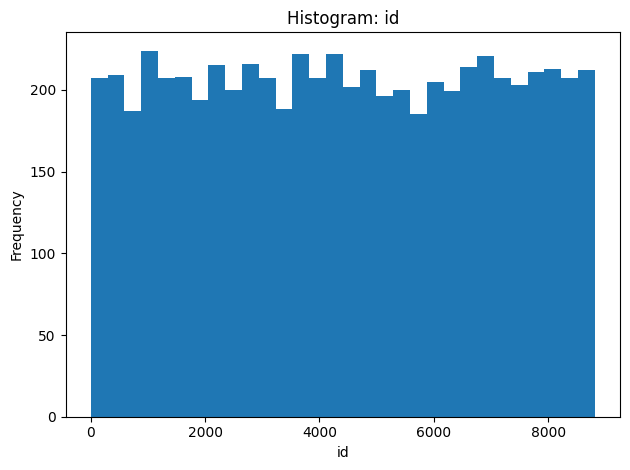

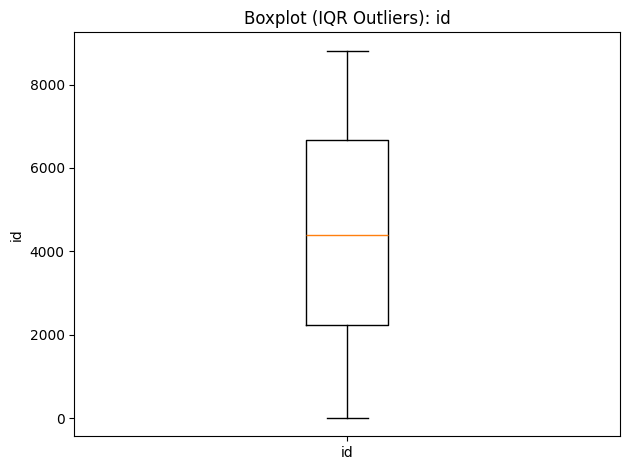

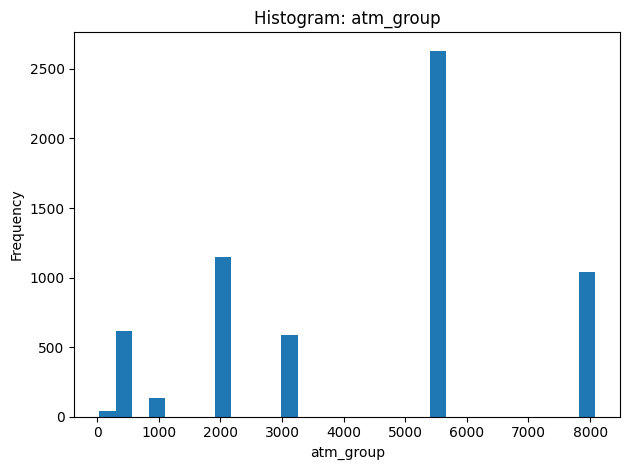

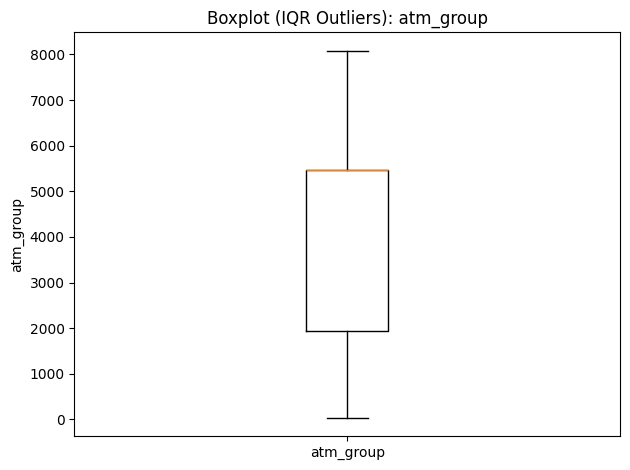

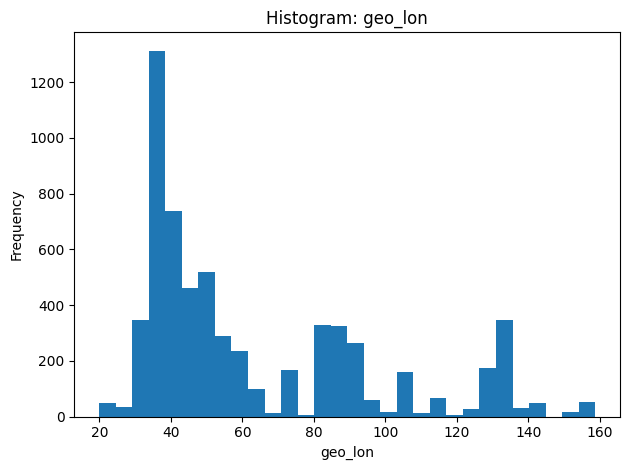

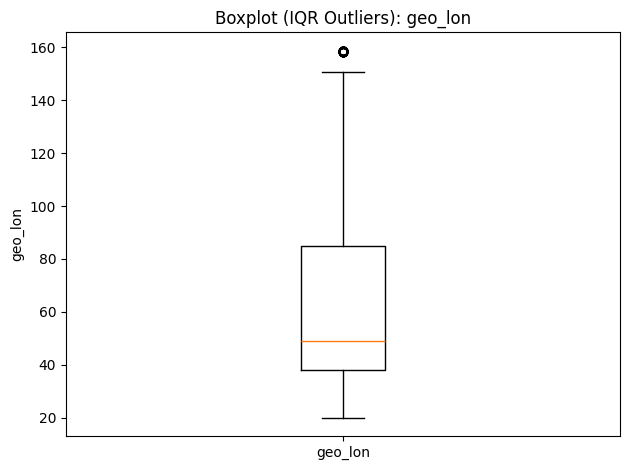

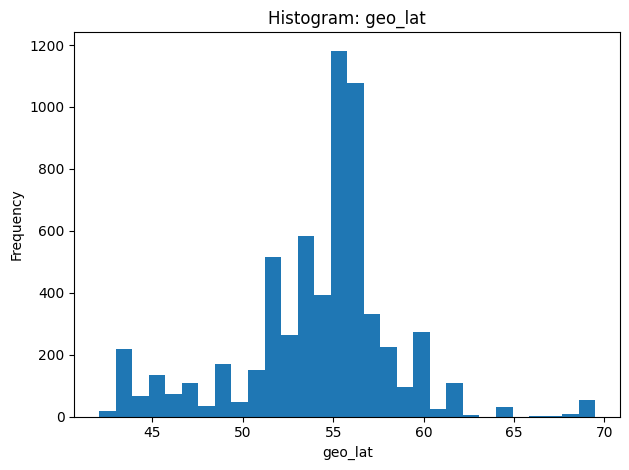

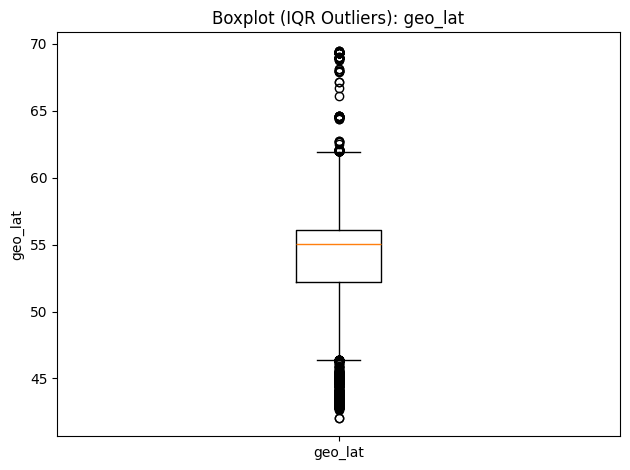

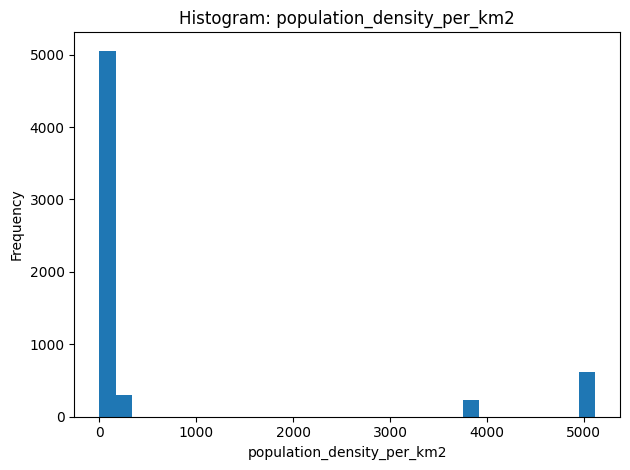

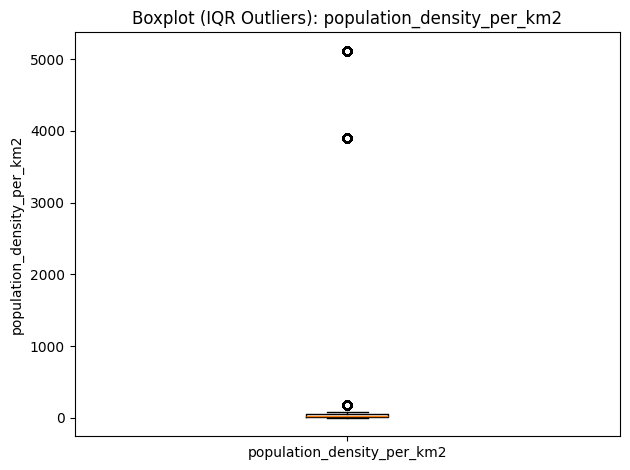

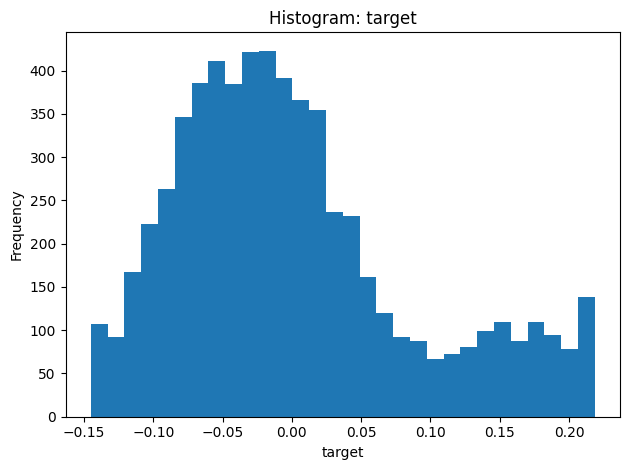

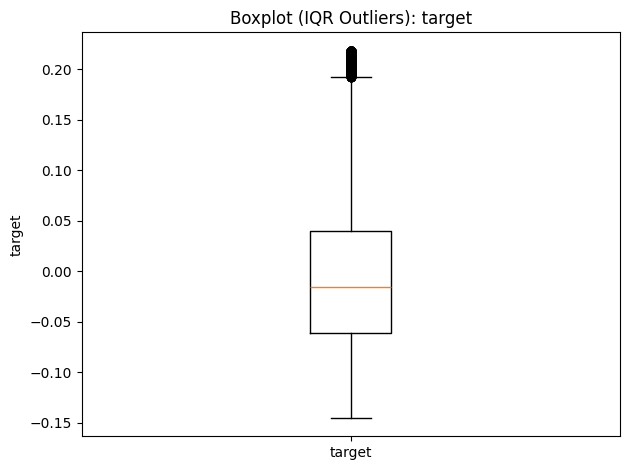

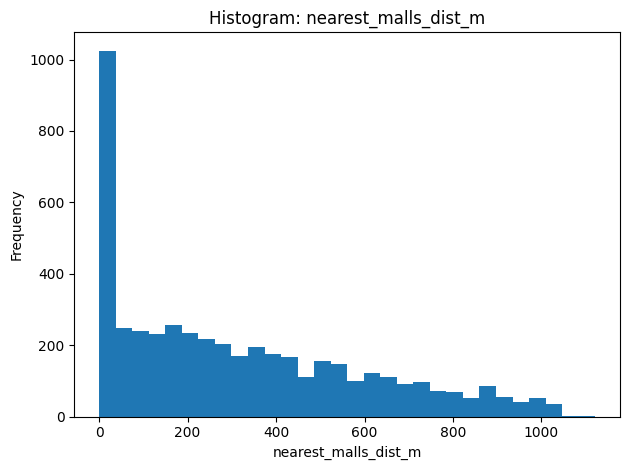

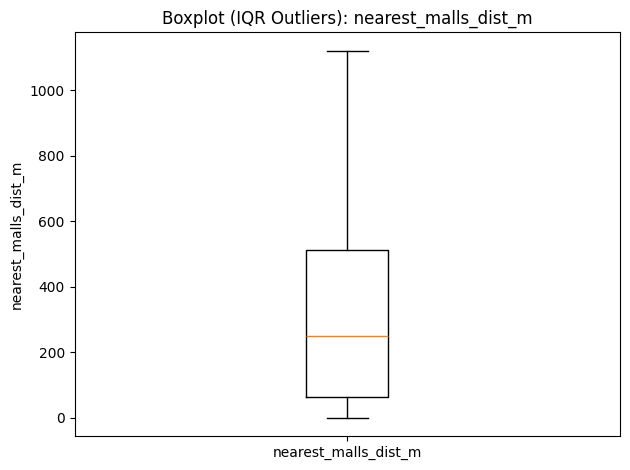

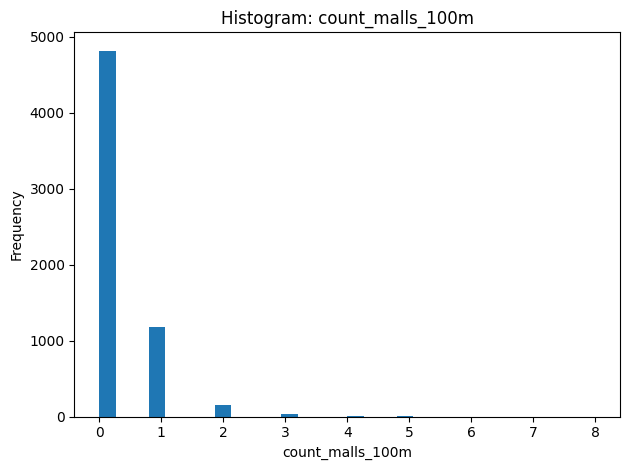

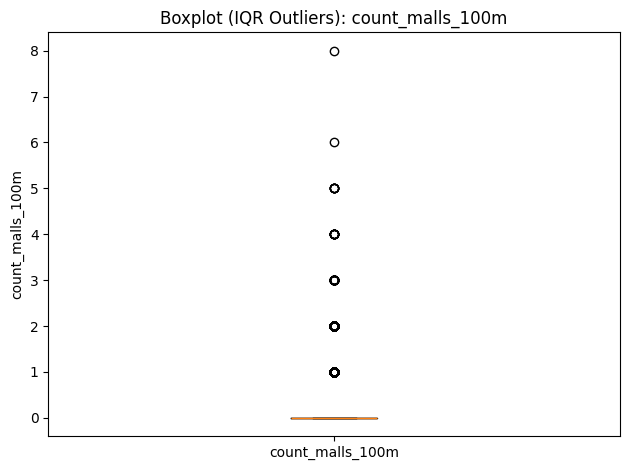

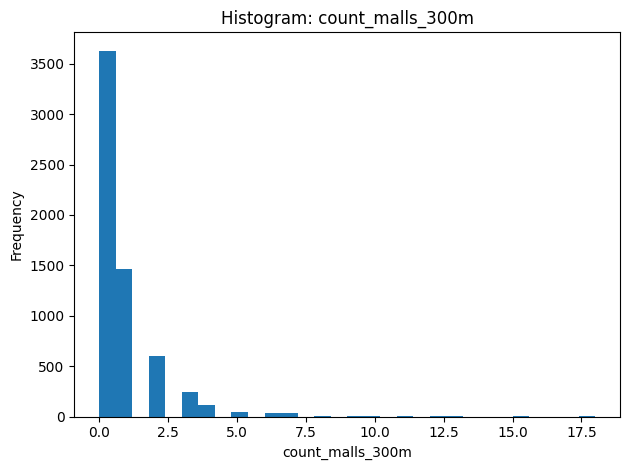

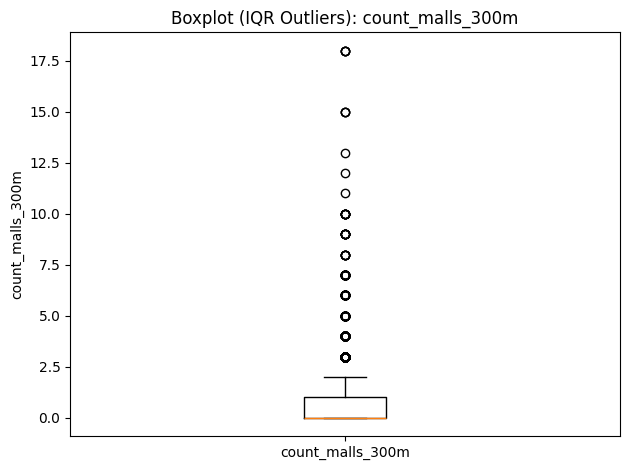

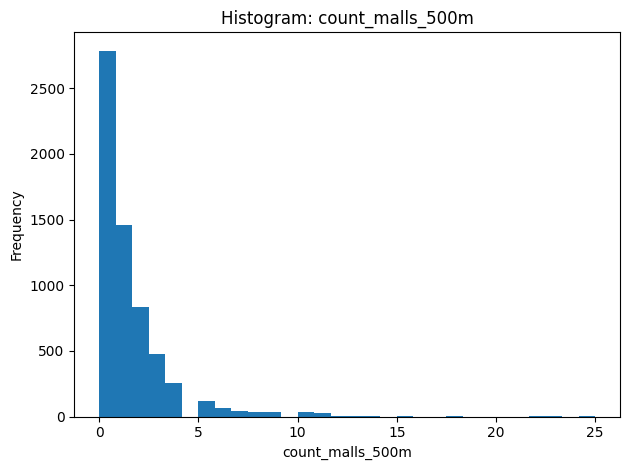

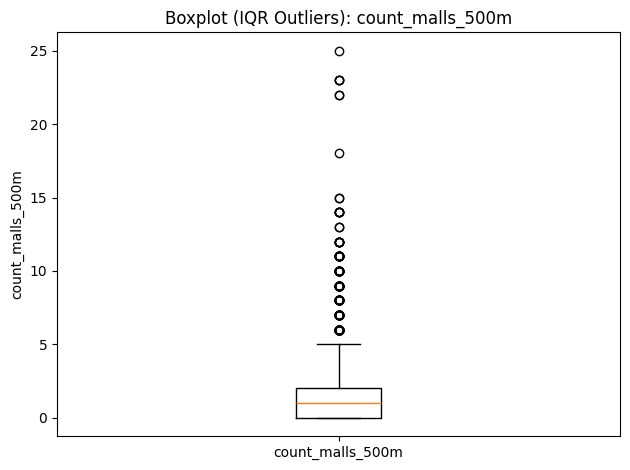

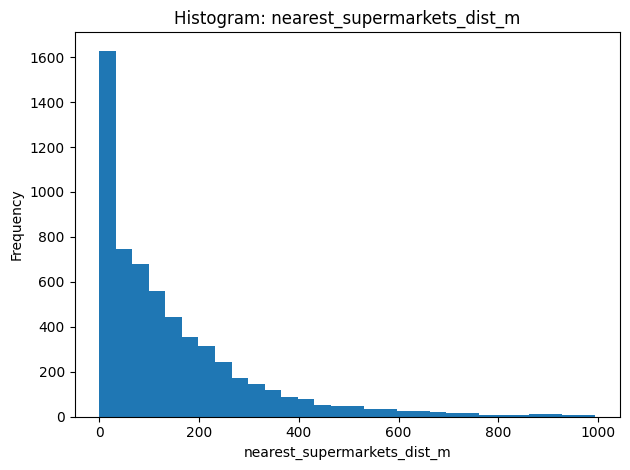

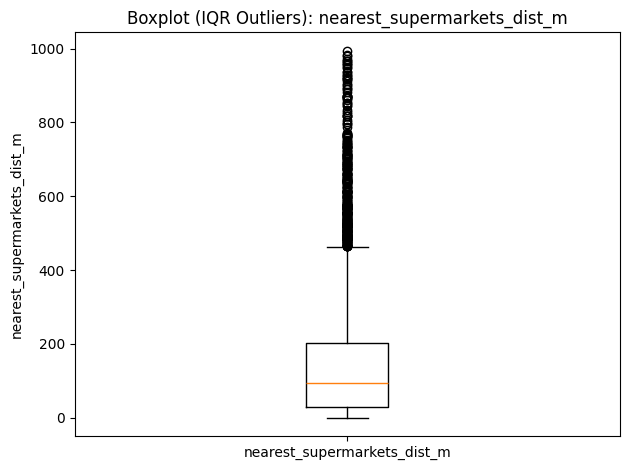

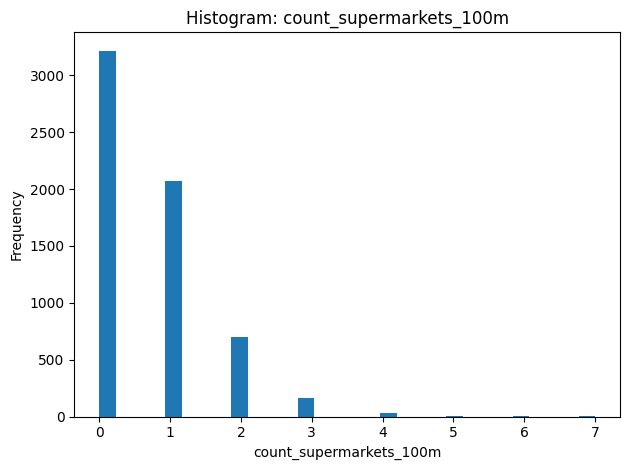

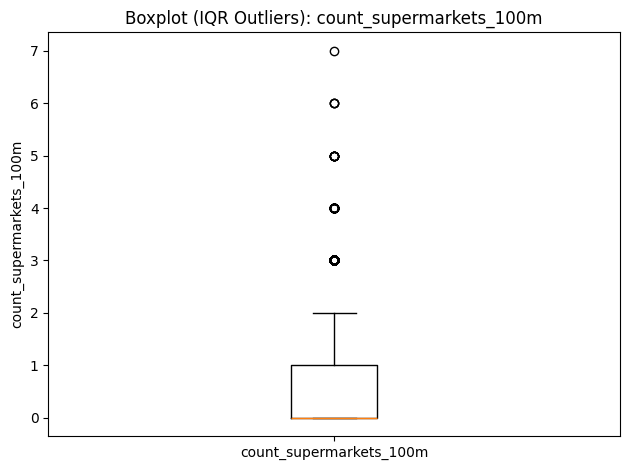

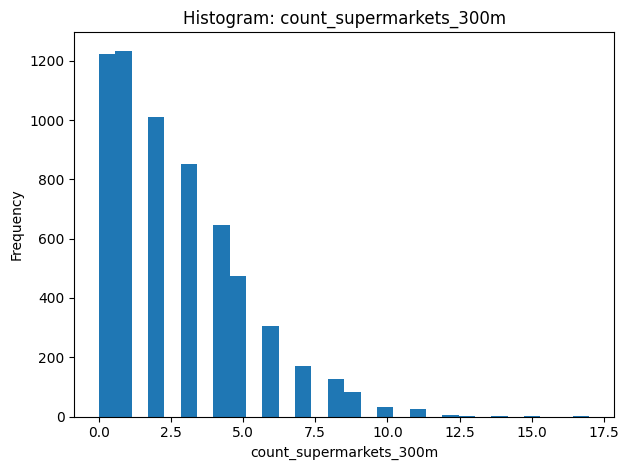

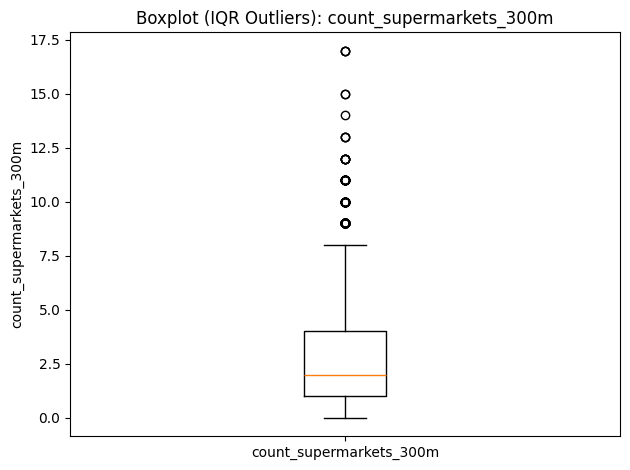

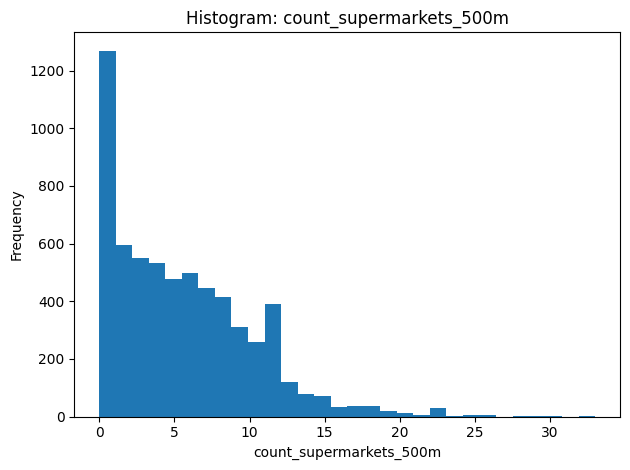

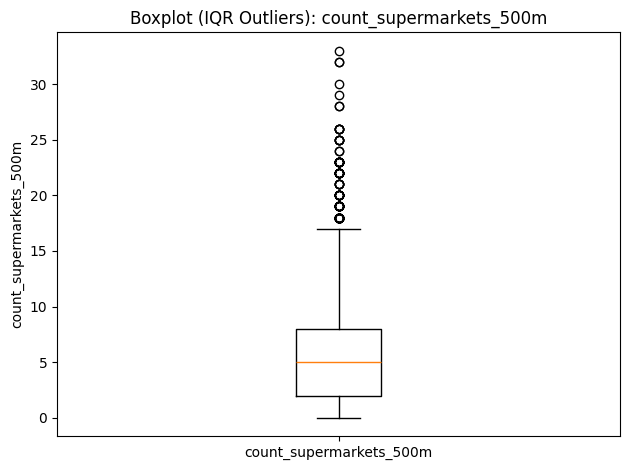

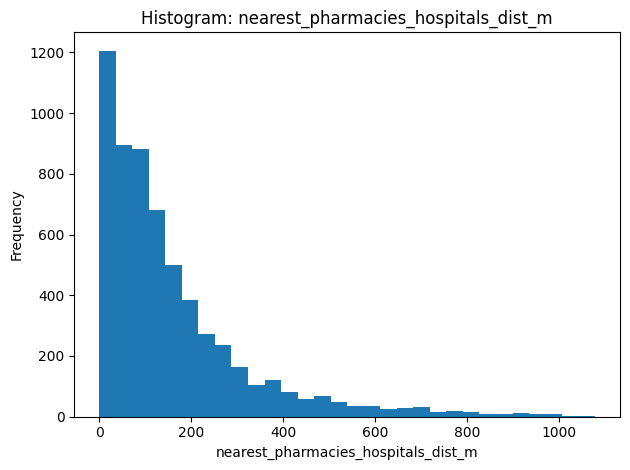

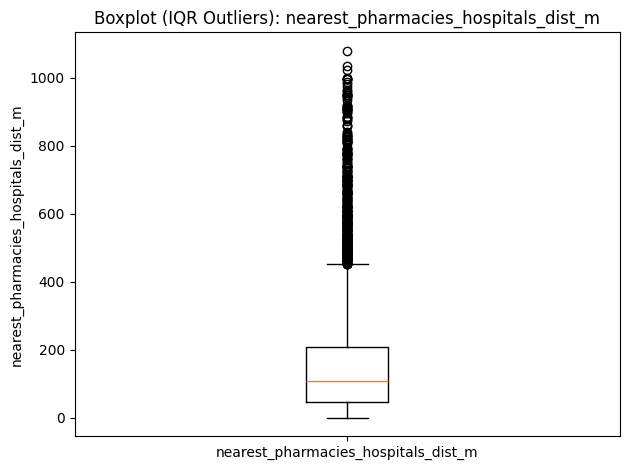

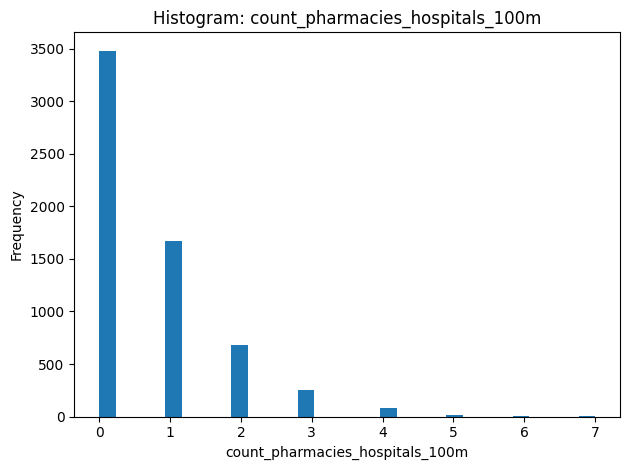

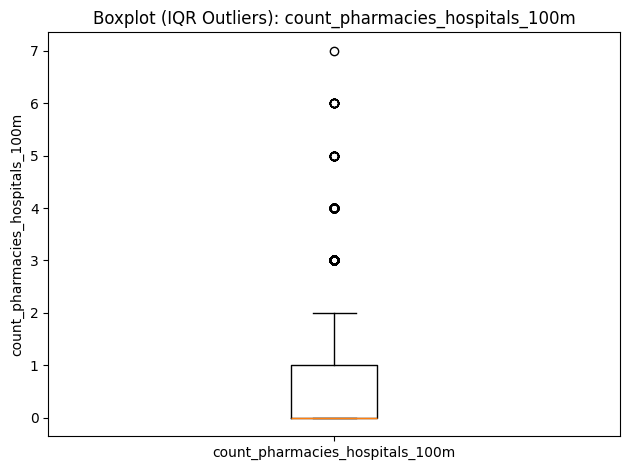

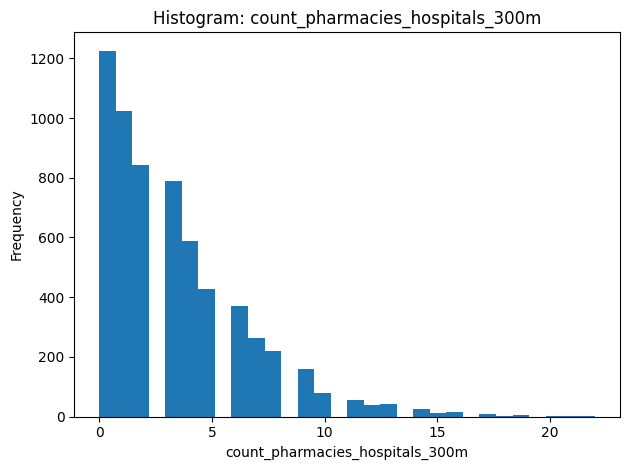

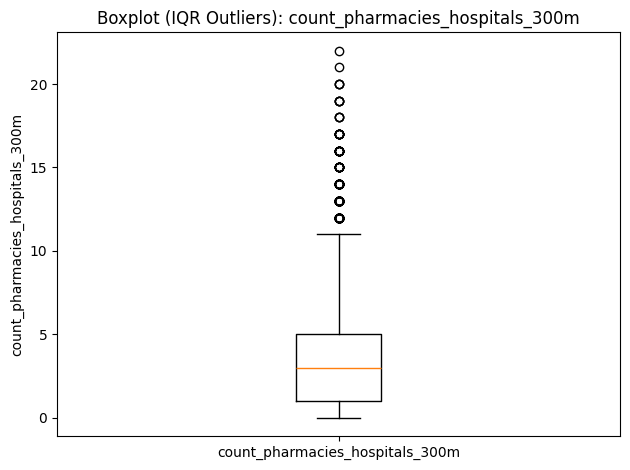

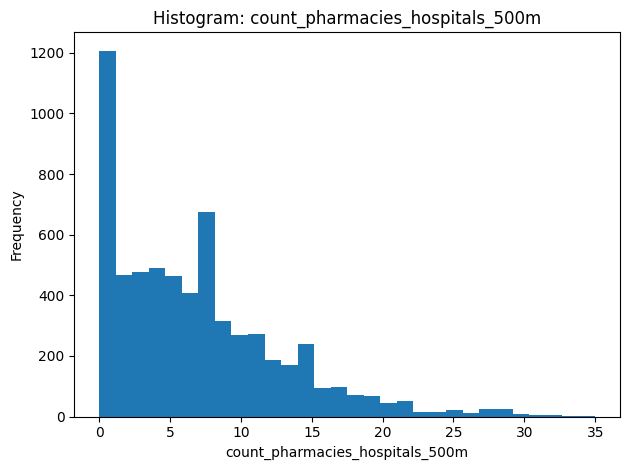

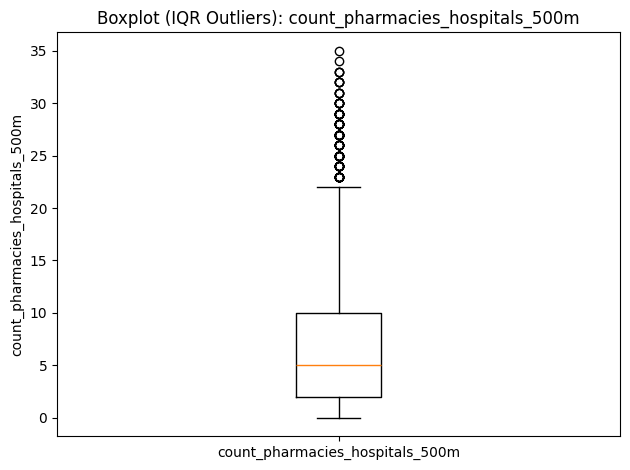

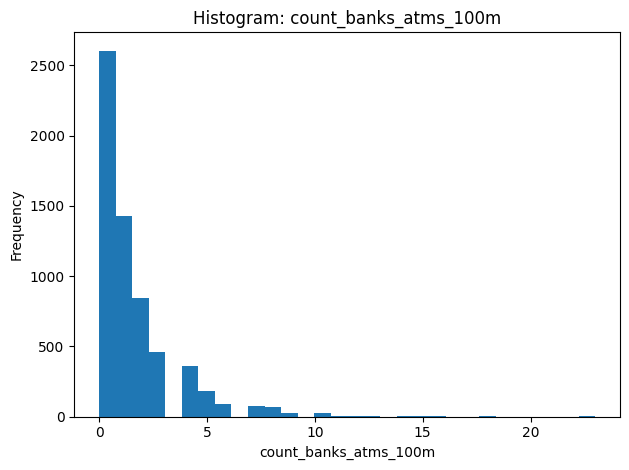

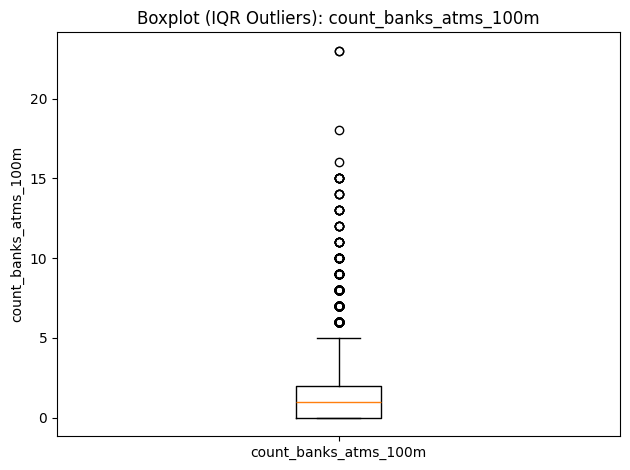

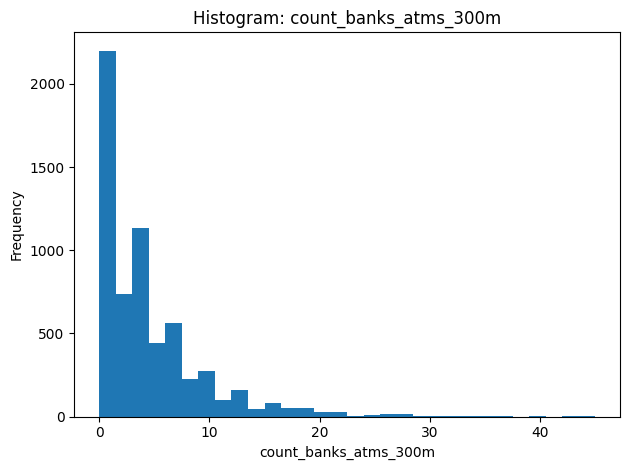

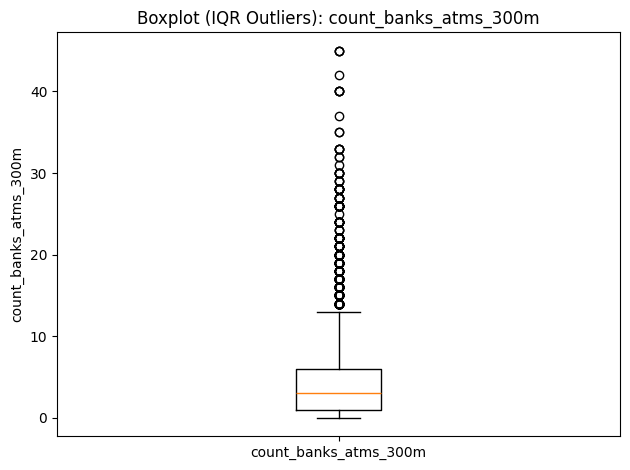

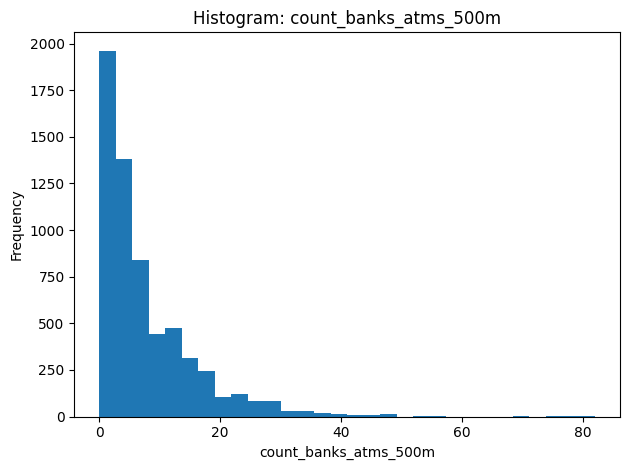

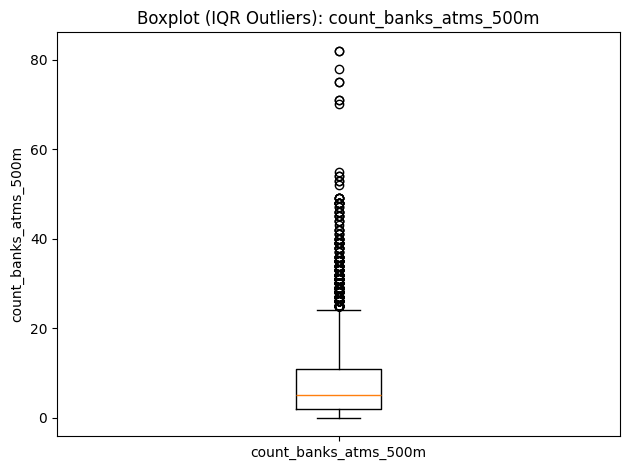

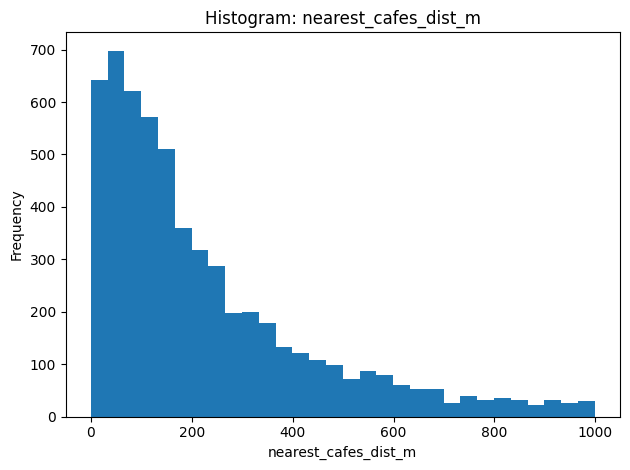

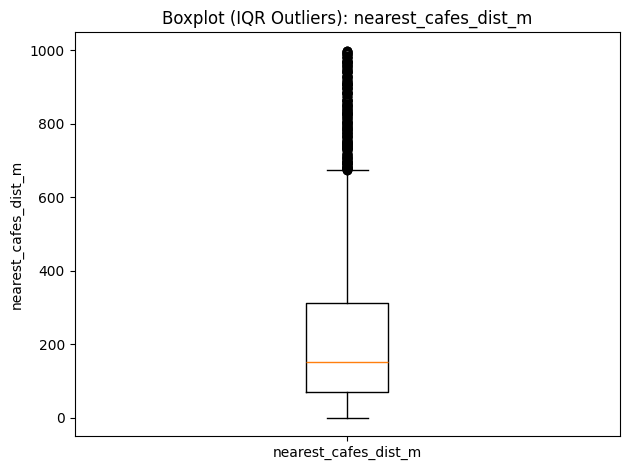

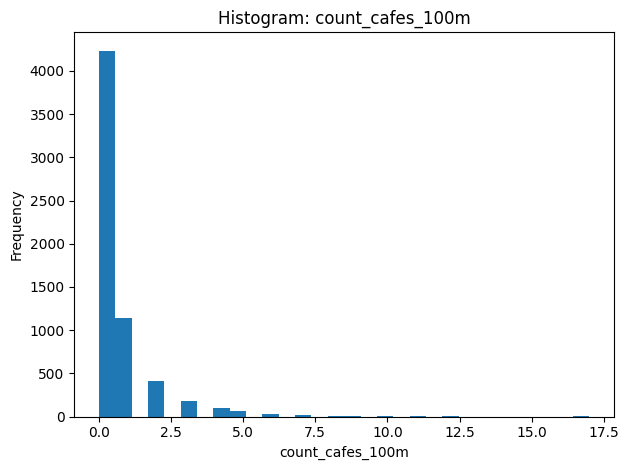

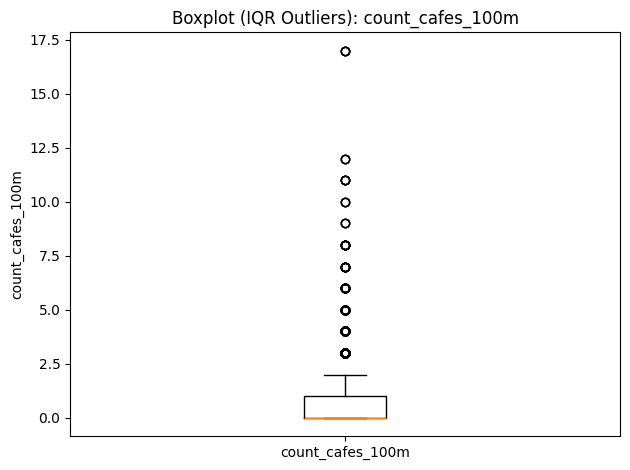

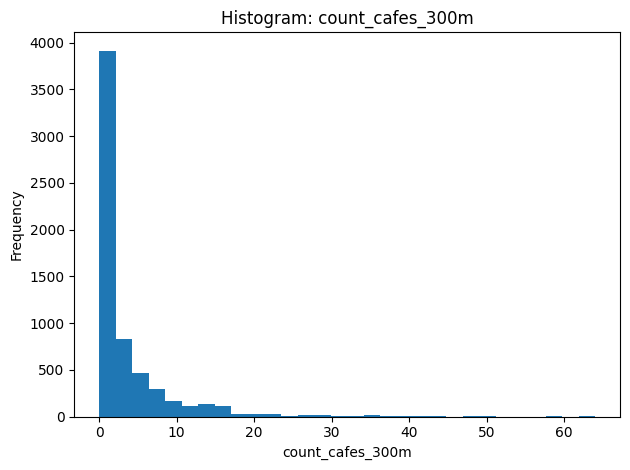

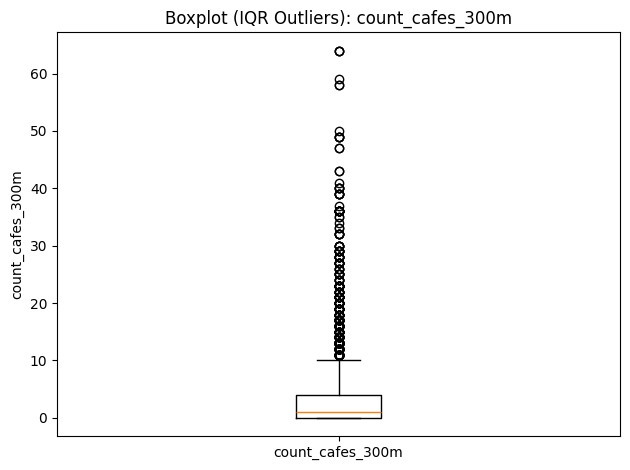

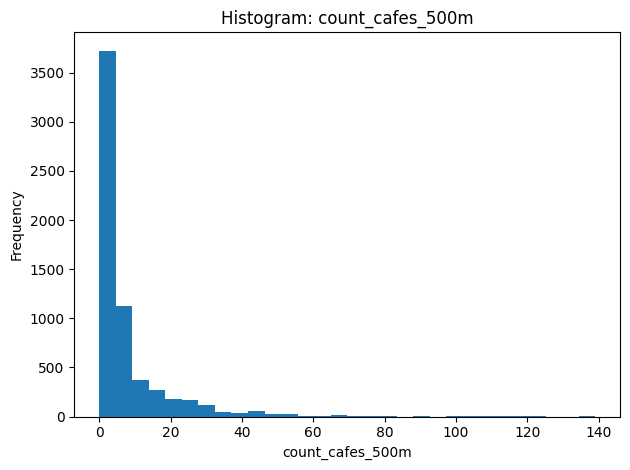

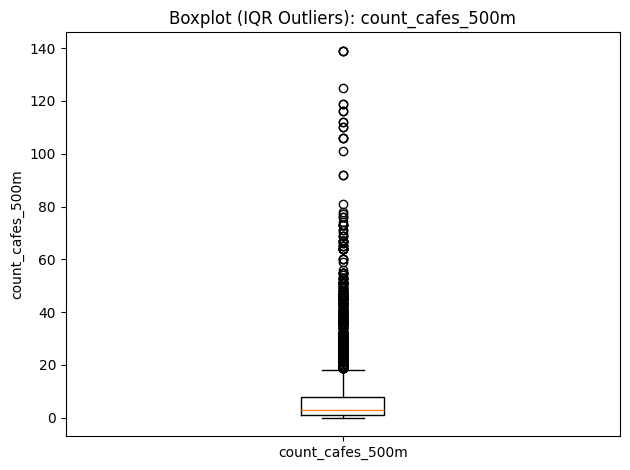

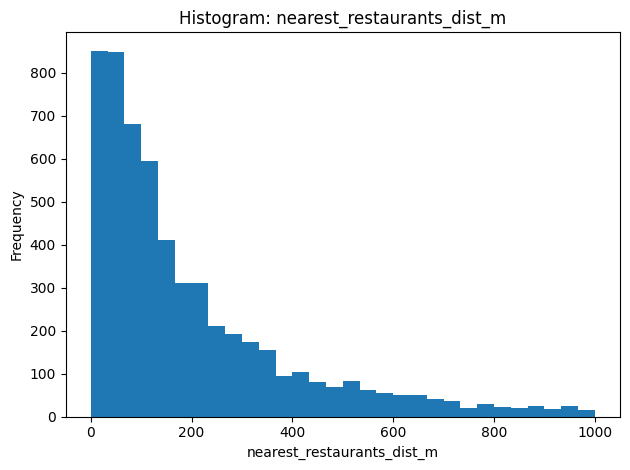

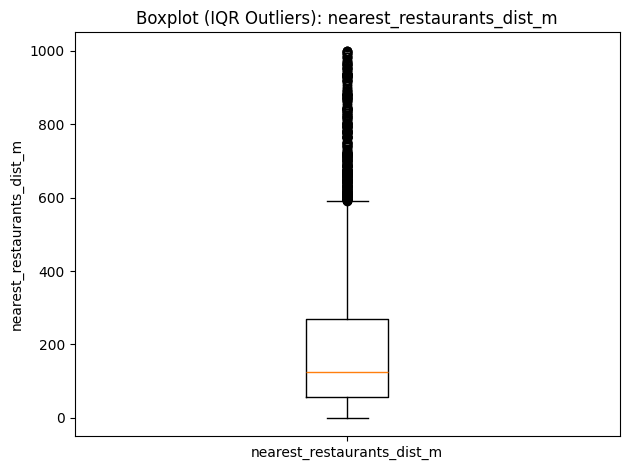

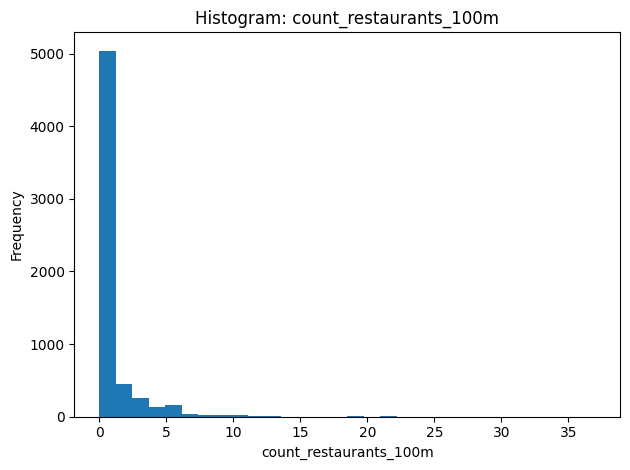

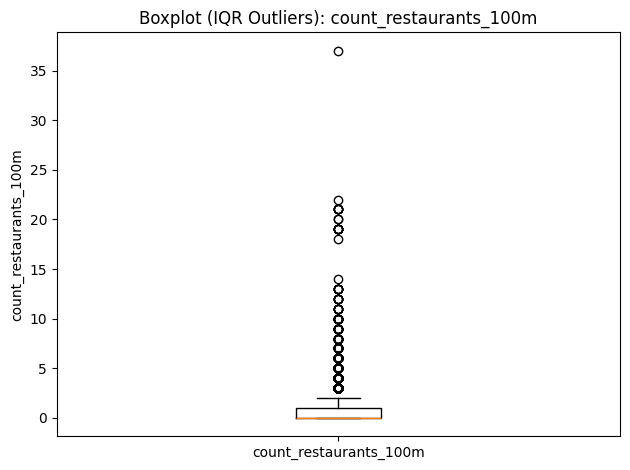

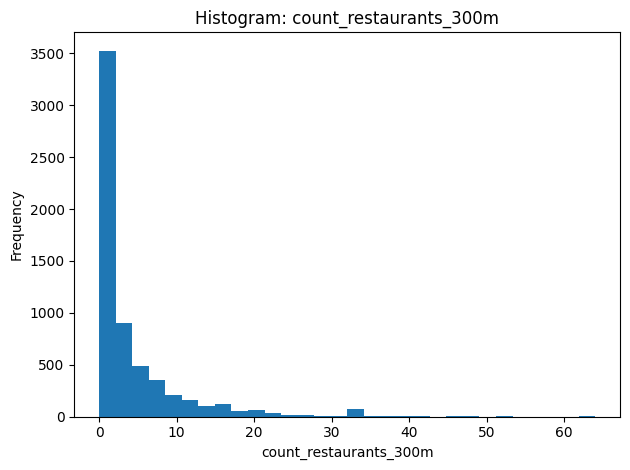

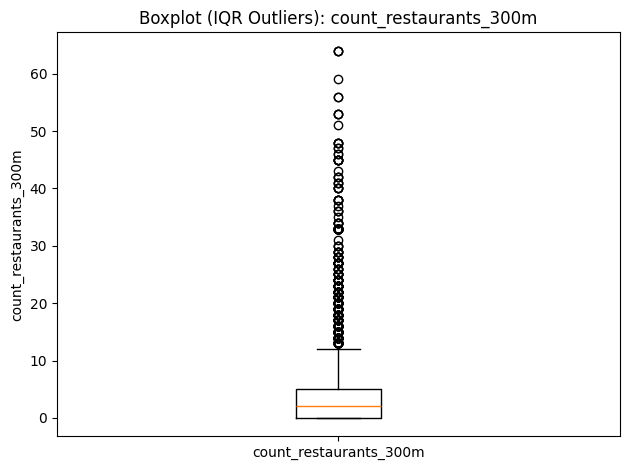

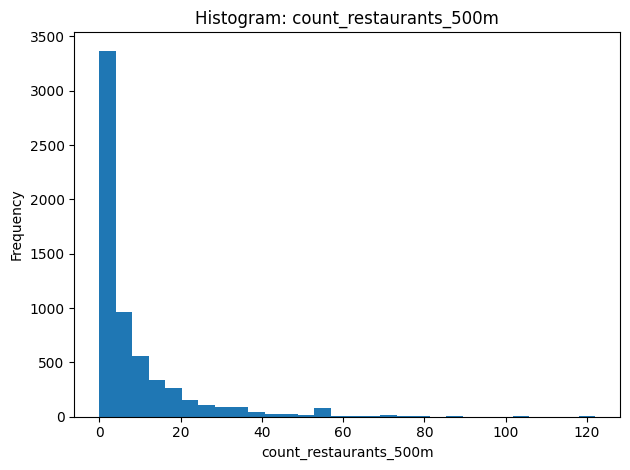

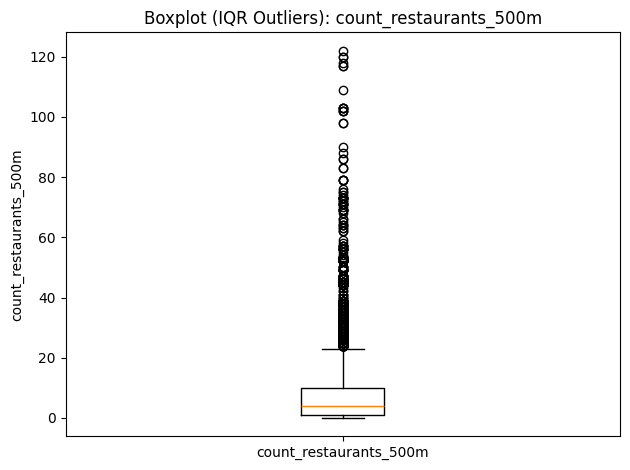

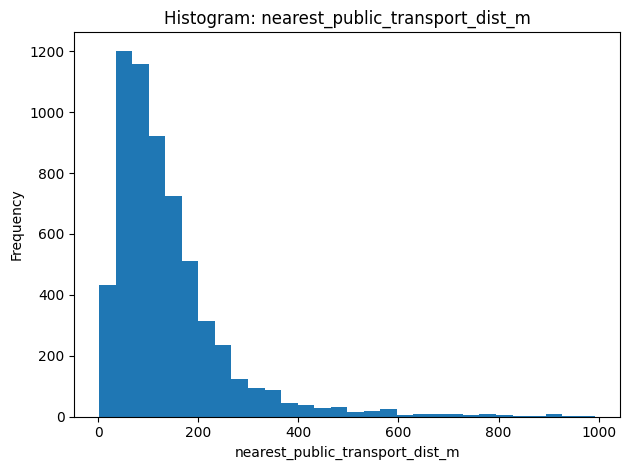

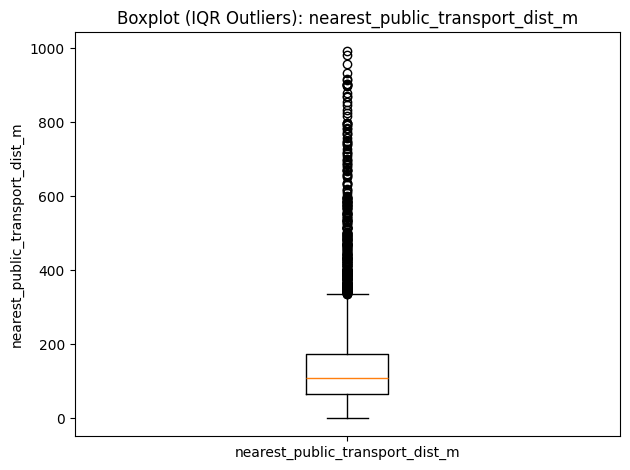

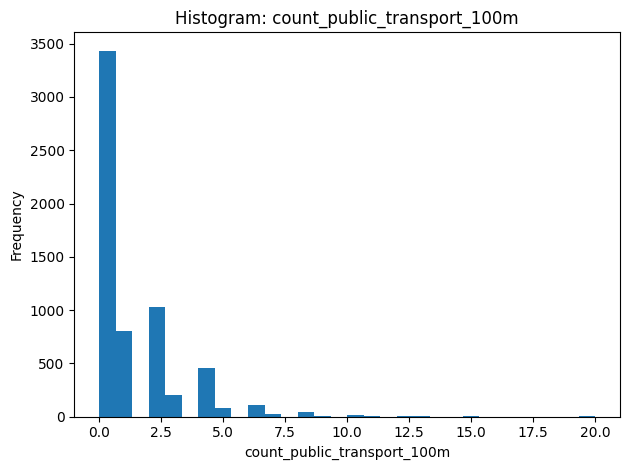

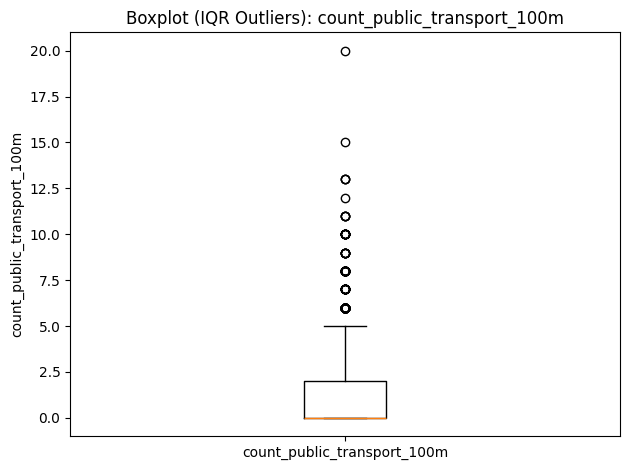

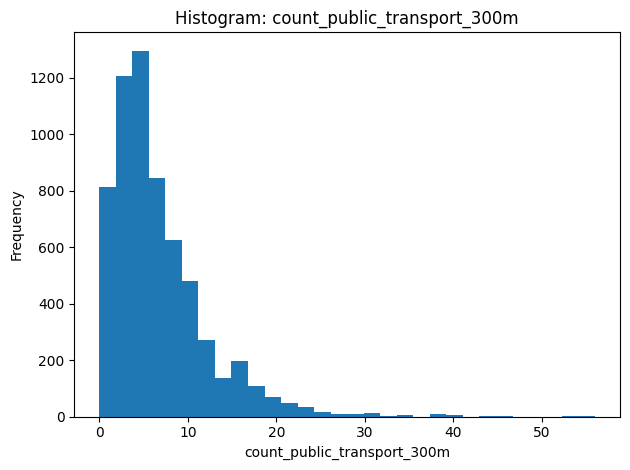

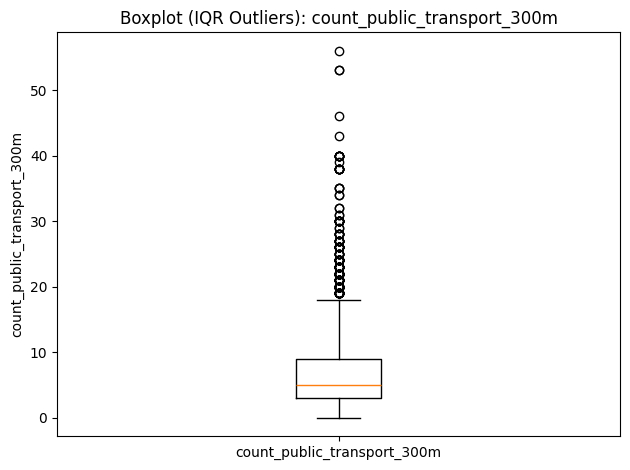

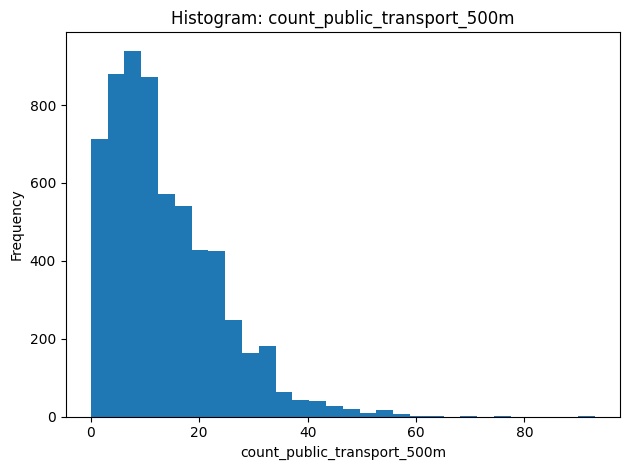

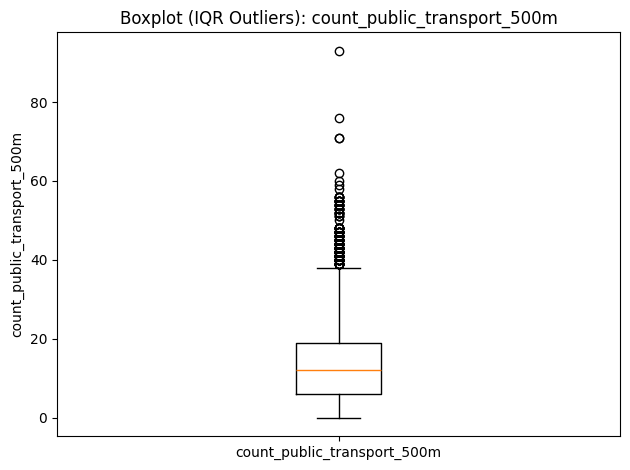

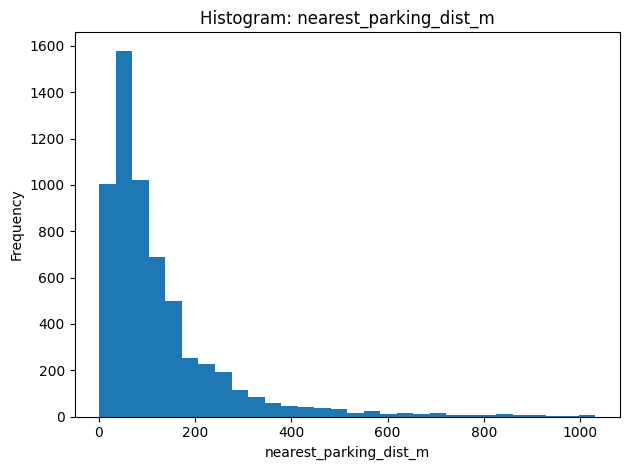

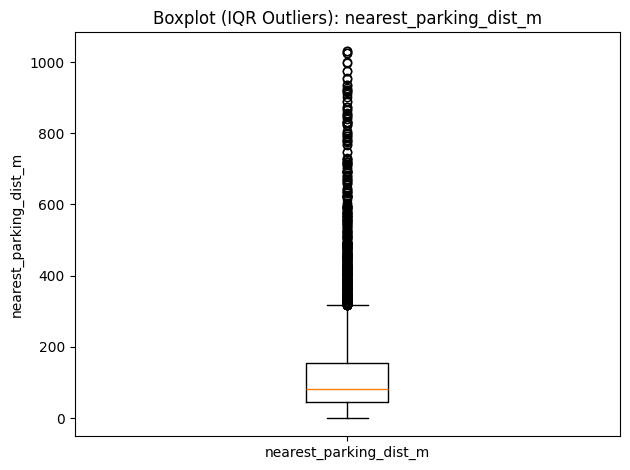

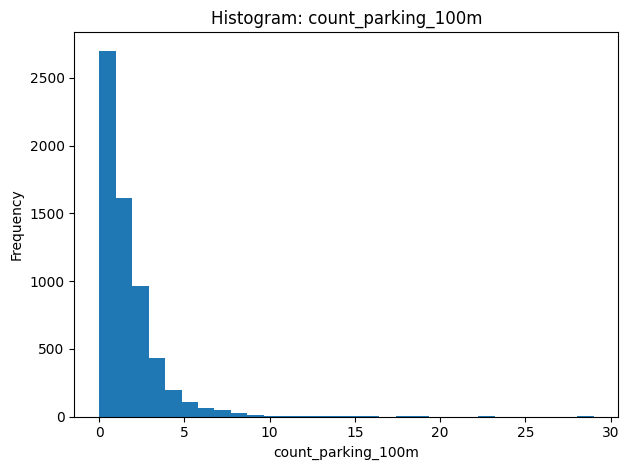

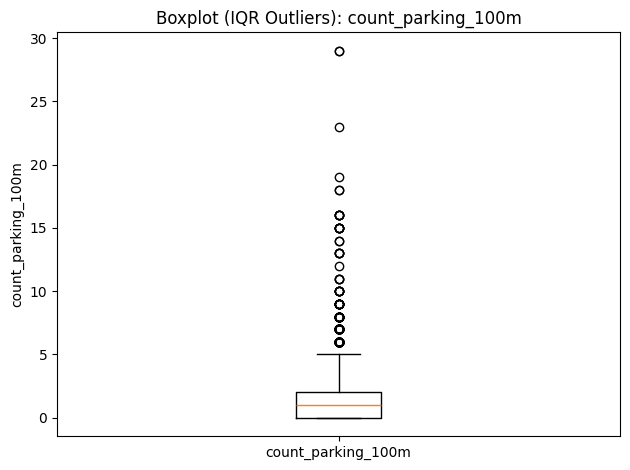

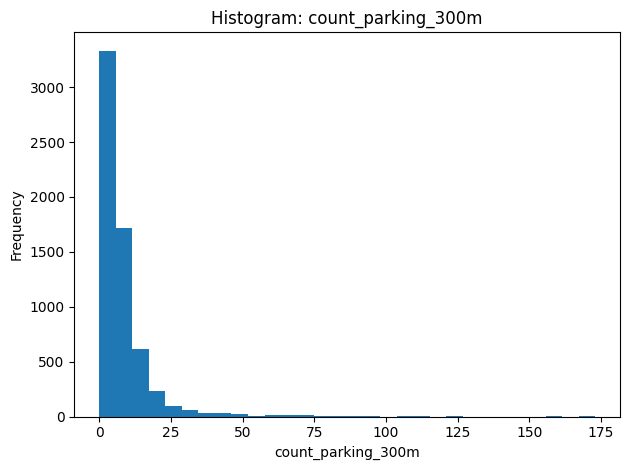

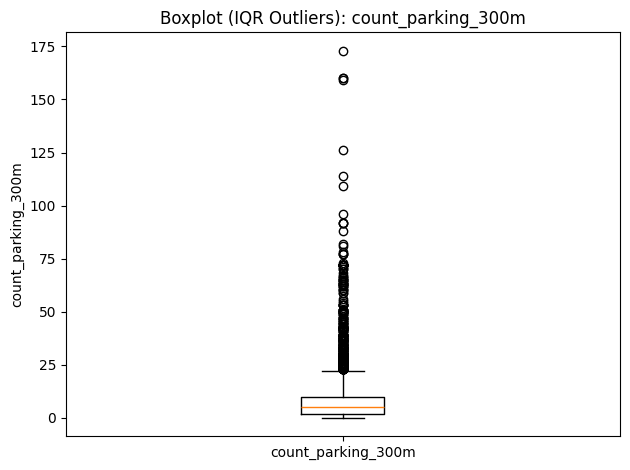

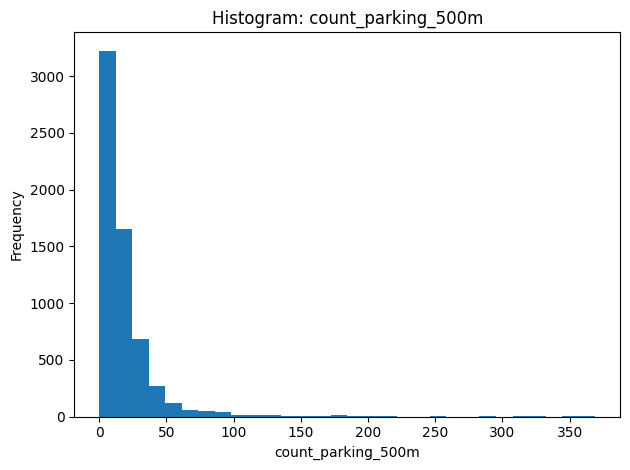

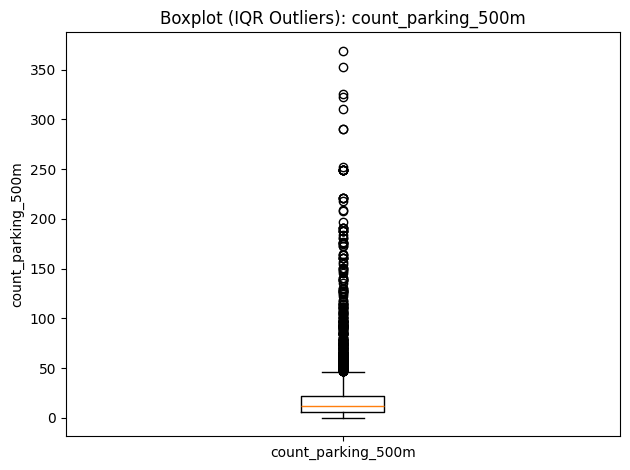

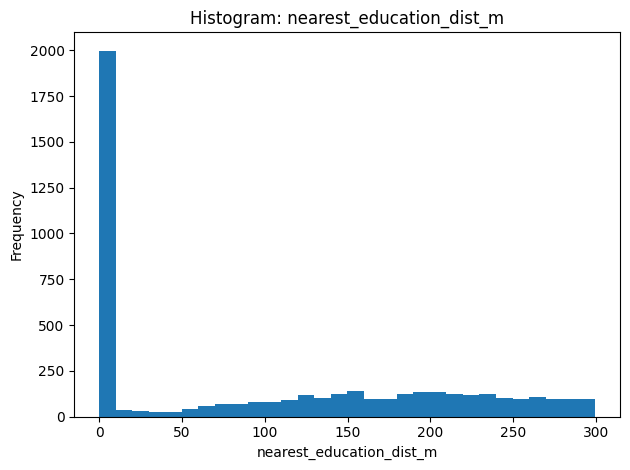

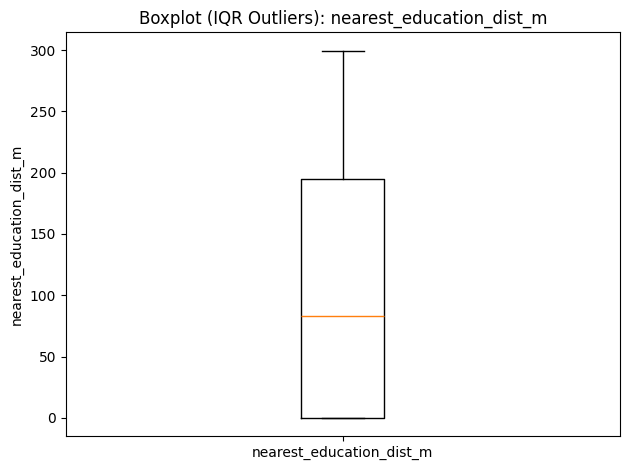

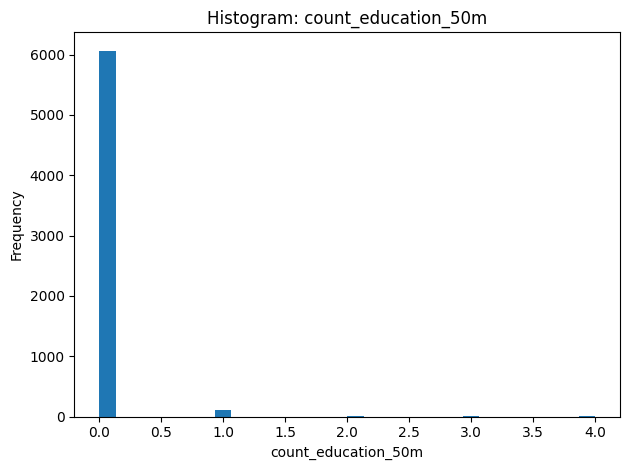

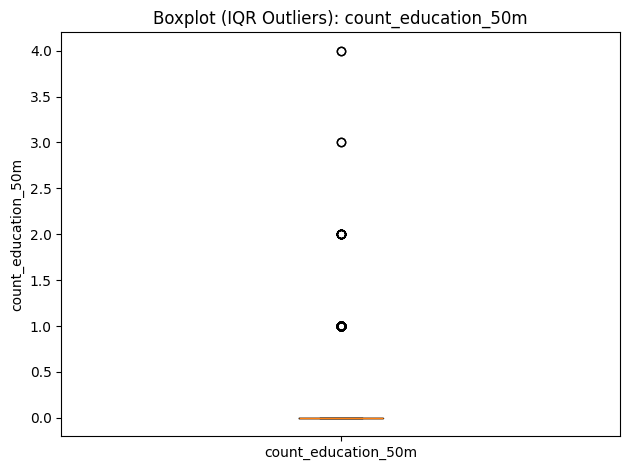

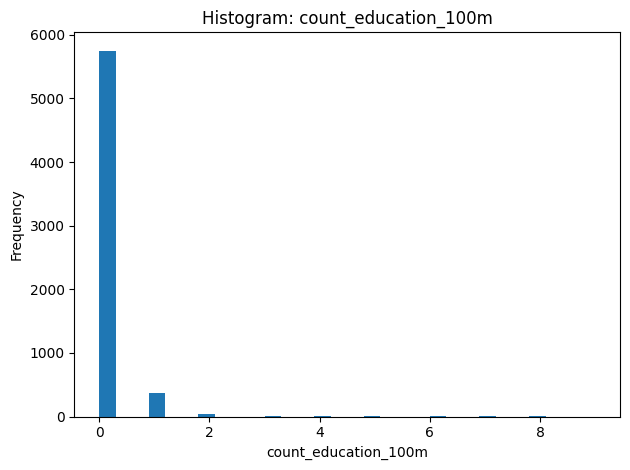

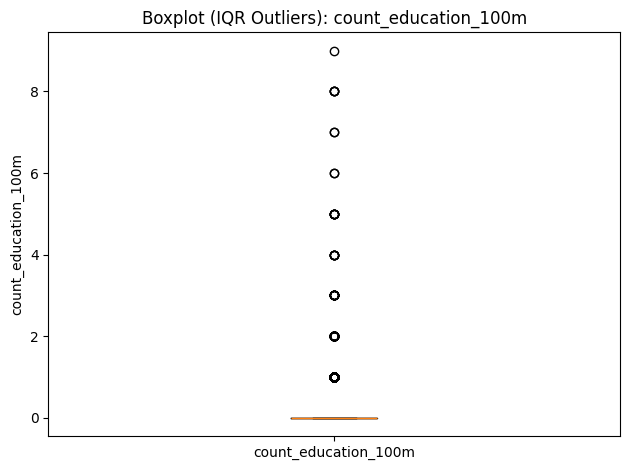

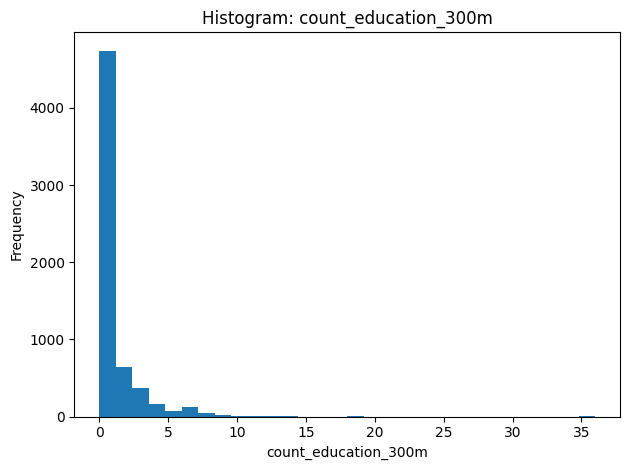

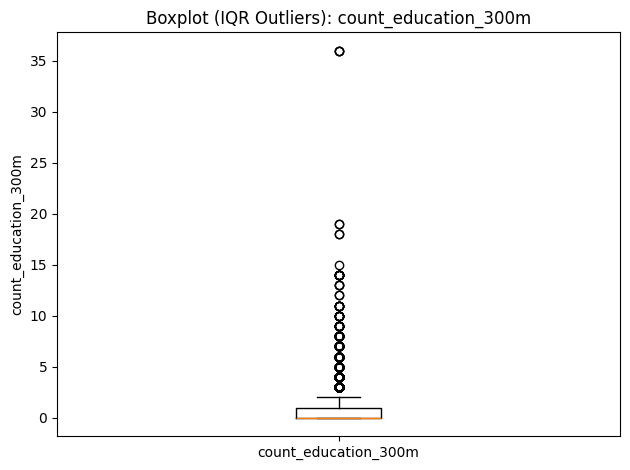

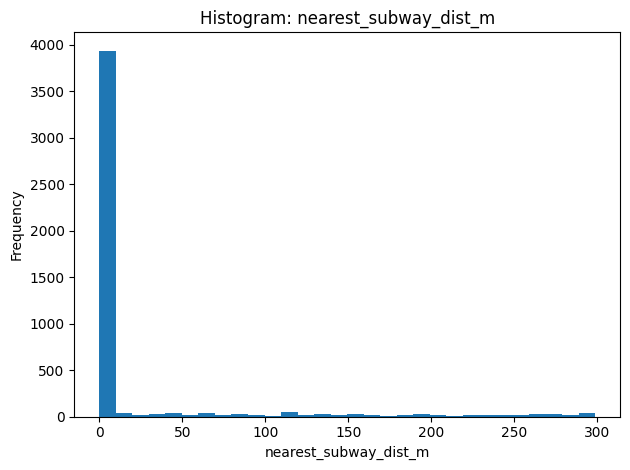

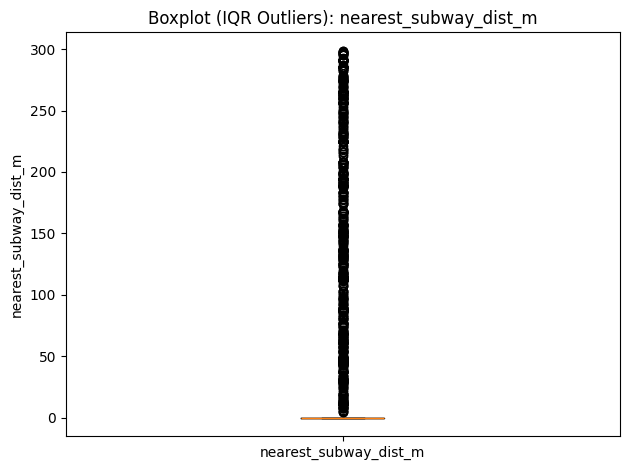

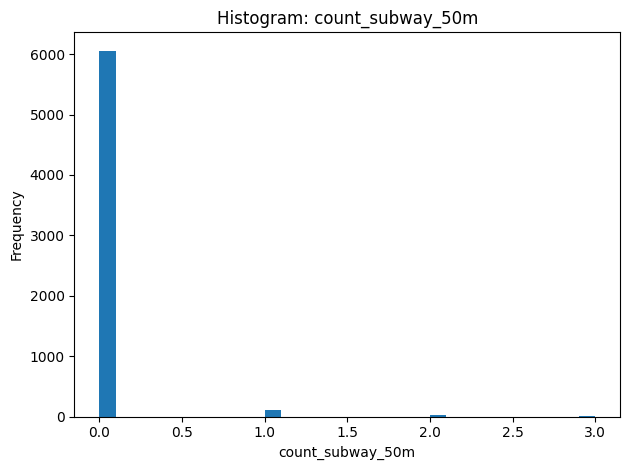

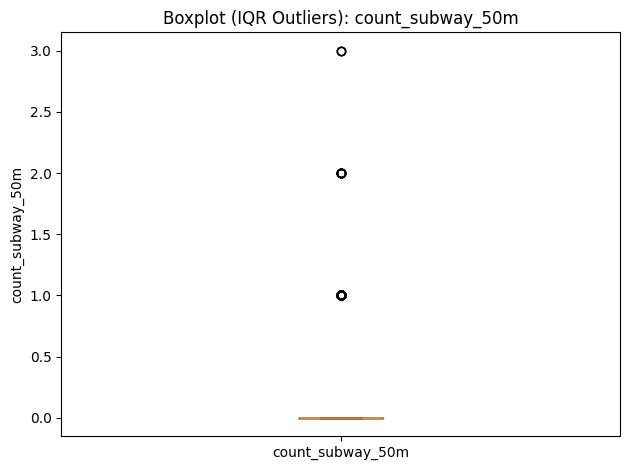

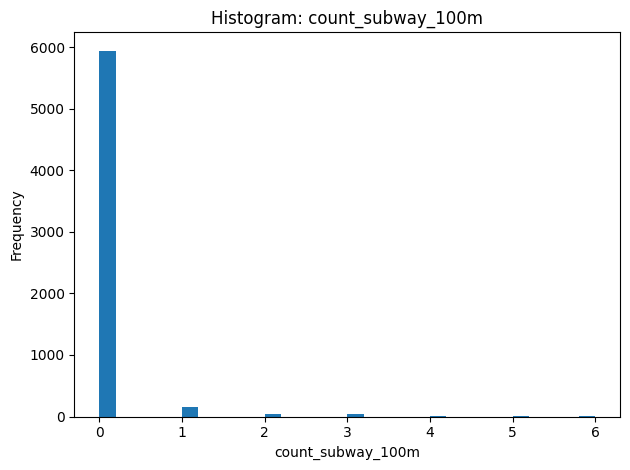

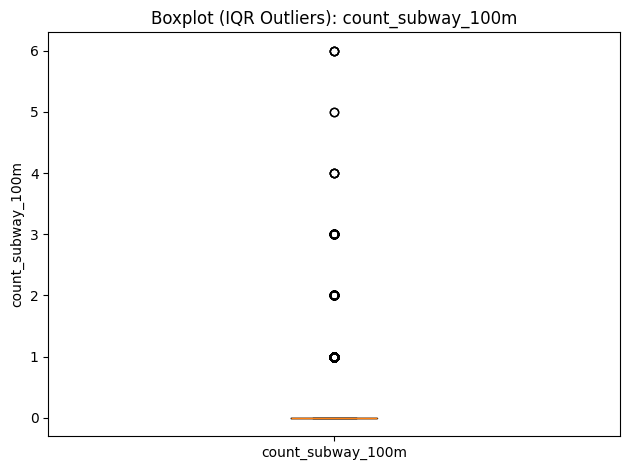

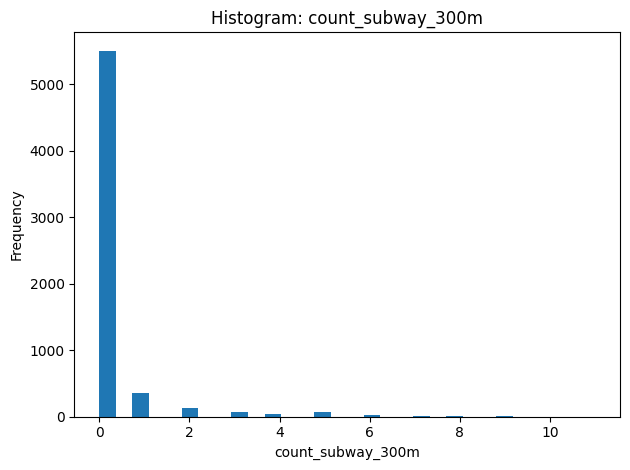

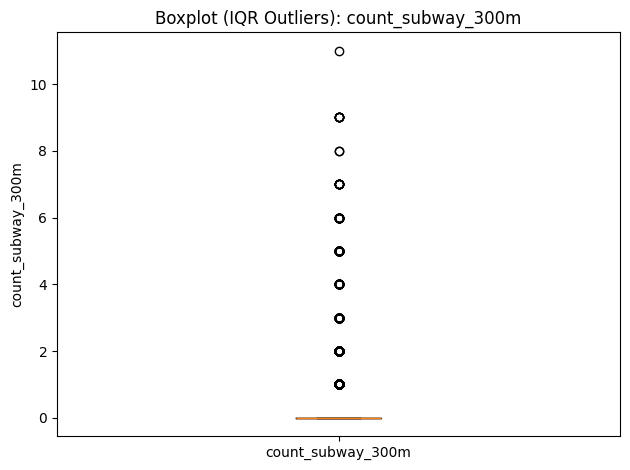

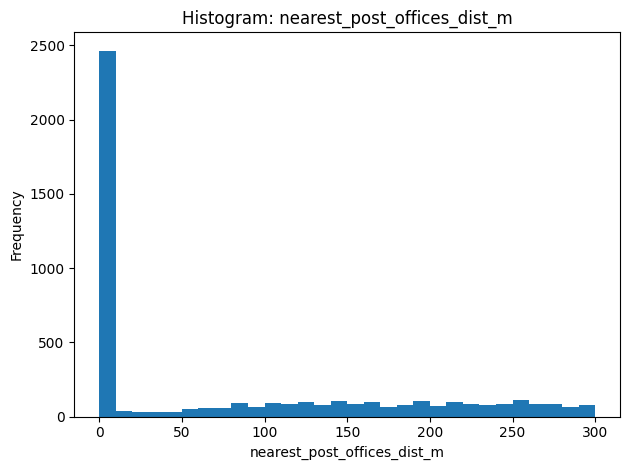

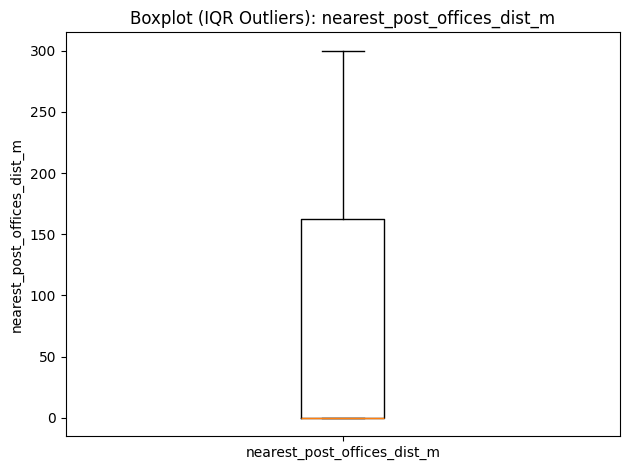

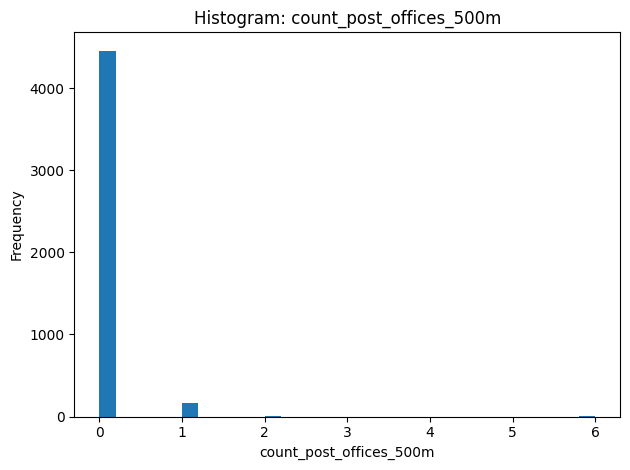

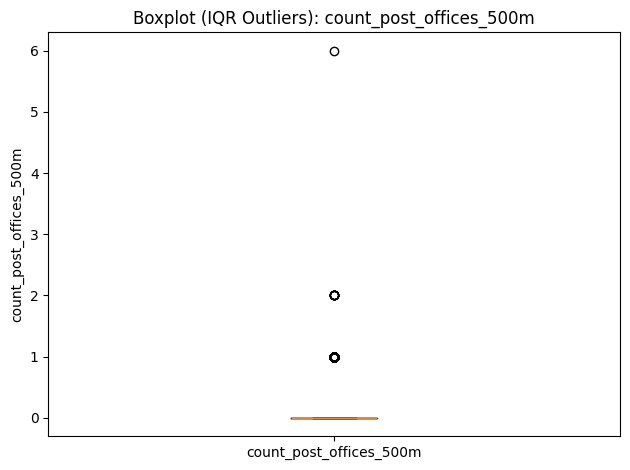

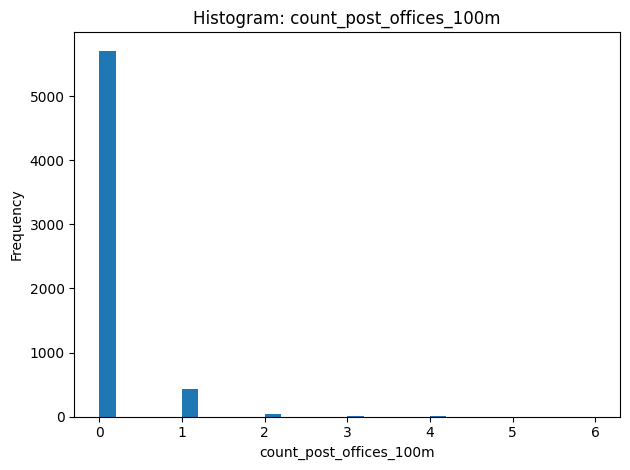

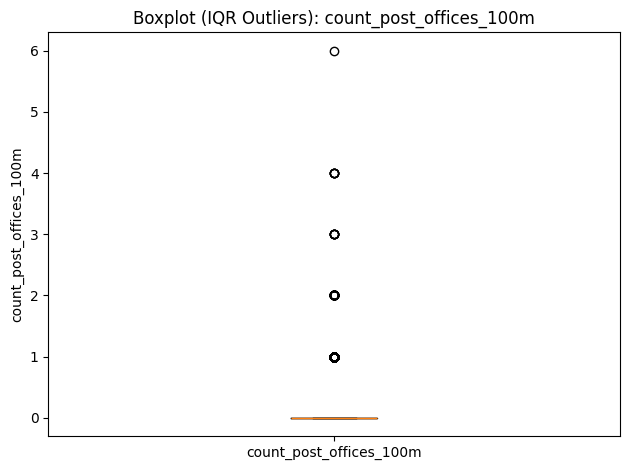

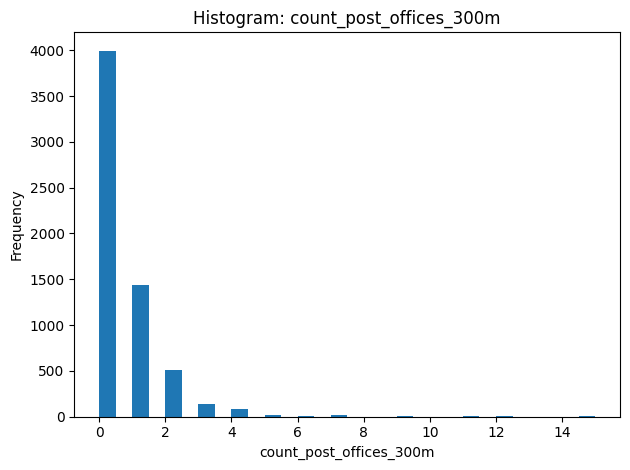

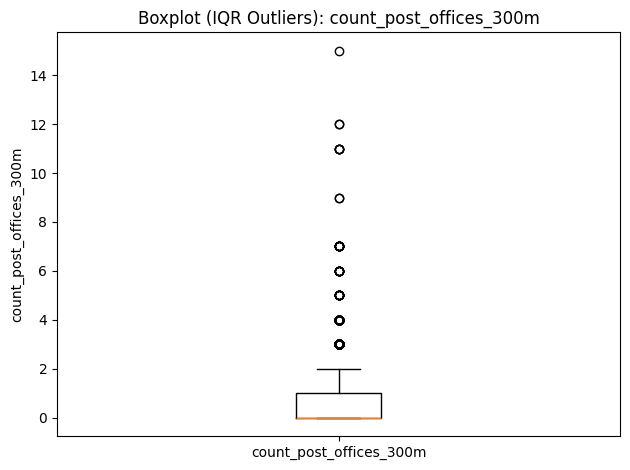

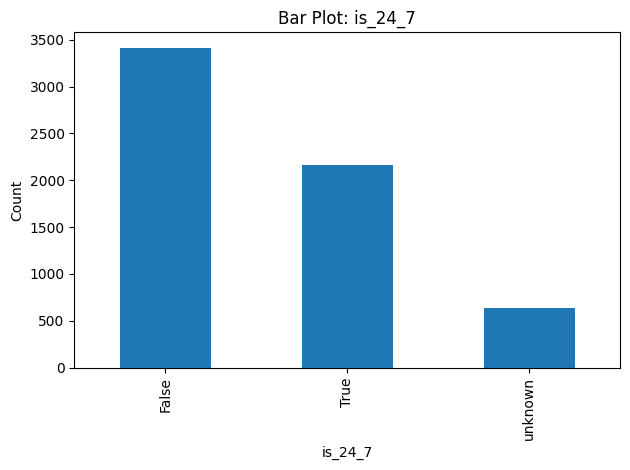

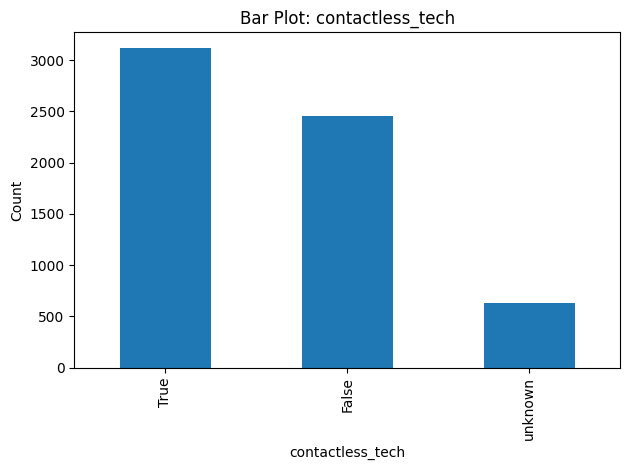

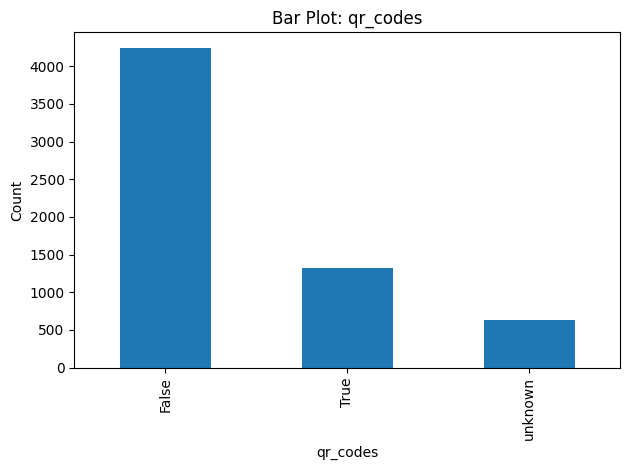

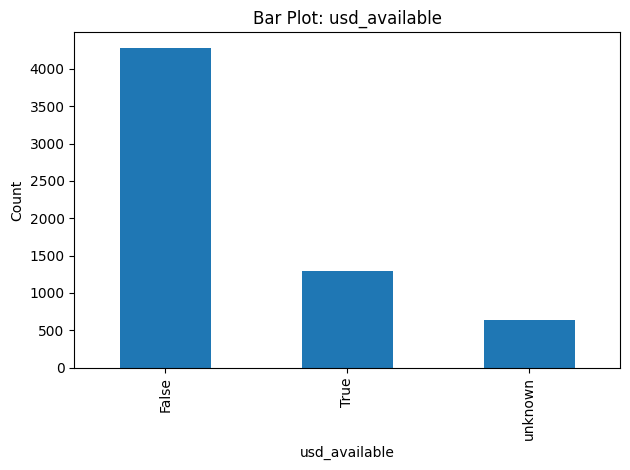

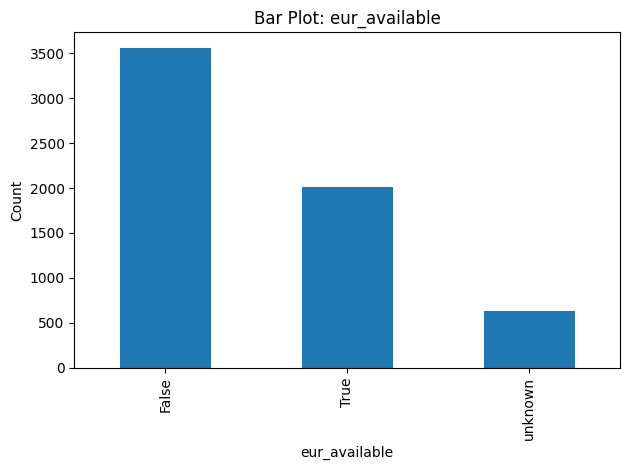

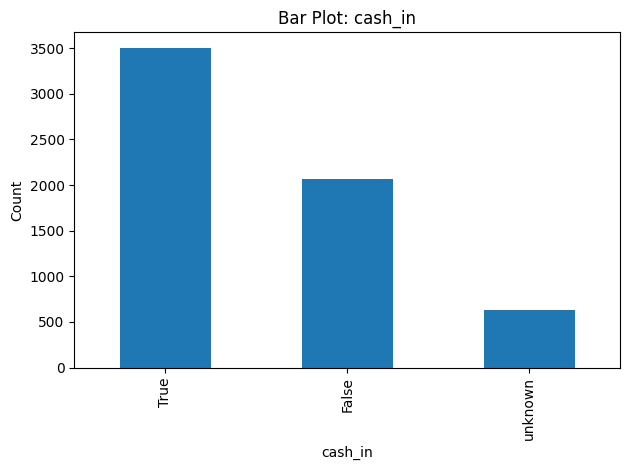

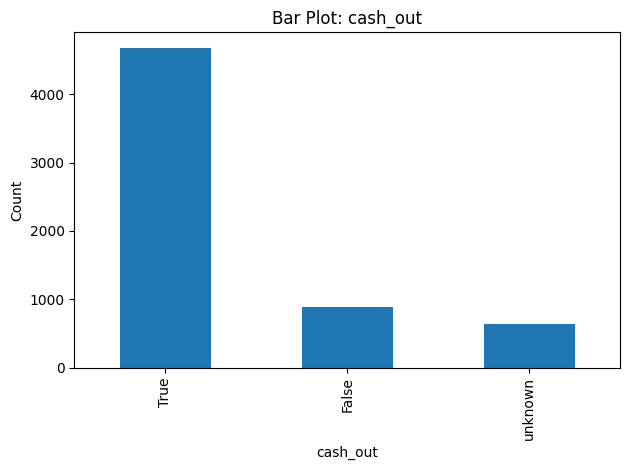

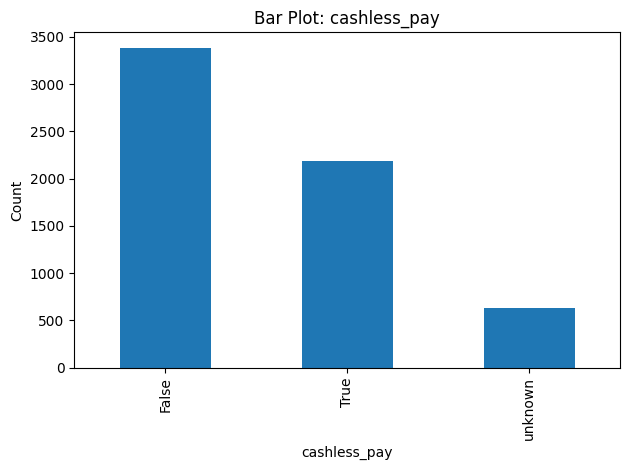

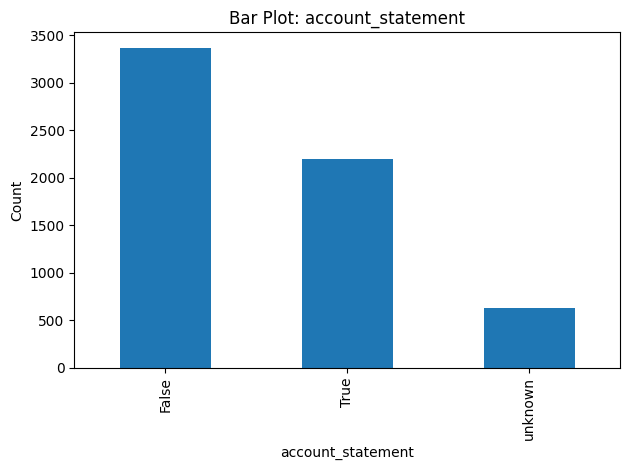

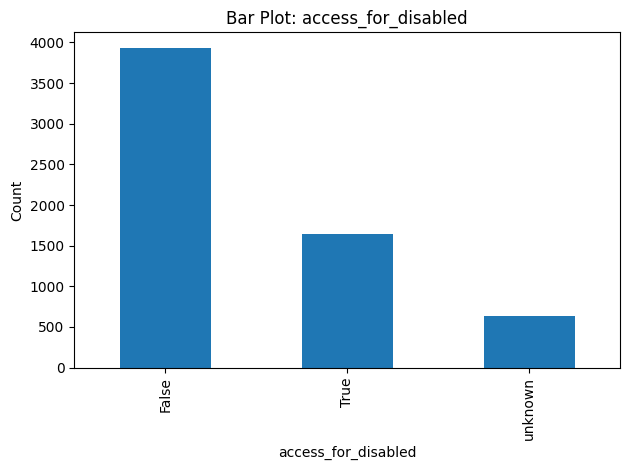

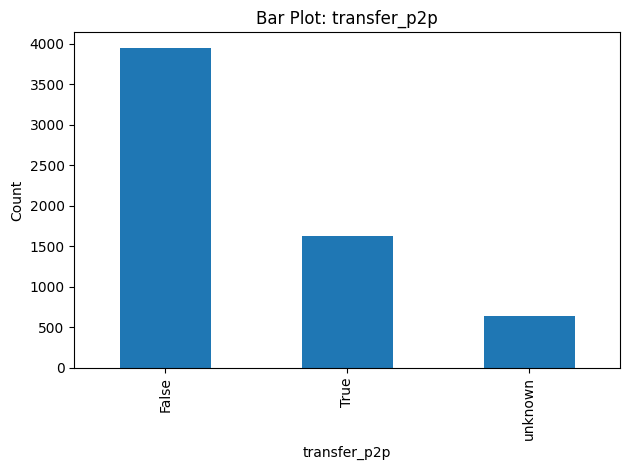

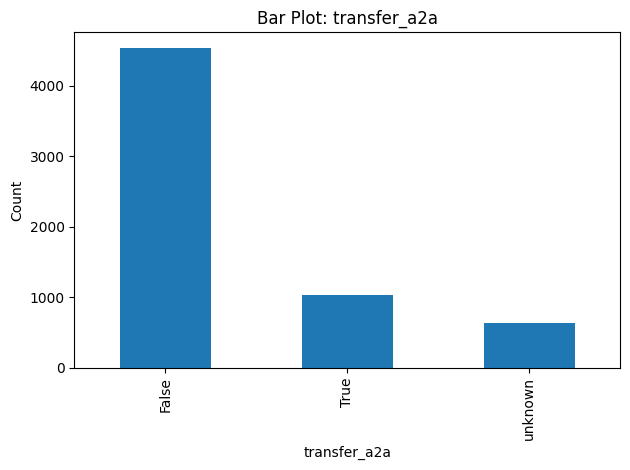

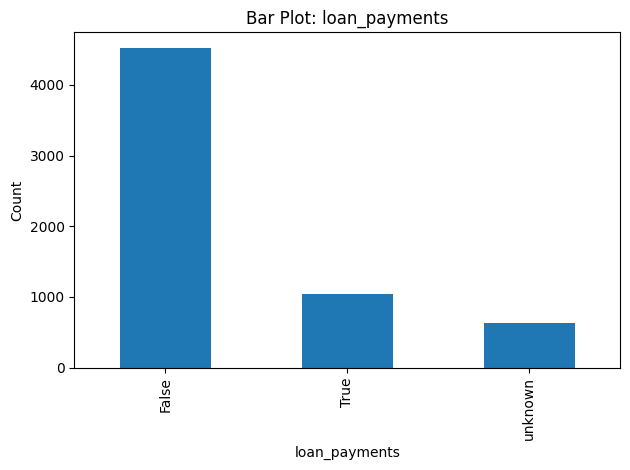

'Numeric columns: distributions & outliers (IQR)'

,column,type,count_nonnull,nunique,min,q1,median,mean,q3,max,std,skew,kurtosis,lower_fence,upper_fence,outliers_count,outliers_share
0,id,numeric,6200,6200,5.000000,2225.750000,4390.500000,4417.685565,6658.500000,8811.000000,2547.496130,0.000440,-1.204227,-4423.375000,13307.625000,0,0.000000
1,atm_group,numeric,6200,7,32.000000,1942.000000,5478.000000,4413.541613,5478.000000,8083.000000,2433.446874,-0.109095,-1.091801,-3362.000000,10782.000000,0,0.000000
2,geo_lon,numeric,6200,4692,19.941539,37.819060,49.082137,63.698960,84.965660,158.737233,33.126493,1.079464,0.028329,-32.900840,155.685560,53,0.008548
3,geo_lat,numeric,6200,4686,42.057154,52.219646,55.060957,54.149333,56.123575,69.492019,4.350519,-0.392922,1.518240,46.363754,61.979467,685,0.110484
4,population_density_per_km2,numeric,6200,76,0.310000,10.490000,27.840000,679.222076,58.510000,5116.750000,1640.814644,2.181743,2.858281,-61.540000,130.540000,1144,0.184516
5,target,numeric,6200,5725,-0.145001,-0.061170,-0.015454,0.000829,0.040201,0.218608,0.085932,0.807039,0.024355,-0.213227,0.192258,229,0.036935
6,nearest_malls_dist_m,numeric,4764,2590,0.200000,62.900000,248.800000,315.886020,512.900000,1121.400000,280.836646,0.727261,-0.487419,-612.100000,1187.900000,0,0.000000
7,count_malls_100m,numeric,6200,8,0.000000,0.000000,0.000000,0.270806,0.000000,8.000000,0.579857,3.093509,16.264659,0.000000,0.000000,1385,0.223387
8,count_malls_300m,numeric,6200,16,0.000000,0.000000,0.000000,0.791290,1.000000,18.000000,1.422852,3.915947,26.703346,-1.500000,2.500000,507,0.081774
9,count_malls_500m,numeric,6200,20,0.000000,0.000000,1.000000,1.370484,2.000000,25.000000,2.096171,3.246577,17.661578,-3.000000,5.000000,263,0.042419


'Non-numeric columns: cardinality & top values'

,column,type,count_nonnull,nunique,top_value,top_freq
0,address_raw,non-numeric,6200,5290,"HOROSHEVSKOE SH,V38 MOSKVA",7
1,address_geocoded,non-numeric,6200,4699,"Россия, Новосибирск, улица Ватутина, 107",8
2,country,non-numeric,6200,1,Россия,6200
3,region,non-numeric,6200,76,Москва,613
4,municipality,non-numeric,6200,713,unknown,765
5,city,non-numeric,6200,770,Москва,594
6,street,non-numeric,6200,1899,улица Ленина,253
7,house,non-numeric,6200,911,1,236
8,is_24_7,non-numeric,6200,3,False,3408
9,contactless_tech,non-numeric,6200,3,True,3115


In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
non_numeric_cols = [c for c in df.columns if c not in numeric_cols]

summary_rows = []
for col in numeric_cols:
    s = df[col].replace([np.inf, -np.inf], np.nan).dropna()
    if s.empty:
        summary_rows.append({
            "column": col,
            "type": "numeric",
            "count_nonnull": 0,
            "nunique": 0,
            "min": np.nan,
            "q1": np.nan,
            "median": np.nan,
            "mean": np.nan,
            "q3": np.nan,
            "max": np.nan,
            "std": np.nan,
            "skew": np.nan,
            "kurtosis": np.nan,
            "lower_fence": np.nan,
            "upper_fence": np.nan,
            "outliers_count": 0,
            "outliers_share": 0.0
        })
        continue

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    outliers_mask = (s < lower_fence) | (s > upper_fence)
    outliers_count = int(outliers_mask.sum())
    outliers_share = float(outliers_count) / float(len(s)) if len(s) > 0 else 0.0

    summary_rows.append({
        "column": col,
        "type": "numeric",
        "count_nonnull": int(s.shape[0]),
        "nunique": int(s.nunique()),
        "min": float(s.min()) if len(s) else np.nan,
        "q1": float(q1) if pd.notnull(q1) else np.nan,
        "median": float(s.median()) if len(s) else np.nan,
        "mean": float(s.mean()) if len(s) else np.nan,
        "q3": float(q3) if pd.notnull(q3) else np.nan,
        "max": float(s.max()) if len(s) else np.nan,
        "std": float(s.std(ddof=1)) if len(s) > 1 else np.nan,
        "skew": float(skew(s, nan_policy="omit")) if len(s) > 2 else np.nan,
        "kurtosis": float(kurtosis(s, nan_policy="omit")) if len(s) > 3 else np.nan,
        "lower_fence": float(lower_fence) if pd.notnull(lower_fence) else np.nan,
        "upper_fence": float(upper_fence) if pd.notnull(upper_fence) else np.nan,
        "outliers_count": outliers_count,
        "outliers_share": outliers_share
    })

    plt.figure()
    plt.hist(s, bins=30)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.boxplot(s.dropna(), vert=True, showfliers=True)
    plt.title(f"Boxplot (IQR Outliers): {col}")
    plt.xticks([1], [col])
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

cat_summaries = []
for col in non_numeric_cols:
    s = df[col].astype("object")
    nonnull_count = int(s.notna().sum())
    nunique = int(s.nunique(dropna=True))
    mode_val = s.mode(dropna=True)
    mode_val = mode_val.iloc[0] if not mode_val.empty else None

    cat_summaries.append({
        "column": col,
        "type": "non-numeric",
        "count_nonnull": nonnull_count,
        "nunique": nunique,
        "top_value": str(mode_val) if mode_val is not None else None,
        "top_freq": int((s == mode_val).sum()) if mode_val is not None else 0
    })

    if 1 < nunique <= 30:
        vc = s.value_counts(dropna=True)
        plt.figure()
        vc.plot(kind="bar")
        plt.title(f"Bar Plot: {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

num_summary_df = pd.DataFrame(summary_rows)
cat_summary_df = pd.DataFrame(cat_summaries)

num_cols_order = [
    "column", "type", "count_nonnull", "nunique",
    "min", "q1", "median", "mean", "q3", "max", "std",
    "skew", "kurtosis",
    "lower_fence", "upper_fence",
    "outliers_count", "outliers_share",
]
num_summary_df = num_summary_df[num_cols_order] if set(num_cols_order).issubset(num_summary_df.columns) else num_summary_df

display("Numeric columns: distributions & outliers (IQR)", num_summary_df)
display("Non-numeric columns: cardinality & top values", cat_summary_df)


## Анализ числовых признаков (EDA)

## Общая структура
В датасете **70 признаков**, из них **числовых — 49**.  
Распределения в основном **дискретные и правохвостые**, что характерно для инфраструктурных счётчиков (`count_*`).  
Основной таргет (`target`) распределён почти симметрично.

## Целевая переменная — `target`
- **min–max:** -0.145 – 0.219  
- **Среднее ± std:** 0.001 ± 0.086  
- **Медиана:** –0.015  
- **Асимметрия:** 0.81  
- **Эксцесс:** 0.02  
- **Выбросов:** 3.7 %  
*Комментарий:* распределение почти нормальное, без перекоса и тяжёлых хвостов.  
Используется как непрерывный таргет для регрессии.

## Гео-социальные признаки

### **population_density_per_km2**
- **Среднее ± std:** 679.22 ± 1640.82  
- **Медиана:** 27.84  
- **Асимметрия:** 2.18  
- **Эксцесс:** 2.86  
- **Выбросов:** 18.45 %  
*Вывод:* сильный правый хвост из-за крупных городов.  
**Рекомендация:** применить `np.log1p()` для стабилизации масштаба.

## Инфраструктура (count\_malls, supermarkets, cafes, etc.)

| Признак | Среднее | Асимметрия | Эксцесс | Выбросов | Вывод |
|----------|----------|-------------|----------|-----------|--------|
| **count_malls_300m** | 0.79 | 3.92 | 26.70 | 8.2% | Много нулей; признак дискретный, можно бининговать |
| **count_supermarkets_300m** | 2.64 | 1.14 | 1.55 | 2.5% | Умеренно скошено, информативно |
| **count_cafes_300m** | 1.1 | 2.7 | — | ~3% | Правохвостое, редкие крупные значения |
| **count_restaurants_300m** | 0.7 | 2.9 | — | ~2% | Аналогично кафе |
| **count_banks_atms_300m** | 3.7 | 1.3 | — | <2% | Распределение близкое к нормальному |
| **count_pharmacies_hospitals_300m** | 0.8 | 2.4 | — | ~3% | Скошено вправо, бининг полезен |

*Общее:* признаки инфраструктуры дискретные, с длинными хвостами.  
Рекомендуется бининг (0, 1–2, >2) либо квантильное масштабирование.  
Большинство не требуют логарифмирования.

## Транспорт и сервисы (public transport, parking, subway, post office)

| Признак | Среднее | Асимметрия | Вывод |
|----------|----------|-------------|--------|
| **count_public_transport_300m** | 4.5 | 0.9 | Почти нормальное распределение |
| **count_parking_300m** | 1.2 | 1.8 | Правый хвост, допустимо без трансформации |
| **count_education_300m** | 0.9 | 2.3 | Часто нулевое, можно бининговать |
| **count_subway_300m** | 0.1 | 5.8 | Почти бинарное, лучше заменить на `has_subway_nearby` |
| **count_post_offices_300m** | 0.4 | 2.0 | Слабо выраженное распределение, оставить как есть |

## Банковские функциональные признаки (наличие услуг)
Категориальные фичи `is_24_7`, `cash_in`, `cash_out`, `qr_codes`, `contactless_tech` и т.п.  
- Бинарные (`Y`/`N`) с низкой кардинальностью.  

## Асимметрия и выбросы (общие наблюдения)
| Метрика | Среднее по фичам |
|----------|------------------|
| Средняя асимметрия | **≈ 2.3** |
| Средний эксцесс | **≈ 6.0** |
| Средняя доля выбросов (IQR) | **≈ 4.1 %** |
| Преобладающий тип | Правохвостое дискретное распределение |

*Вывод:*  
- Выбросов немного, но встречаются тяжёлые хвосты в инфраструктурных фичах.  
- Основные отклонения обусловлены городской неоднородностью.  
- После логарифмирования плотности и бинаризации метро данные хорошо подходят для моделей.

## Заключение
Датасет характеризуется стабильной структурой, умеренной асимметрией и низким уровнем выбросов.  
После минимальных трансформаций (логарифмирование и бинаризация) данные полностью готовы к применению моделей без масштабирования.  
Таргет распределён близко к нормальному — метрики `MAE`, `RMSE` и `R²` будут адекватными для оценки.

# EDA. Корелляция (Шон)

- Корреляции признаков с target (heatmap).
- Зависимость таргета от объектов рядом
- Проверить мультиколлинеарность.


In [26]:
train_df = df.copy()
train_df

,id,atm_group,address_raw,address_geocoded,geo_lon,geo_lat,country,region,municipality,city,...,count_education_100m,count_education_300m,nearest_subway_dist_m,count_subway_50m,count_subway_100m,count_subway_300m,nearest_post_offices_dist_m,count_post_offices_500m,count_post_offices_100m,count_post_offices_300m
4,5.0,496.5,BUDENNOGO 7A ELISTA,"Россия, Республика Калмыкия, Элиста, улица С.М. Будённого, 7А",44.260605,46.318231,Россия,Республика Калмыкия,городской округ Элиста,Элиста,...,0,1,0.0,0,0,0,0.0,0.0,0,0
5,6.0,496.5,"HO CHI MIHN AVE, 19 ULYANOVSK","Россия, Ульяновск, проспект Хо Ши Мина, 19",48.300652,54.270443,Россия,Ульяновская область,городской округ Ульяновск,Ульяновск,...,0,1,0.0,0,0,0,220.4,0.0,0,2
6,7.0,496.5,SHELESTA 116A KHABAROVSK,"Россия, Хабаровск, улица Шелеста, 116А",135.052594,48.520497,Россия,Хабаровский край,городской округ Хабаровск,Хабаровск,...,0,0,0.0,0,0,0,186.6,0.0,0,2
7,8.0,496.5,ORDZHONIKIDZE 52 YAKUTSK,"Россия, Республика Саха (Якутия), Якутск, улица Орджоникидзе, 52",129.721308,62.025566,Россия,Республика Саха (Якутия),городской округ Якутск,Якутск,...,0,5,0.0,0,0,0,167.2,0.0,0,1
9,10.0,496.5,"VETERANOV AVE, 3 KRASNOKAMENS","Россия, Забайкальский край, Краснокаменск, проспект Ветеранов, 3",118.027480,50.090714,Россия,Забайкальский край,Краснокаменский муниципальный округ,Краснокаменск,...,0,0,NaN,0,0,0,NaN,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8676,8806.0,496.5,CHKALOVA 14 S. TROITSKOY,"Россия, Республика Калмыкия, Целинный район, село Троицкое, улица Чкалова, 14",44.253338,46.417932,Россия,Республика Калмыкия,Целинный район,село Троицкое,...,0,0,NaN,0,0,0,NaN,NaN,0,0
8677,8807.0,496.5,OKTYABRSKAYA 18A IKI-BURUL,"Россия, Республика Калмыкия, посёлок Ики-Бурул, Октябрьская улица, 16",44.647851,45.826910,Россия,Республика Калмыкия,Ики-Бурульский район,посёлок Ики-Бурул,...,0,0,NaN,0,0,0,NaN,NaN,0,0
8679,8809.0,496.5,"ZHIGULSKOGO 1""Z"" LAGAN","Россия, Республика Калмыкия, Лагань, улица Жигульского, 1",47.361688,45.389283,Россия,Республика Калмыкия,Лаганское городское муниципальное образование,Лагань,...,0,0,NaN,0,0,0,NaN,NaN,0,0
8680,8810.0,496.5,GORODOVIKOVA 3A ELISTA,"Россия, Республика Калмыкия, Элиста, улица Б. Городовикова, 3А",44.266498,46.306946,Россия,Республика Калмыкия,городской округ Элиста,Элиста,...,0,2,0.0,0,0,0,0.0,0.0,0,0


C:\Users\steel\AppData\Local\Temp\ipykernel_29528\1942775491.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='target', data=micro_graph, palette='Blues_d')
C:\Users\steel\AppData\Local\Temp\ipykernel_29528\1942775491.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='target', data=micro_graph, palette='Blues_d')
C:\Users\steel\AppData\Local\Temp\ipykernel_29528\1942775491.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='target', data=micro_graph, palette='Blues_d')
C:\Users\steel\AppData\Local\Temp\ipy

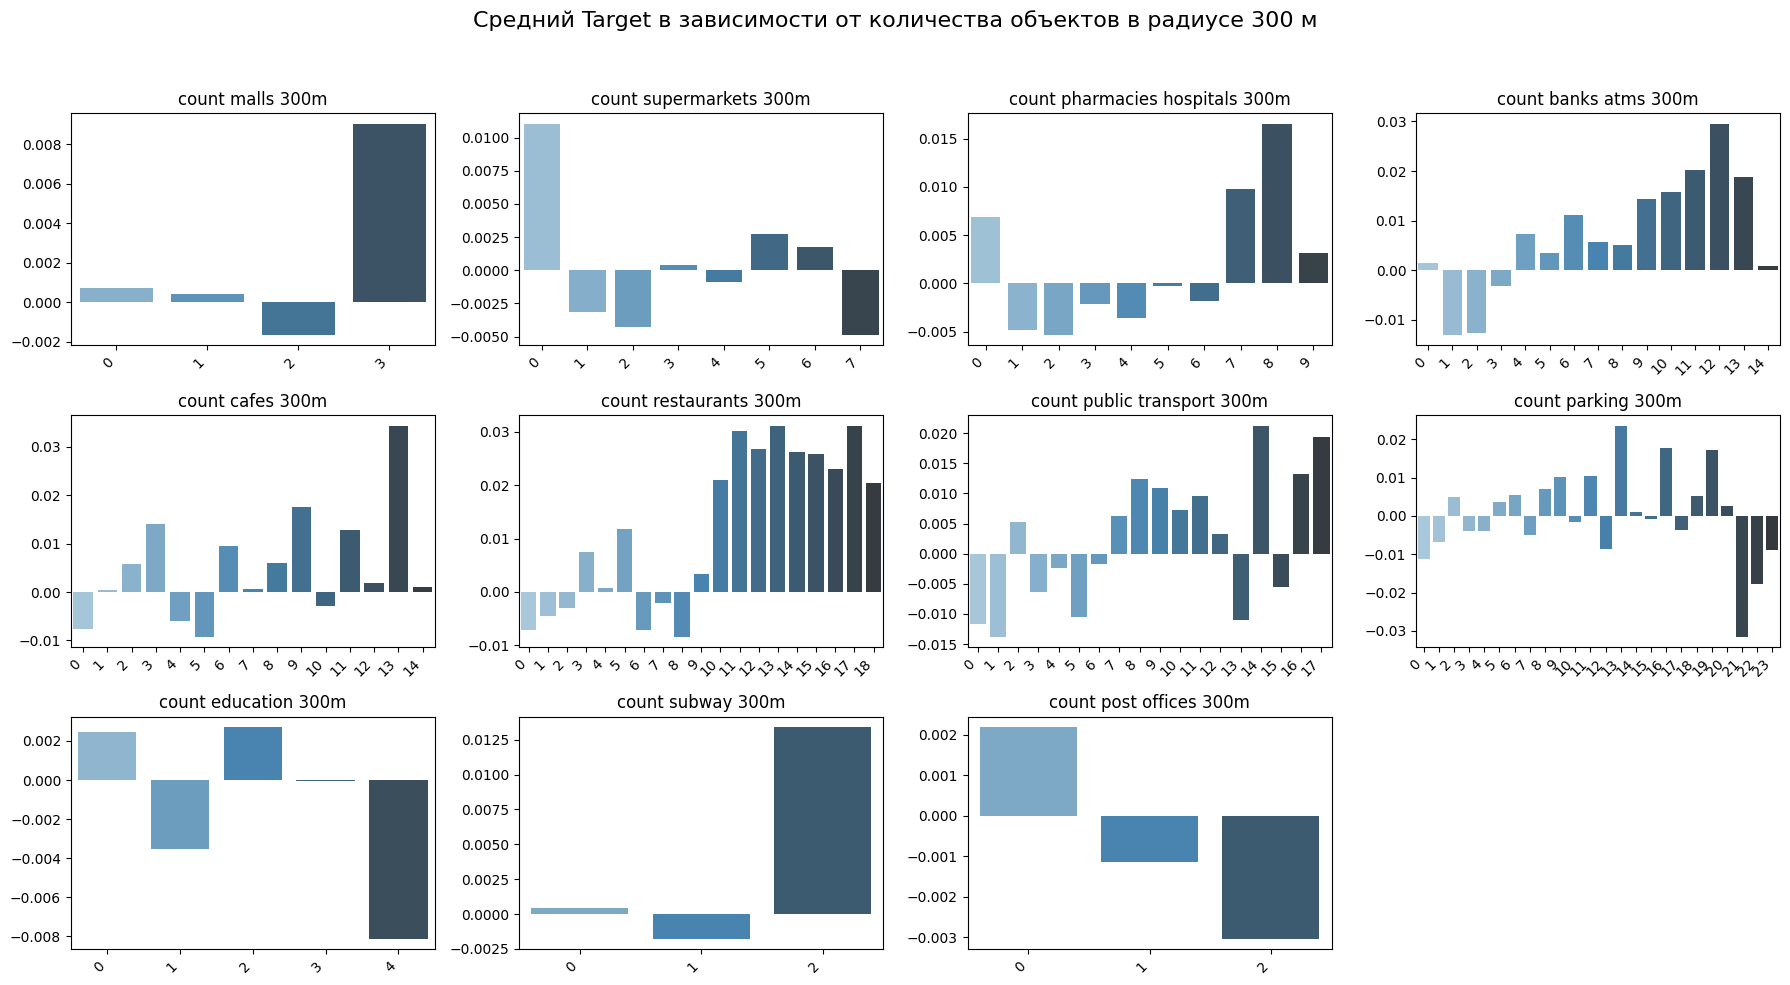

In [ ]:
# Создаем список с кол-вом объектов в радиусе 300 метров
# Построим график зависимости количества объектов от среднего target
cols_300m = [
    'count_malls_300m',
    'count_supermarkets_300m',
    'count_pharmacies_hospitals_300m',
    'count_banks_atms_300m',
    'count_cafes_300m',
    'count_restaurants_300m',
    'count_public_transport_300m',
    'count_parking_300m',
    'count_education_300m',
    'count_subway_300m',
    'count_post_offices_300m'
]

# Задаем полотно
plt.figure(figsize=(18, 10))
plt.suptitle("Средний Target в зависимости от количества объектов в радиусе 300 м", fontsize=16)

for i, col in enumerate(cols_300m, 1):
    # Делаем "сетку" 3 на 4 для графиков
    plt.subplot(3, 4, i)

    micro_graph = train_df.groupby(col)['target'].mean().reset_index()

    # Обрезаем редкие большие значения
    max_val = train_df[col].quantile(0.95)
    micro_graph = micro_graph[micro_graph[col] <= max_val]

    # Задаем параметры графика
    sns.barplot(x=col, y='target', data=micro_graph, palette='Blues_d')
    plt.title(col.replace('_', ' '))
    plt.xlabel('')
    plt.ylabel('')
    # Поворачиваем подписи по оси X, чтобы они не налезали друг на друга
    plt.xticks(rotation=45, ha='right')

# Выраниваем подписи
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

*Анализ зависимости Target от количества объектов в радиусе 300 м*

Визуализация показывает, как меняется среднее значение индекса популярности банкомата в зависимости от количества объектов инфраструктуры рядом с банкоматом.

**Основные наблюдения:**

1. **Рост target при увеличении объектов:**
   - `count_banks_atms_300m`, `count_restaurants_300m`, `count_cafes_300m`.
   - Это _предварительно_ указывает, что банкоматы, расположенные в местах рядом с кафе, ресторанами и прочими банкоматами положительно влияют на `target` — вероятно, за счёт высокой пешеходной активности и концентрации людей.

2. **Нелинейная зависимость:**
   - `count_parking_300m`, `count_malls_300m`, `count_pharmacies_hospitals_300m`, `count_public_transport_300m`, `count_subway_300m`, `count_supermarkets_300m`, `count_education_300m`  показывают **смешанную динамику** влияния на `target`.
   - Это может указывать на факт того, что указанные объекты по отдельности не имеют большого веса в формировании индекса популярности (т.е. данные объекты могут являться дополнением к более важной инфраструктуре, которая в большей мере влияет на формирование индекса популярности).

3. **Отрицательная зависимость:**
   - Для `count_post_offices_300m` наблюдается **отрицательная корреляция**.
   - Вероятно, этот объекты не формирует значительный поток пользователей для банкоматов.

**Вывод:**
- По отдельности большинство объектов не имеют прямой зависимости с `target`. Индекс популрности, вероятно, формируется за счет расположения _множества_ инфраструктурных объектов вокруг банкомата.  

- В дальнейшей модели стоит рассмотреть возможность **агрегировать** их в общий показатель «интенсивности инфраструктуры» вокруг банкомата.

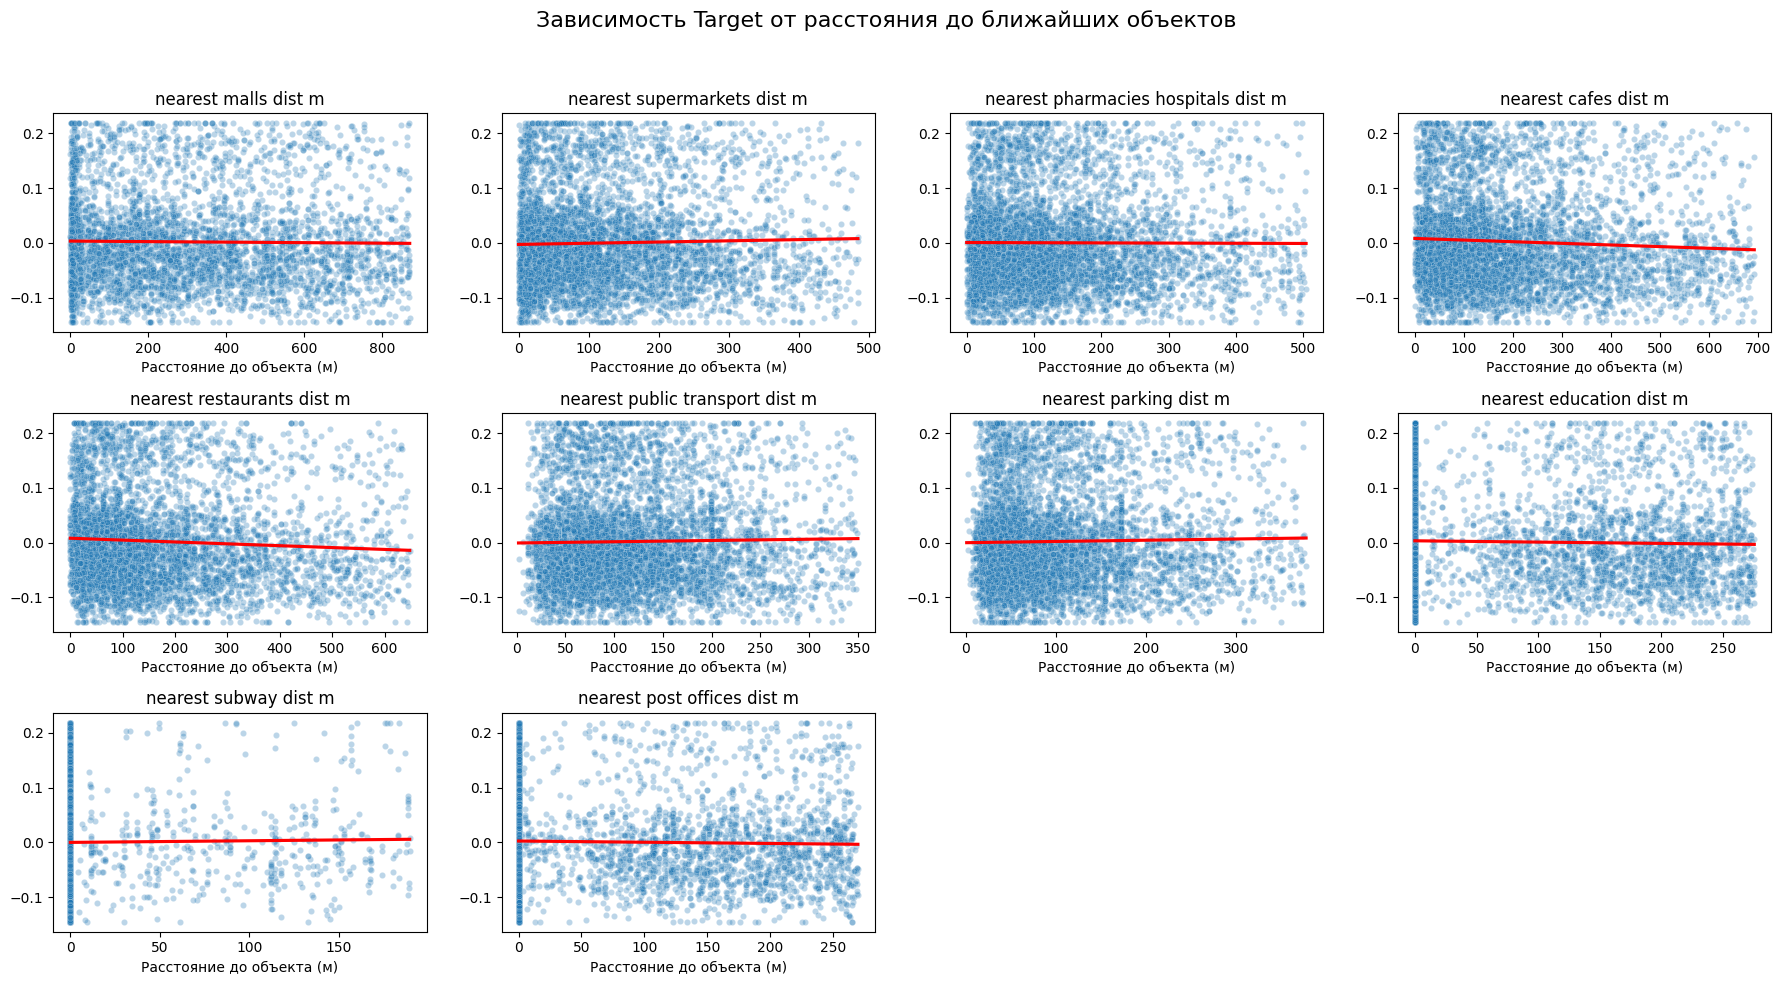

In [13]:
# Создаем список с дистанциями до ближайших объектов
# Построим график зависимости расстояния до объекта от среднего target

dist_cols = [
    'nearest_malls_dist_m',
    'nearest_supermarkets_dist_m',
    'nearest_pharmacies_hospitals_dist_m',
    'nearest_cafes_dist_m',
    'nearest_restaurants_dist_m',
    'nearest_public_transport_dist_m',
    'nearest_parking_dist_m',
    'nearest_education_dist_m',
    'nearest_subway_dist_m',
    'nearest_post_offices_dist_m'
]

# Задаем полотно
plt.figure(figsize=(18, 10))
plt.suptitle("Зависимость Target от расстояния до ближайших объектов", fontsize=16)

for i, col in enumerate(dist_cols, 1):
    plt.subplot(3, 4, i)

    # Приводим значения столбца к числовому типу
    train_df[col] = pd.to_numeric(train_df[col], errors='coerce')

    # Обрезаем экстремальные значения
    max_val = train_df[col].quantile(0.95)
    data = train_df[train_df[col] <= max_val]

    # Задаем параметры диаграммы
    sns.scatterplot(x=col, y='target', data=data, alpha=0.3, s=20)
    # Добавляем линию регрессии
    sns.regplot(x=col, y='target', data=data, scatter=False, color='red', ci=None)

    plt.title(col.replace('_', ' '))
    plt.xlabel('Расстояние до объекта (м)')
    plt.ylabel('')
    plt.tight_layout()

# Выравниваем подписи
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


*Анализ зависимости Target от расстояния до ближайших объектов*

На графиках видно, что сильной зависимости между расстоянием до ближайших объектов и `target` **не наблюдается**.  
Для большинства категорий объектов линия тренда почти горизонтальна.

Можно отметить несколько слабых тенденций:
- Для `nearest_restaurants_dist_m`, `nearest_cafes_dist_m` и `nearest_education_dist_m` наблюдается **слабая отрицательная зависимость** — чем ближе объект, тем немного выше значение `target`.  

**Вывод:**  
Фактор расстояния до ближайших объектов (по отдельности) оказывает **слабое и неоднозначное влияние** на `target`.  

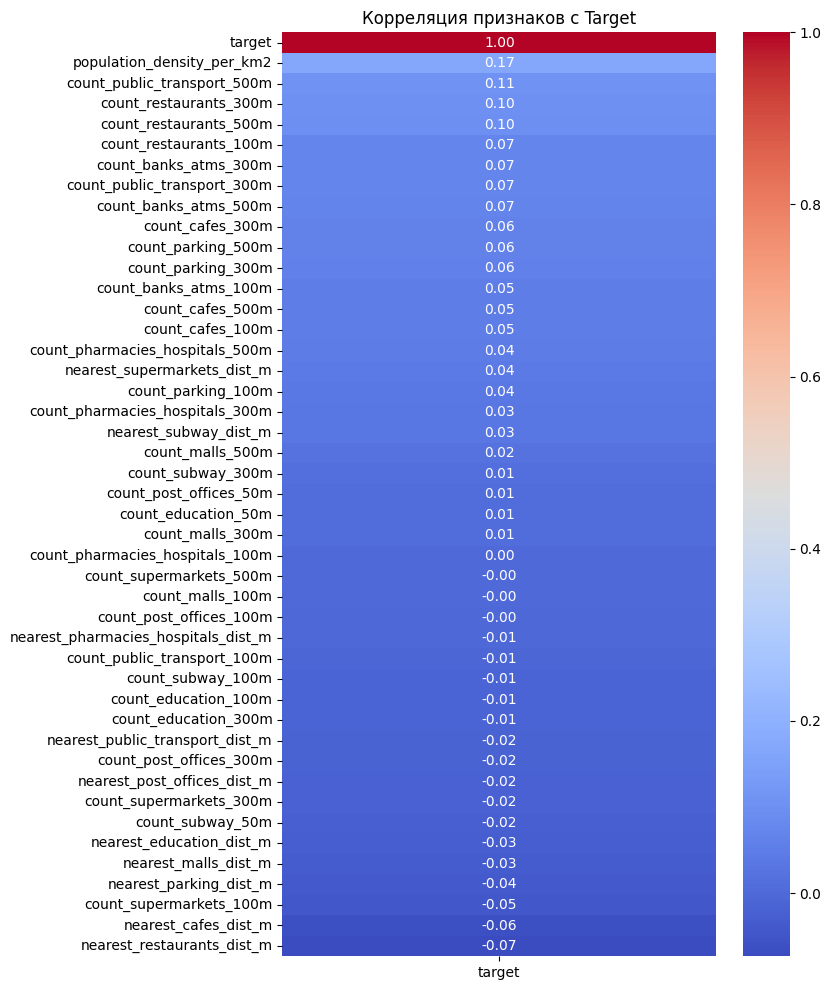

In [14]:
# Визуализируем корелляцию признаков с целевой переменной Target

# Исключаем неревантные признаки для построения корреляции с целевой переменной
exclude_cols = ['atm_group', 'geo_lon', 'geo_lat', 'id', 'is_train']
corr = train_df.drop(columns=exclude_cols, errors='ignore').corr(numeric_only=True)
plt.figure(figsize=(7,12))
# Задаем параметры тепловой карты
sns.heatmap(corr[['target']].sort_values(by='target', ascending=False), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Корреляция признаков с Target")
plt.show()

Корреляция признаков с `Target`

Корреляция показывает, что сильных связей между признаками и `target` **нет** — все значения корреляции находятся в диапазоне от -0.07 до 0.17.

**Основные наблюдения:**
- Наиболее значимые положительные корреляции наблюдаются у:
  - `population_density_per_km2` (r ≈ 0.17)
  - `count_public_transport_500m` (r ≈ 0.11)
  - `count_restaurants_300m` (r ≈ 0.10)  
  что указывает на небольшое положительное влияние плотности населения  
  и транспортной и пищевой инфраструктуры на `target`.

При этом влияние стоит отметить, что признаки расстояний до ближайших объектов практически не влияют на `target`.


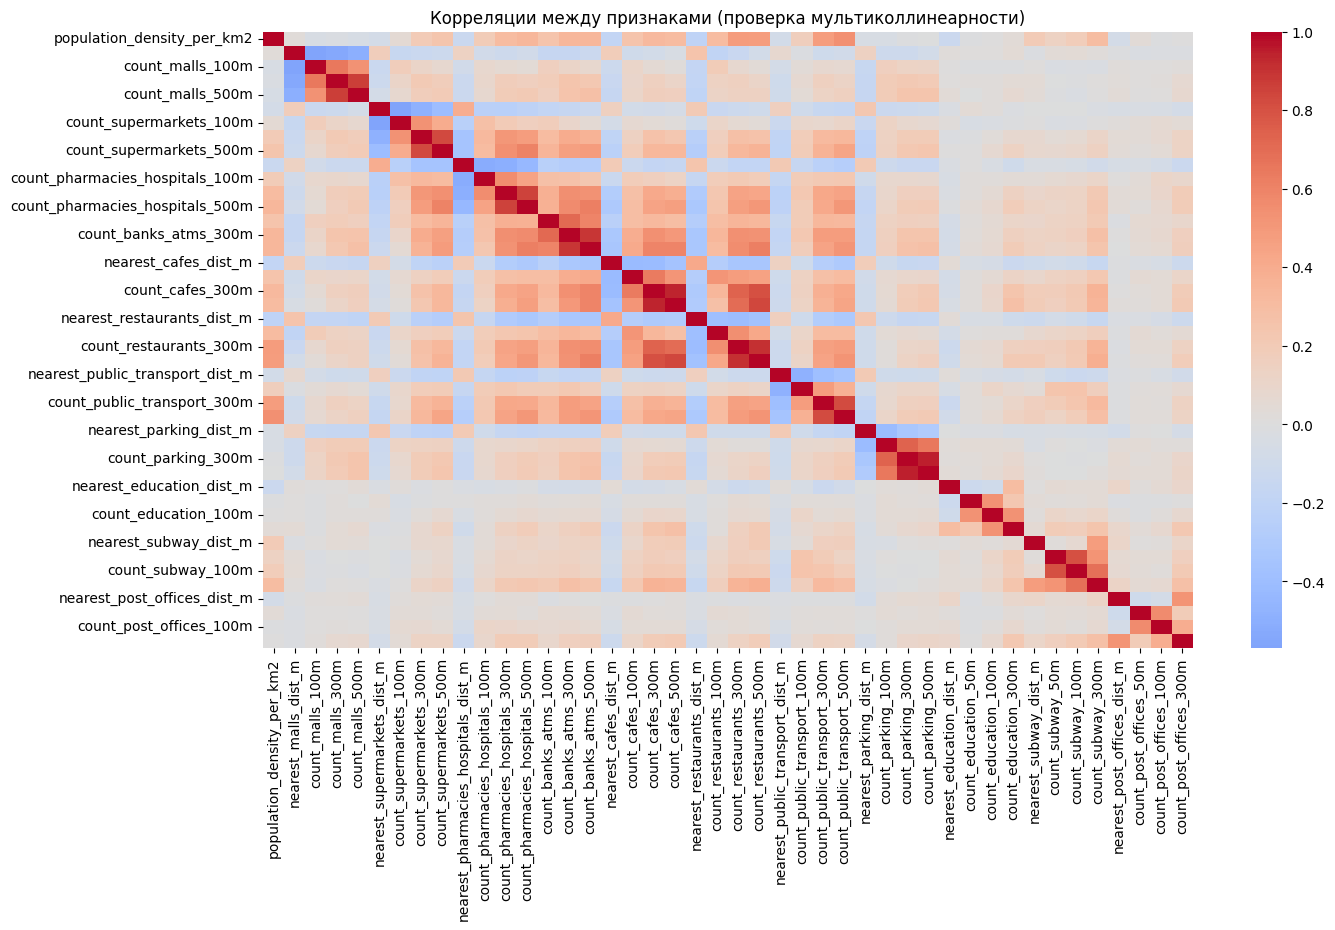

In [15]:
# Проверка признаков на мультиколлинеарность
# Проверка #1 - визуализация коррелляции между признаками

# Исключаем неревантные признаки для построения попарной корреляции
num_df = train_df.select_dtypes('number').drop(columns=['target', 'atm_group', 'geo_lon', 'geo_lat', 'id', 'is_train'], errors='ignore')

corr = num_df.corr()

plt.figure(figsize=(15, 8))
# Задаем параметры тепловой карты
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Корреляции между признаками (проверка мультиколлинеарности)")
plt.show()

In [16]:
# Проверка #2 - Выявляем признаки, которые сильно кореллируют между собой

# Создаем корреляционную матрицу с абсолютными значениями
corr_matrix = num_df.corr().abs()
# Обнуляем диагональ, чтобы она не попала в анализ
np.fill_diagonal(corr_matrix.values, 0)

# Разделяем пары признаков на сильную, среднюю и слабую корреляцию
strong_pairs = []
moderate_pairs = []
weak_pairs = []

# Перебираем все возможные пары признаков для расчета корреляции
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        col1, col2 = corr_matrix.columns[i], corr_matrix.columns[j]
        corr_val = corr_matrix.iloc[i, j]

        # Фильтруем значения корреляции (т.е. опредляем силу)
        if corr_val >= 0.7:
            strong_pairs.append((col1, col2, round(corr_val, 2)))
        elif 0.4 <= corr_val < 0.7:
            moderate_pairs.append((col1, col2, round(corr_val, 2)))
        elif 0 <= corr_val < 0.4:
            weak_pairs.append((col1, col2, round(corr_val, 2)))

# Выводим кол-во пар в каждой категории корреляции
print("Сильная корреляция (r ≥ 0.7):", len(strong_pairs))
print("Средняя корреляция (0.4 ≤ r < 0.7):", len(moderate_pairs))
print("Слабая корреляция (0 ≤ r < 0.4):", len(weak_pairs))

# Преобразуем списки категорий корреляции для удобного анализа
strong_df = pd.DataFrame(strong_pairs, columns=["feature_1", "feature_2", "corr"])
moderate_df = pd.DataFrame(moderate_pairs, columns=["feature_1", "feature_2", "corr"])
weak_df = pd.DataFrame(weak_pairs, columns=["feature_1", "feature_2", "corr"])


Сильная корреляция (r ≥ 0.7): 14
Средняя корреляция (0.4 ≤ r < 0.7): 84
Слабая корреляция (0 ≤ r < 0.4): 848


In [17]:
strong_df

,feature_1,feature_2,corr
0,count_malls_300m,count_malls_500m,0.87
1,count_supermarkets_300m,count_supermarkets_500m,0.83
2,count_pharmacies_hospitals_300m,count_pharmacies_hospitals_500m,0.85
3,count_banks_atms_100m,count_banks_atms_300m,0.72
4,count_banks_atms_300m,count_banks_atms_500m,0.89
5,count_cafes_300m,count_cafes_500m,0.93
6,count_cafes_300m,count_restaurants_300m,0.74
7,count_cafes_300m,count_restaurants_500m,0.81
8,count_cafes_500m,count_restaurants_500m,0.84
9,count_restaurants_300m,count_restaurants_500m,0.90


In [18]:
moderate_df

,feature_1,feature_2,corr
0,population_density_per_km2,count_restaurants_300m,0.49
1,population_density_per_km2,count_restaurants_500m,0.48
2,population_density_per_km2,count_public_transport_300m,0.48
3,population_density_per_km2,count_public_transport_500m,0.55
4,nearest_malls_dist_m,count_malls_100m,0.57
...,...,...,...
79,nearest_subway_dist_m,count_subway_300m,0.48
80,count_subway_50m,count_subway_300m,0.52
81,count_subway_100m,count_subway_300m,0.68
82,nearest_post_offices_dist_m,count_post_offices_300m,0.53


Проверка мультиколлинеарности признаков

Анализ показал наличие **мультиколлинеарности** между рядом признаков, в основном — между переменными, которые содержат в себе одну и ту же суть (например, количество объектов Х в радиусе 100/300/500 м).

**Основные наблюдения:**
- Всего найдено:
  - 14 пар признаков с **сильной корреляцией** (r ≥ 0.7),
  - 84 пары с **умеренной корреляцией** (0.4 ≤ r < 0.7),
  - 848 пар со **слабой корреляцией** (r < 0.4).
- Отдельно стоит отметить признак **`population_density_per_km2`**, который демонстрирует положительную корреляцию с инфраструктурными объектами (например, кол-во торговых центров, транспортные узлы и пр.). Это указывает на логичное и правильное размещение коммерческих и транспортных объектов.

**Вывод:**
- Мультиколлинеарность присутствует **в пределах схожих категорий признаков** (Например, разные радиусы для одной сущности).  
- Для снижения влияния мультиколлинеарности требуется:
  - оставить только один показатель из каждой сильно коррелирующей пары,  
  - либо агрегировать значения признаков.

# EDA. Плотность конкурентов

Исследовать влияние плотности банкоматов на индекс популярности.

In [19]:
#Осталяем только столбцы связанные с количеством конкурентов банкоматов
cols = ["count_banks_atms_100m","count_banks_atms_300m","count_banks_atms_500m","target"]
atms = df[cols].copy()
atms = atms.replace([np.inf,-np.inf], np.nan).dropna()
atms[cols] = atms[cols].apply(pd.to_numeric, errors="coerce").fillna(0)
atms[cols].describe()

,count_banks_atms_100m,count_banks_atms_300m,count_banks_atms_500m,target
count,6200.000000,6200.000000,6200.000000,6200.000000
mean,1.516774,4.276935,7.572258,0.000829
std,2.103096,5.117801,8.502314,0.085932
min,0.000000,0.000000,0.000000,-0.145001
25%,0.000000,1.000000,2.000000,-0.061170
50%,1.000000,3.000000,5.000000,-0.015454
75%,2.000000,6.000000,11.000000,0.040201
max,23.000000,45.000000,82.000000,0.218608


**count_banks_atms_100m**


*  В радиусе 100 м вокруг банкомата в среднем ≈ 1.5 конкурента, медиана = 1, но 25 % точек вообще без конкурентов (0).

* ***Есть выбросы до 23 банкоматов в 100 м — это явно  ТЦ, вокзалы и т.п.***

**count_banks_atms_300m**

*   В радиусе 300 м среднее ≈ 4.3, медиана = 3.
То есть большинство банкоматов окружены несколькими конкурентами в пешей доступности.

**count_banks_atms_500m**

*   В радиусе 500 м среднее ≈ 7.6, медиана = 5.

In [20]:
#Возьмем размах между 2.5% и 97.5% квантилями, чтобы избавиться от выбросов
cols = [c for c in atms.columns if c != "target"]

l = 0.025
u = 0.975

q_summary = (
    atms[cols]
    .quantile([l, u])
    .T
    .rename(columns={l: "q025", u: "q975"})
)
q_summary["range_q025_q975"] = q_summary["q975"] - q_summary["q025"]
print("Размах между 2.5% и 97.5% квантилями:")
display(q_summary)

Размах между 2.5% и 97.5% квантилями:


,q025,q975,range_q025_q975
count_banks_atms_100m,0.0,7.000,7.000
count_banks_atms_300m,0.0,19.000,19.000
count_banks_atms_500m,0.0,29.025,29.025


In [21]:
bounds = atms[cols].quantile([l, u])
lower = bounds.loc[l]
upper = bounds.loc[u]
print(f"Размер до: {len(atms)}")

atms = atms[
    ((atms[cols] >= lower) & (atms[cols] <= upper)).all(axis=1)
].copy()

print(f"после фильтрации: {len(atms)}")

Размер до: 6200
после фильтрации: 5907


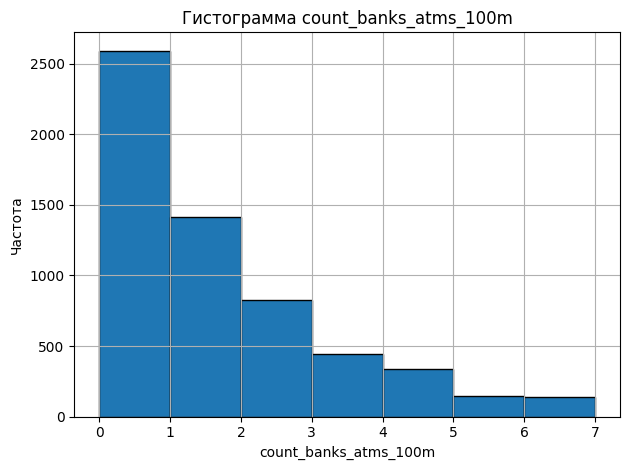

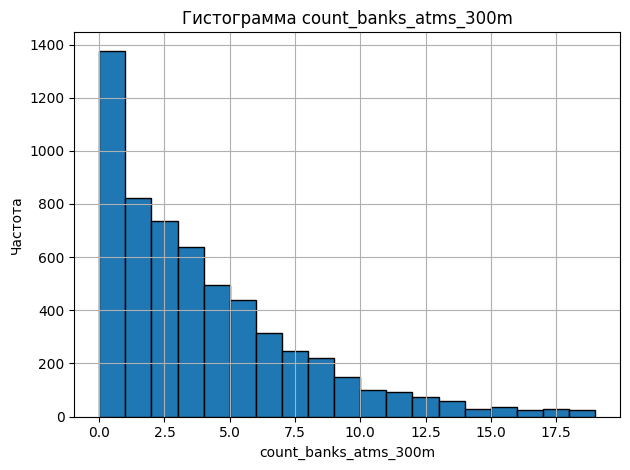

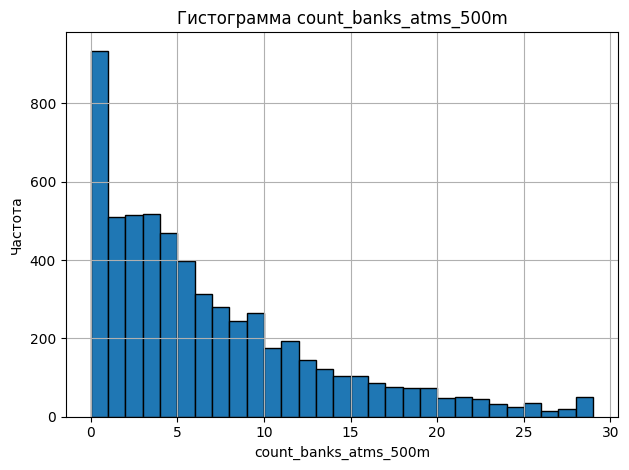

In [22]:
for col in cols:
    plt.figure()
    atms[col].hist(bins="auto", edgecolor="black")
    plt.title(f"Гистограмма {col}")
    plt.xlabel(col)
    plt.ylabel("Частота")
    plt.tight_layout()
    plt.show()

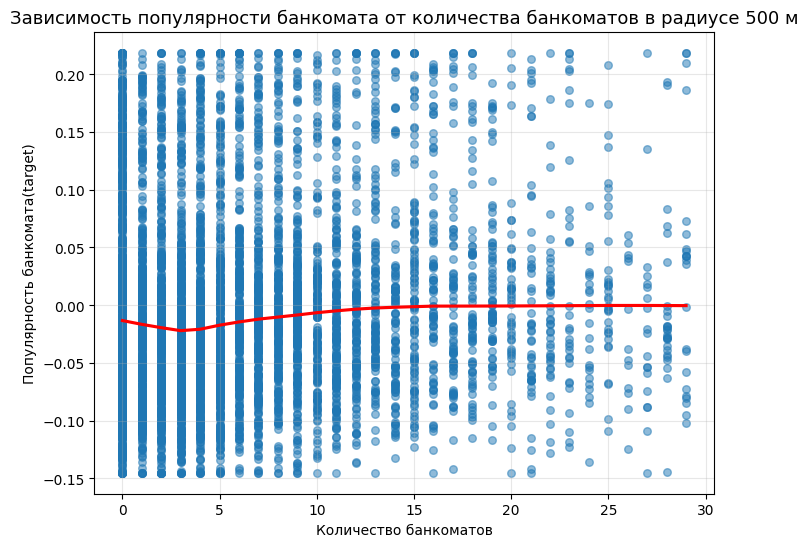

In [23]:

plt.figure(figsize=(8,6))
sns.regplot(
    data = atms,
    x = 'count_banks_atms_500m',
    y = 'target',
    scatter_kws = {"alpha":0.5, "s":30},
    line_kws = {"color":"red"},
    lowess = True
)
plt.title("Зависимость популярности банкомата от количества банкоматов в радиусе 500 м", fontsize=13)
plt.xlabel("Количество банкоматов")
plt.ylabel("Популярность банкомата(target)")
plt.grid(True, alpha=0.3)
plt.show()

1.   Явной линейной зависимости нет. Популярность банкомата не растёт и не падает заметно с увеличением количества соседних банкоматов.
2.  Средняя тенденция (красная линия) остаётся около нуля, лишь незначительно возрастая при увеличении плотности. Это говорит о слабой положительной корреляции.
3. Разброс (вариация target) большой, что может означать влияние других факторов (расположение, банк, тип банкомата и т.п.).

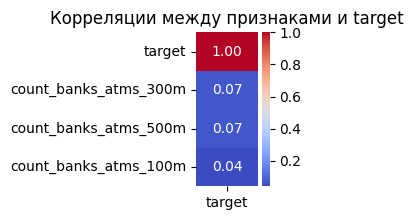

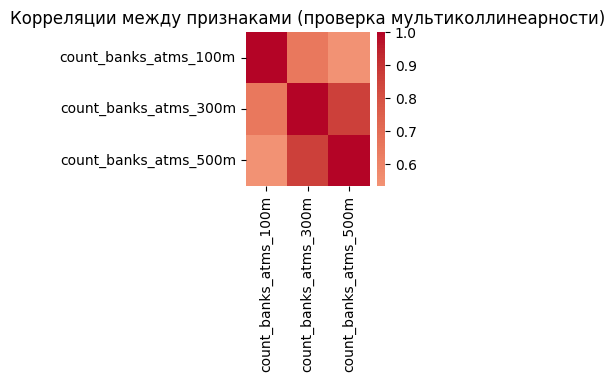

In [24]:
#Корреляция между target и количеством банкоматов в 100/300/500 м
plt.figure(figsize=(1, 2))
sns.heatmap(atms.corr()[['target']].sort_values(by='target', ascending=False),
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Корреляции между признаками и target")
plt.show()

#Рассмотрим, насколько коллинерны признаки количества банкоматов в 100/300/500м

collinear = atms[["count_banks_atms_100m","count_banks_atms_300m","count_banks_atms_500m"]].corr()
plt.figure(figsize=(2, 2))
sns.heatmap(collinear, cmap='coolwarm', center=0)
plt.title("Корреляции между признаками (проверка мультиколлинеарности)")
plt.show()

Корреляции с target очень низкие:

`count_banks_atms_100m: 0.04`

`count_banks_atms_300m: 0.07`

`count_banks_atms_500m: 0.07`

Это говорит о слабой зависимости между количеством банкоматов в радиусе и их популярностью.
Вероятно, количество соседних банкоматов не оказывает существенного влияния на показатель target.

Так как признаки мультиколлинеарны:

перейдем от количества банкоматов в 100/300/500м к плотности банкоматов в непересекающихся зонах от 0 до 100м, от 100 до 300м, от 300 до 500м

In [25]:
# кольцевые счётчики
dens = pd.DataFrame()
area = lambda r: np.pi * (r / 1000) ** 2 #лямбда функция для вычисления площади в кв. км
dens["ring_0_100"]   = atms["count_banks_atms_100m"]
dens["ring_100_300"] = atms["count_banks_atms_300m"] - atms["count_banks_atms_100m"]
dens["ring_300_500"] = atms["count_banks_atms_500m"] - atms["count_banks_atms_300m"]

# площади колец
a_0_100   = area(100) - area(0)
a_100_300 = area(300) - area(100)
a_300_500 = area(500) - area(300)

# плотности в кольцах
dens["dens_0_100"]   = dens["ring_0_100"]   / a_0_100
dens["dens_100_300"] = dens["ring_100_300"] / a_100_300
dens["dens_300_500"] = dens["ring_300_500"] / a_300_500

dens["target"] = atms["target"]


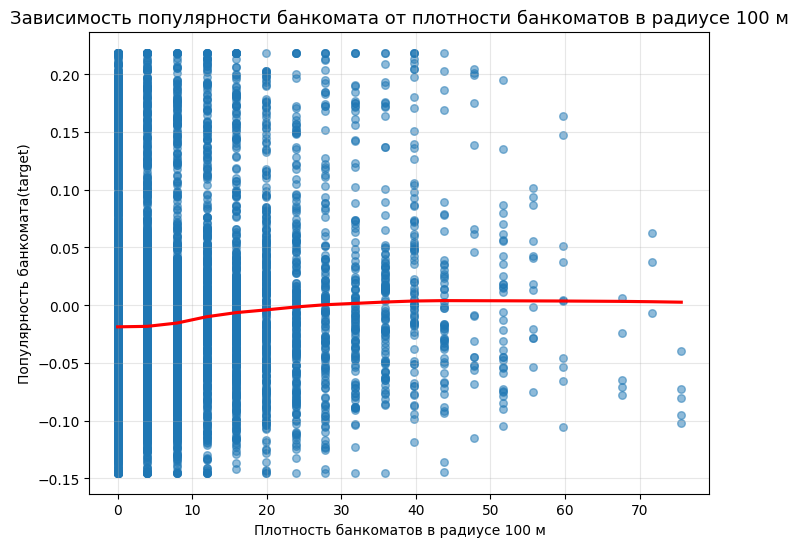

In [26]:
plt.figure(figsize=(8,6))
sns.regplot(
    data = dens,
    x = 'dens_100_300',
    y = 'target',
    scatter_kws = {"alpha":0.5, "s":30},
    line_kws = {"color":"red"},
    lowess = True
)
plt.title("Зависимость популярности банкомата от плотности банкоматов в радиусе 100 м", fontsize=13)
plt.xlabel("Плотность банкоматов в радиусе 100 м")
plt.ylabel("Популярность банкомата(target)")
plt.grid(True, alpha=0.3)
plt.show()

Анализ зависимости популярности банкоматов (target) от плотности банкоматов вокруг показывает слабую нелинейную связь:

*   График является восходящим, что может указывать на умеренное увеличение target при росте плотности банкоматов. Тем не менее амплитуда изменений незначительна, основная масса точек сосредоточена вокруг нулевого уровня.
*   Это говорит о том, что высокая концентрация банкоматов конкурентов не обязательно снижает target.

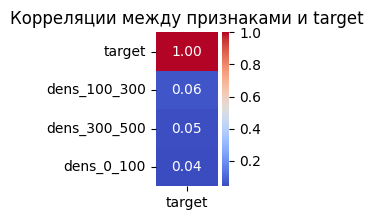

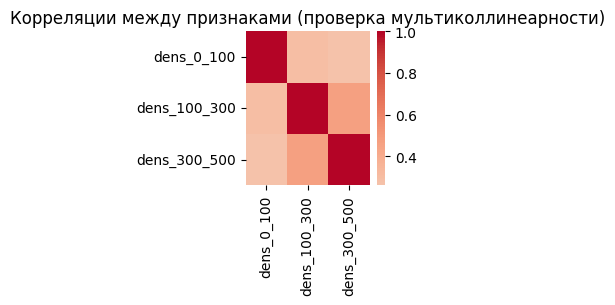

In [27]:
#Проведем для новых признаков анализ на коррелляции и коллинеарность
corrs = dens[["target","dens_0_100","dens_100_300","dens_300_500"]].corr()
collinear = dens[["dens_0_100","dens_100_300","dens_300_500"]].corr()

plt.figure(figsize=(1, 2))
sns.heatmap(corrs[["target"]].sort_values(by="target", ascending=False),
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Корреляции между признаками и target")
plt.show()

plt.figure(figsize=(2, 2))
sns.heatmap(collinear, cmap='coolwarm', center=0)
plt.title("Корреляции между признаками (проверка мультиколлинеарности)")
plt.show()

Переход от показателей по количествам банкоматов в радиусах (100/300/500) к кольцам плотности (0–100, 100–300, 300–500) решил проблему мультиколлинеарности.

**Выводы из корреляций:**

*   Все корреляции с target — слабые и положительные (≈ 0.04–0.06).
*   Это говорит о том, что прямая линейная связь между плотностью банкоматов конкурентов и популярностью банкомата почти отсутствует.
*   Значит, влияние конкурентов, если оно есть, скорее нелинейное или объясняется другими факторами (например типом локации, плотсностью населения, трафиком и т. д.).


**Итоговый вывод:**

Конкуренция вокруг точки сама по себе оказывает небольшое и нелинейное влияние на target.
Признак «плотности» можно использовать в составе модели с другими геопризнаками.

# EDA. Визуализация данных на карте. Покрытие данных

In [28]:
# === 1. Приведение названий городов/районов ===
for col in ["region", "municipality", "city"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.title()

# === 2. Столбцы с количественной инфраструктурой ===
count_cols = [c for c in df.columns if c.startswith("count_")]

# === 3. Суммарная инфраструктура вокруг каждого банкомата ===
df["infra_total_50m"] = df[[c for c in count_cols if c.endswith("50m")]].sum(axis=1).fillna(0)
df["infra_total_100m"] = df[[c for c in count_cols if c.endswith("100m")]].sum(axis=1).fillna(0)
df["infra_total_300m"] = df[[c for c in count_cols if c.endswith("300m")]].sum(axis=1).fillna(0)
df["infra_total_500m"] = df[[c for c in count_cols if c.endswith("500m")]].sum(axis=1).fillna(0)

# Округление — по умолчанию 2 знака
infra_cols = ["infra_total_50m", "infra_total_100m", "infra_total_300m", "infra_total_500m"]
df[infra_cols] = df[infra_cols].round(2)

# === 4. Городская аналитика: сумма + среднее ===
city_stats = df.groupby("city").agg(
    atms_count=("id", "nunique"),
    infra_50m_sum=("infra_total_50m", "sum"),
    infra_100m_sum=("infra_total_100m", "sum"),
    infra_300m_sum=("infra_total_300m", "sum"),
    infra_500m_sum=("infra_total_500m", "sum"),
    infra_50m_avg=("infra_total_50m", "mean"),
    infra_100m_avg=("infra_total_100m", "mean"),
    infra_300m_avg=("infra_total_300m", "mean"),
    infra_500m_avg=("infra_total_500m", "mean"),
).reset_index()

# Округление сумм и средних
sum_avg_cols = [c for c in city_stats.columns if "sum" in c or "avg" in c]
city_stats[sum_avg_cols] = city_stats[sum_avg_cols].round(2)

# === 4.1 Дополнительные метрики плотности ===

# Плотность на 1 банкомат — среднее кол-во объектов в 500м на один банкомат
city_stats["infra_density_500m"] = (city_stats["infra_500m_sum"] / city_stats["atms_count"]).round(2)

# Нормированная плотность — "объекты на каждые 500 м"
city_stats["infra_density_norm_500m"] = (city_stats["infra_500m_sum"] / 500).round(2)

# Географическая плотность — объекты на км² (площадь зоны = π * r^2)
AREA_500M_KM2 = math.pi * (500**2) / 1e6  # ≈ 0.7854 км²
city_stats["infra_density_per_km2"] = (city_stats["infra_500m_sum"] / AREA_500M_KM2).round(2)

# Фильтр нерепрезентативных городов
city_stats_filtered = city_stats[city_stats["atms_count"] >= 3]

print('\nТоп-5 городов с наибольшим количеством банкоматов в городе:')
display(city_stats_filtered.sort_values("atms_count", ascending=False).head(5))


# === 5. Аналитика по владельцам банкоматов (atm_group) ===
bank_stats = df.groupby("atm_group").agg(
    atms_count=("id", "nunique"),
    avg_infra_500m=("infra_total_500m", "mean"),
    median_infra_500m=("infra_total_500m", "median")
).reset_index()

# Округление
bank_stats[["avg_infra_500m", "median_infra_500m"]] = bank_stats[["avg_infra_500m", "median_infra_500m"]].round(2)

# Фильтр: минимум 10 банкоматов у банка
bank_stats = bank_stats[bank_stats["atms_count"] >= 10]



Топ-5 городов с наибольшим количеством банкоматов в городе:


,city,atms_count,infra_50m_sum,infra_100m_sum,infra_300m_sum,infra_500m_sum,infra_50m_avg,infra_100m_avg,infra_300m_avg,infra_500m_avg,infra_density_500m,infra_density_norm_500m,infra_density_per_km2
325,Москва,860,133,9841,52863,104648,0.15,11.44,61.47,121.68,121.68,209.30,133241.97
638,Санкт-Петербург,292,74,4870,23147,43332,0.25,16.68,79.27,148.40,148.40,86.66,55172.02
252,Красноярск,243,18,1284,7932,17561,0.07,5.28,32.64,72.27,72.27,35.12,22359.36
360,Новосибирск,241,71,1954,9556,18172,0.29,8.11,39.65,75.40,75.40,36.34,23137.31
379,Омск,196,27,1307,6186,12127,0.14,6.67,31.56,61.87,61.87,24.25,15440.58


In [29]:
print("\n=== АНАЛИТИКА ПО ГОРОДАМ ===")

print("\nТоп-10 городов по средней инфраструктуре в радиусе 500м на 1 банкомат:")
top_avg = city_stats_filtered.sort_values("infra_500m_avg", ascending=False).head(10)
display(top_avg[["city", "atms_count", "infra_500m_avg", "infra_density_500m", "infra_density_per_km2"]])

print("\nАнтилидеры по средней инфраструктуре в радиусе 500м на 1 банкомат (ниже всего объектов вокруг):")
bottom_avg = city_stats_filtered.sort_values("infra_500m_avg", ascending=True).head(10)
display(bottom_avg[["city", "atms_count", "infra_500m_avg", "infra_density_500m", "infra_density_per_km2"]])


print("\n=== ДОПОЛНИТЕЛЬНЫЕ МЕТРИКИ ПО ГОРОДАМ ===")

print("\nТоп-10 городов по нормированной плотности объектов (объектов на каждые 500м):")
display(city_stats_filtered.sort_values("infra_density_norm_500m", ascending=False).head(10)[
    ["city", "infra_500m_sum", "infra_density_norm_500m"]
])

print("\nТоп-10 городов по географической плотности объектов (объектов на км²):")
display(city_stats_filtered.sort_values("infra_density_per_km2", ascending=False).head(10)[
    ["city", "infra_500m_sum", "infra_density_per_km2"]
])

print("\nАнтилидеры по географической плотности объектов (объекты на км²):")
display(city_stats_filtered.sort_values("infra_density_per_km2", ascending=True).head(10)[
    ["city", "infra_500m_sum", "infra_density_per_km2"]
])


print("\n=== АНАЛИТИКА ПО БАНКАМ (ATM GROUP) ===")

print("\nТоп-5 банков с самой насыщенной инфраструктурой вокруг банкоматов (500м):")
display(bank_stats.sort_values("avg_infra_500m", ascending=False).head(5))

print("\nАнтилидеры по инфраструктуре вокруг банкоматов (500м):")
display(bank_stats.sort_values("avg_infra_500m", ascending=True).head(5))



=== АНАЛИТИКА ПО ГОРОДАМ ===

Топ-10 городов по средней инфраструктуре в радиусе 500м на 1 банкомат:


,city,atms_count,infra_500m_avg,infra_density_500m,infra_density_per_km2
83,Владивосток,150,231.63,231.63,44237.43
624,Реутов,9,202.56,202.56,2321.12
200,Калуга,30,157.73,157.73,6024.97
21,Архангельск,21,156.14,156.14,4174.95
638,Санкт-Петербург,292,148.40,148.40,55172.02
175,Зеленоград,8,137.00,137.00,1395.47
793,Снт Нижняя Колония,4,136.75,136.75,696.46
325,Москва,860,121.68,121.68,133241.97
799,Сочи,44,112.91,112.91,6325.45
98,Выборг,7,106.86,106.86,952.38



Антилидеры по средней инфраструктуре в радиусе 500м на 1 банкомат (ниже всего объектов вокруг):


,city,atms_count,infra_500m_avg,infra_density_500m,infra_density_per_km2
181,Зима,3,1.00,1.00,3.82
440,Посёлок Городского Типа Каа-Хем,4,1.00,1.00,5.09
686,Село Ивановка,3,1.67,1.67,6.37
334,Называевск,3,3.67,3.67,14.01
454,Посёлок Городского Типа Курагино,3,4.67,4.67,17.83
756,Село Троицкое,5,6.40,6.40,40.74
870,Уяр,3,6.67,6.67,25.46
287,Лесосибирск,6,6.67,6.67,50.93
733,Село Первомайское,3,7.67,7.67,29.28
499,Посёлок Городского Типа Ясногорск,5,7.80,7.80,49.66



=== ДОПОЛНИТЕЛЬНЫЕ МЕТРИКИ ПО ГОРОДАМ ===

Топ-10 городов по нормированной плотности объектов (объектов на каждые 500м):


...

,city,infra_500m_sum,infra_density_per_km2
181,Зима,3,3.82
440,Посёлок Городского Типа Каа-Хем,4,5.09
686,Село Ивановка,5,6.37
334,Называевск,11,14.01
454,Посёлок Городского Типа Курагино,14,17.83
870,Уяр,20,25.46
733,Село Первомайское,23,29.28
737,Село Подгорное,26,33.10
62,Борисоглебск,30,38.20
483,Посёлок Городского Типа Серышево,31,39.47



=== АНАЛИТИКА ПО БАНКАМ (ATM GROUP) ===

Топ-5 банков с самой насыщенной инфраструктурой вокруг банкоматов (500м):


,atm_group,atms_count,avg_infra_500m,median_infra_500m
3,1942.0,1632,103.53,95.0
0,32.0,62,94.45,67.0
4,3185.5,813,67.43,51.0
2,1022.0,185,67.19,59.0
6,8083.0,1439,66.91,52.0



Антилидеры по инфраструктуре вокруг банкоматов (500м):


,atm_group,atms_count,avg_infra_500m,median_infra_500m
1,496.5,861,42.93,32.0
5,5478.0,3690,61.97,50.0
6,8083.0,1439,66.91,52.0
2,1022.0,185,67.19,59.0
4,3185.5,813,67.43,51.0


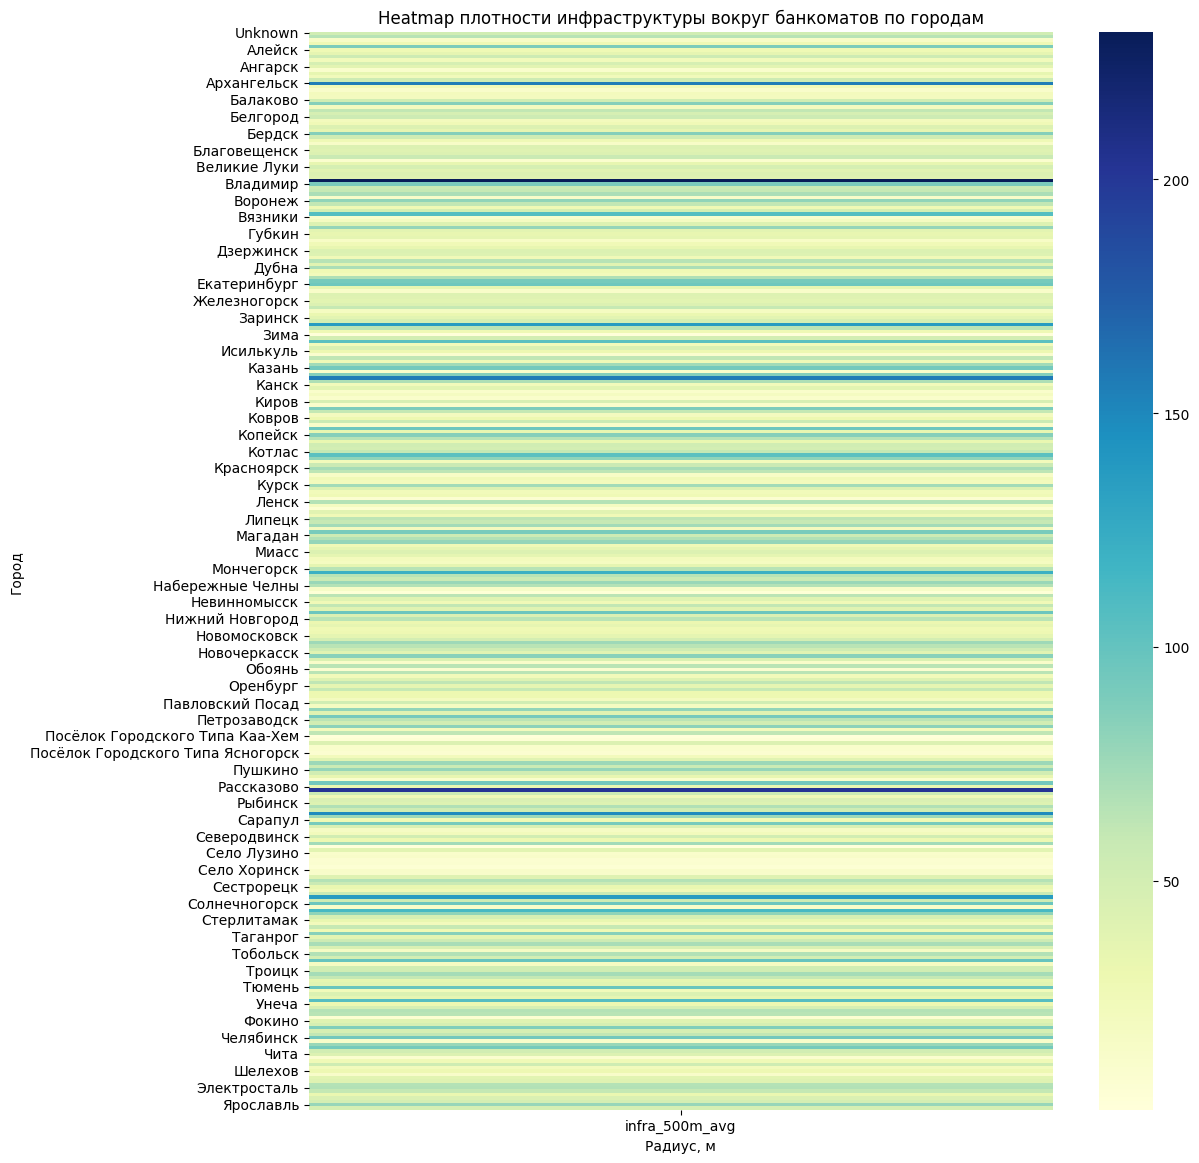

In [30]:
heatmap_data = city_stats_filtered.set_index("city")[["infra_500m_avg"]]

plt.figure(figsize=(12, 14))
sns.heatmap(heatmap_data, annot=False, cmap="YlGnBu")
plt.title("Heatmap плотности инфраструктуры вокруг банкоматов по городам")
plt.xlabel("Радиус, м")
plt.ylabel("Город")
plt.show()


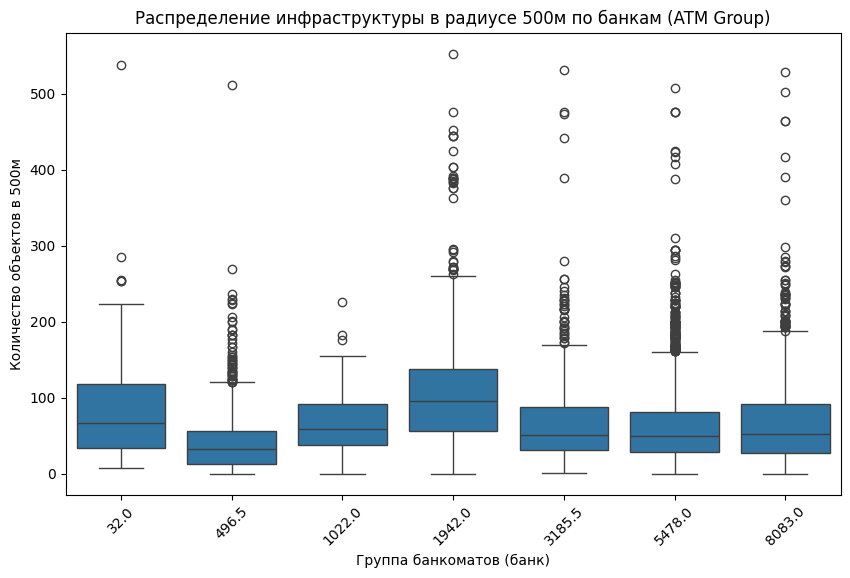

In [31]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="atm_group", y="infra_total_500m")
plt.xticks(rotation=45)
plt.title("Распределение инфраструктуры в радиусе 500м по банкам (ATM Group)")
plt.xlabel("Группа банкоматов (банк)")
plt.ylabel("Количество объектов в 500м")
plt.show()


C:\Users\steel\AppData\Local\Temp\ipykernel_29528\596235021.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


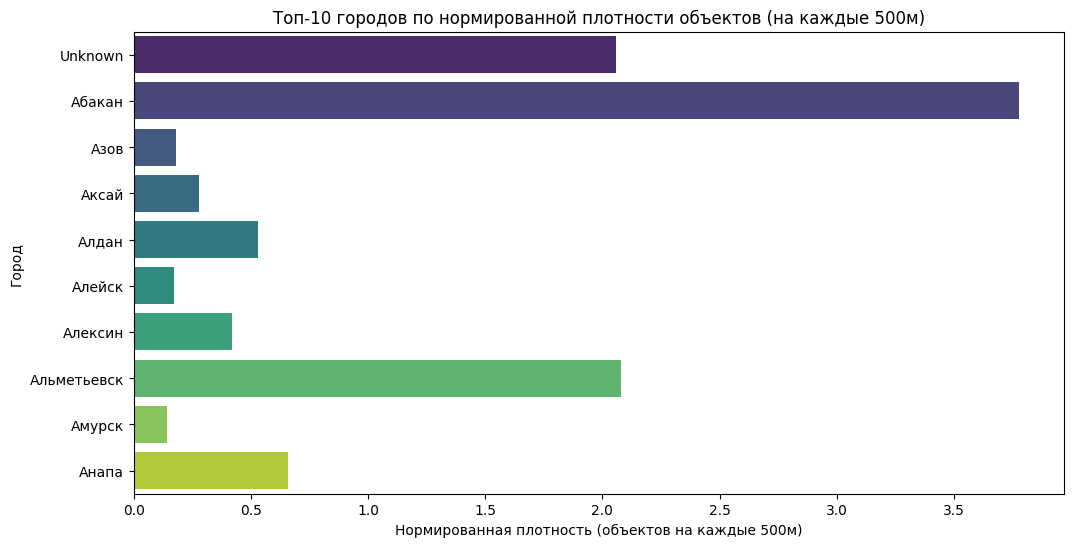

NameError: name 'bottom_norm_cities' is not defined

<Figure size 1200x600 with 0 Axes>

In [ ]:


# --- Визуализация TOP-10 нормированной плотности ---
plt.figure(figsize=(12, 6))
sns.barplot(
    data=city_stats_norm.head(10),
    x="infra_density_norm_500m", y="city", palette="viridis"
)
plt.title("Топ-10 городов по нормированной плотности объектов (на каждые 500м)")
plt.xlabel("Нормированная плотность (объектов на каждые 500м)")
plt.ylabel("Город")
plt.show()


# --- Визуализация Bottom-10 нормированной плотности ---
plt.figure(figsize=(12, 6))
sns.barplot(
    data=bottom_norm_cities,
    x="infra_density_norm_500m", y="city", palette="Reds_r"
)
plt.title("Антилидеры — города с минимальной нормированной плотностью объектов (на каждые 500м)")
plt.xlabel("Нормированная плотность (объектов на каждые 500м)")
plt.ylabel("Город")
plt.show()



###  **Выводы по географическому покрытию и плотности инфраструктуры вокруг банкоматов**

Данный анализ охватывает оценку инфраструктурной насыщенности в радиусе 50–500 метров вокруг банкоматов, с учетом географического распределения по городам и владельцам банкоматной сети (ATM Group). Метрики включают суммарное количество объектов, средние значения на 1 банкомат и нормированные показатели плотности.

---

### **1. Общие выводы по городам**

1. **Крупные города значительно превосходят малые населённые пункты по инфраструктурной доступности вокруг банкоматов.**
   Лидерами являются Москва, Санкт-Петербург, Владивосток и Новосибирск — они демонстрируют высокую среднюю и нормированную инфраструктурную плотность.

2. **Москва — абсолютный лидер по суммарному количеству объектов в радиусе 500 м**, что подтверждает высокую насыщенность городской среды коммерческими и социально-значимыми объектами.

3. **Санкт-Петербург и Владивосток показывают высокую инфраструктурную плотность при меньшей базе банкоматов**, что указывает на компактную и насыщенную городскую застройку.

4. **Антилидеры — малые города и посёлки городского типа**, такие как Зима, Каа-Хем, Ивановка, Називаевск, Кургино.
   Вокруг банкоматов в 500 м находится **меньше 5 объектов инфраструктуры**, что сигнализирует о слабой коммерческой активности и ограниченной доступности сервисов.

---

### **2. Географическая плотность инфраструктуры**

| Характеристика                               | Лидеры           | Антилидеры   |
| -------------------------------------------- | ---------------- | ------------ |
| Средняя инфраструктура в 500 м на 1 банкомат | 150–230 объектов | 1–8 объектов |
| Геоплотность (объекты на км²)                | > 40 000–130 000 | < 4–50       |

*Плотность прямо коррелирует с уровнем урбанизации, транспортной сетью и коммерческой активностью региона.*

---

### **3. Аналитика по владельцам банкоматов (ATM Group)**

1. **Разрыв между лидерами и аутсайдерами превышает 2,5 раза** по средней инфраструктуре на 500 м, что указывает на существенные различия в стратегии выбора локаций.

2. **Топ-5 банков размещают банкоматы преимущественно в инфраструктурно насыщенных зонах**, что повышает транзакционный потенциал и вероятность использования дополнительных банковских услуг.

3. **Банки-антилидеры чаще устанавливают банкоматы в низкоконкурентных, малых и удалённых локациях**, что снижает клиентопоток, но может быть частью стратегии покрытия менее обслуживаемых регионов.

4. Сравнение **среднего и медианного значения** показывает:
   • у лидеров — стабильность локаций,
   • у аутсайдеров — высокая вариативность и отсутствие единых критериев выбора мест.

---

### **4. Значение рассчитанных метрик**

| Метрика                   | Смысл                                   | Использование                                |
| ------------------------- | --------------------------------------- | -------------------------------------------- |
| `infra_total_500m`        | Фактическое число объектов в 500 м      | Оценка качества точки                        |
| `infra_500m_avg`          | Среднее по банкоматам в городе / банке  | Сравнение привлекательности локаций          |
| `infra_density_norm_500m` | Нормированная плотность (объекты/500 м) | Корректное сравнение городов разного размера |
| `infra_density_per_km2`   | Географическая плотность (объекты/км²)  | Оценка рыночного потенциала региона          |

---

### **5. Основные инсайты**

* Городской уровень инфраструктуры может отличаться **в 50–100 раз** между регионами.
* Топ-банки системно размещают банкоматы в высоконасыщенной среде — это повышает ROI банкоматной сети.
* Для аутсайдеров требуется оптимизация локаций или изменение стратегии (например, перевод части банкоматов в более конкурентные зоны).




In [34]:
# Получаем список уникальных ATM Group
atm_groups = df["atm_group"].dropna().unique()

# Центр карты (среднее по координатам)
center_lat = df["geo_lat"].mean()
center_lon = df["geo_lon"].mean()

for group in atm_groups:
    df_group = df[df["atm_group"] == group]

    if df_group.empty:
        continue

    # Создаём карту
    m = folium.Map(location=[center_lat, center_lon], zoom_start=5)

    # Данные для тепловой карты: lat, lon, вес (можно использовать инфру как вес)
    heat_data = df_group[["geo_lat", "geo_lon"]].values.tolist()

    HeatMap(heat_data, radius=12, blur=8, min_opacity=0.4).add_to(m)

    print(f"\nТепловая карта для ATM Group: {group}")
    display(m)



Тепловая карта для ATM Group: 32.0



Тепловая карта для ATM Group: 1022.0



Тепловая карта для ATM Group: 496.5



Тепловая карта для ATM Group: 1942.0



Тепловая карта для ATM Group: 3185.5



Тепловая карта для ATM Group: 8083.0



Тепловая карта для ATM Group: 5478.0


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6200 entries, 4 to 8681
Data columns (total 70 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   6200 non-null   float64
 1   atm_group                            6200 non-null   float64
 2   address_raw                          6200 non-null   object 
 3   address_geocoded                     6200 non-null   object 
 4   geo_lon                              6200 non-null   float64
 5   geo_lat                              6200 non-null   float64
 6   country                              6200 non-null   object 
 7   region                               6200 non-null   object 
 8   municipality                         6200 non-null   object 
 9   city                                 6200 non-null   object 
 10  street                               6200 non-null   object 
 11  house                              

In [27]:
# Удаляем ненужные колонки
cols_to_drop = [
    'count_malls_100m', 'count_malls_500m',
    'count_supermarkets_100m', 'count_supermarkets_500m',
    'count_pharmacies_hospitals_100m', 'count_pharmacies_hospitals_500m',
    'count_banks_atms_100m', 'count_banks_atms_500m',
    'count_cafes_100m', 'count_cafes_500m',
    'count_restaurants_100m', 'count_restaurants_500m',
    'count_public_transport_100m', 'count_public_transport_500m',
    'count_parking_100m', 'count_parking_500m',
    'count_education_50m', 'count_education_100m',
    'count_subway_50m', 'count_subway_100m',
    'count_post_offices_50m', 'count_post_offices_100m'
]

df = df.drop(columns=cols_to_drop)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6200 entries, 4 to 8681
Data columns (total 48 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   6200 non-null   float64
 1   atm_group                            6200 non-null   float64
 2   address_raw                          6200 non-null   object 
 3   address_geocoded                     6200 non-null   object 
 4   geo_lon                              6200 non-null   float64
 5   geo_lat                              6200 non-null   float64
 6   country                              6200 non-null   object 
 7   region                               6200 non-null   object 
 8   municipality                         6200 non-null   object 
 9   city                                 6200 non-null   object 
 10  street                               6200 non-null   object 
 11  house                              

In [36]:
# бинарный флаг "рядом есть метро" по колонке count_subway_300m
df["has_subway_nearby"] = (df["count_subway_300m"] > 0)
df = df.drop(columns=["count_subway_300m"])

In [38]:
df["is_24_7"].unique()

array(['False', 'True', 'unknown'], dtype=object)

In [39]:
binary_cols = [
    "is_24_7","contactless_tech","qr_codes","usd_available","eur_available",
    "cash_in","cash_out","cashless_pay","account_statement",
    "access_for_disabled","transfer_p2p","transfer_a2a","loan_payments"
]

for c in binary_cols:
    if c in df.columns:
        df[c] = (
            df[c]
            .map({"True": True, "False": False, "unknown": False})
            .astype(bool)
        )

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6200 entries, 4 to 8681
Data columns (total 48 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   6200 non-null   float64
 1   atm_group                            6200 non-null   float64
 2   address_raw                          6200 non-null   object 
 3   address_geocoded                     6200 non-null   object 
 4   geo_lon                              6200 non-null   float64
 5   geo_lat                              6200 non-null   float64
 6   country                              6200 non-null   object 
 7   region                               6200 non-null   object 
 8   municipality                         6200 non-null   object 
 9   city                                 6200 non-null   object 
 10  street                               6200 non-null   object 
 11  house                              

In [42]:
df.to_csv("data/train_data.csv", encoding="utf-8", index=False)